# ModernBERT - Enhanced feature attribution analysis
## Full validation set - all 3 methods (IG, GradientSHAP, Attention Rollout)

**Model:** `answerdotai/ModernBERT-base` (149 M params, 8192-token context, encoder-only)

**Datasets:** PAN25 multiclass (23 classes, N=3,556) - AuthorMix (14 classes, N=3,642)

**Attribution methods:** Integrated Gradients (IG) - GradientSHAP (SHAP) - Attention Rollout (AR)

**Token cap:** MAX\_ATTR\_LEN = 1,500 (covers >95% of PAN25 examples; p95 = 1,256 tokens)

### Sections
0. BERT vs ModernBERT - performance comparison
1. Token-level heatmap visualisations
2. POS-tag analysis
3. Lexical sophistication and word rarity
4. Attribution concentration (entropy and Gini)
5. Cross-method agreement (Jaccard overlap)
6. Vocabulary fingerprints
7. Positional analysis
8. Statistical testing
9. Content ratio analysis - full validation
10. ModernBERT vs BERT - content ratio shift
11. Summary dashboard
12. Save results

## 0. BERT vs ModernBERT: performance comparison

In [1]:
from google.colab import drive
drive.mount("/content/drive")

!pip -q install seaborn

import json, re, os, gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from cycler import cycler
from collections import Counter, defaultdict
from itertools import combinations
from scipy.stats import ttest_ind, mannwhitneyu

import nltk
nltk.download("averaged_perceptron_tagger_eng", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("punkt_tab", quiet=True)
from nltk.corpus import stopwords
from nltk import pos_tag

STOP_WORDS = set(stopwords.words("english"))

# Shared visual style for the whole notebook.
# All plots use the same seaborn "mako" colour family.
sns.set_theme(style="whitegrid", font_scale=1.1)
MAKO_CMAP = sns.color_palette("mako", as_cmap=True)

def mako_palette(n, reverse=False):
    """Return n colours from the mako palette for bars, lines, histograms, and scatter plots."""
    colors = sns.color_palette("mako", n_colors=max(n, 1))
    if reverse:
        colors = list(reversed(colors))
    return colors[:n]

def apply_mako_style(n_colors=24):
    """Apply mako as the default matplotlib colour cycle."""
    colors = mako_palette(n_colors)
    sns.set_palette(colors)
    plt.rcParams["axes.prop_cycle"] = cycler(color=colors)
    plt.rcParams["figure.dpi"] = 120
    plt.rcParams["savefig.bbox"] = "tight"

apply_mako_style()

ROOT      = "/content/drive/MyDrive/ap-thesis"
RUNS_ROOT = f"{ROOT}/runs"
RESULTS   = f"{RUNS_ROOT}/results"

PLOTS_DIR = f"{ROOT}/thesis plots"
os.makedirs(PLOTS_DIR, exist_ok=True)
print(f"Plots will be saved to: {PLOTS_DIR}")

def _safe_plot_name(text):
    """Make plot names safe and consistent across PNG/PDF exports."""
    text = str(text)
    text = re.sub(r"[^a-zA-Z0-9_-]+", "_", text)
    return text.strip("_").lower()

def save_plot(fig, filename_base, save_dir=None, dpi=300):
    """Save one matplotlib figure as both PNG and PDF."""
    if save_dir is None:
        save_dir = PLOTS_DIR
    os.makedirs(save_dir, exist_ok=True)
    filename_base = _safe_plot_name(filename_base)
    png_path = os.path.join(save_dir, filename_base + ".png")
    pdf_path = os.path.join(save_dir, filename_base + ".pdf")
    fig.savefig(png_path, dpi=dpi, bbox_inches="tight", facecolor="white")
    fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
    print(f"Saved PNG: {png_path}")
    print(f"Saved PDF: {pdf_path}")
    return png_path, pdf_path

# ModernBERT byte-level tokenisation helpers
# Ċ decodes to a newline.
# These helpers make lexical/POS analysis use readable token text.

SPECIAL_TOKS = {
    "[CLS]", "[SEP]", "[PAD]", "[UNK]", "[MASK]",
    "<s>", "</s>", "<pad>", "<unk>", "<mask>",
}

def _bytes_to_unicode():
    bs = list(range(33, 127)) + list(range(161, 173)) + list(range(174, 256))
    cs = bs[:]
    n = 0

    for b in range(256):
        if b not in bs:
            bs.append(b)
            cs.append(256 + n)
            n += 1

    return {chr(c): b for b, c in zip(bs, cs)}

_BYTE_DECODER = _bytes_to_unicode()

def normalize_token(tok):
    """ModernBERT byte-level token -> readable text."""
    try:
        return bytes(_BYTE_DECODER[c] for c in tok).decode("utf-8", errors="replace")
    except KeyError:
        return tok

def clean_tok(tok):
    """Readable token text for lexical and POS analysis."""
    return normalize_token(tok).strip()

def display_tok(tok):
    """Readable token label for plots."""
    text = normalize_token(tok)
    return text.replace("\\n", "↵").strip()

def is_noise(tok):
    """True for special tokens and pure whitespace/newline tokens."""
    if tok in SPECIAL_TOKS:
        return True
    return normalize_token(tok).strip() == ""

def is_subword(tok):
    """
    Approximate ModernBERT subword continuation.

    After decoding, tokens with no leading whitespace are treated as continuations.
    """
    if tok in SPECIAL_TOKS or is_noise(tok):
        return False

    text = normalize_token(tok)
    return not text.startswith((" ", "\n", "\r", "\t"))

print("Setup complete — ModernBERT tokenisation helpers and mako style loaded.")


Mounted at /content/drive
Plots will be saved to: /content/drive/MyDrive/ap-thesis/thesis plots
Setup complete — ModernBERT tokenisation helpers and mako style loaded.


,dataset,model,metric,mean,std,best
0,PAN25 multiclass,BERT,eval_balanced_accuracy,0.6152,0.0088,0.6226
1,PAN25 multiclass,ModernBERT,eval_balanced_accuracy,0.7967,0.0065,0.8024
2,AuthorMix,BERT,eval_balanced_accuracy,0.8572,0.0052,0.8617
3,AuthorMix,ModernBERT,eval_balanced_accuracy,0.8784,0.0041,0.8818


Saved PNG: /content/drive/MyDrive/ap-thesis/runs/results/modernbert_vs_bert_balanced_accuracy.png
Saved PDF: /content/drive/MyDrive/ap-thesis/runs/results/modernbert_vs_bert_balanced_accuracy.pdf
Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/modernbert_vs_bert_balanced_accuracy.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/modernbert_vs_bert_balanced_accuracy.pdf


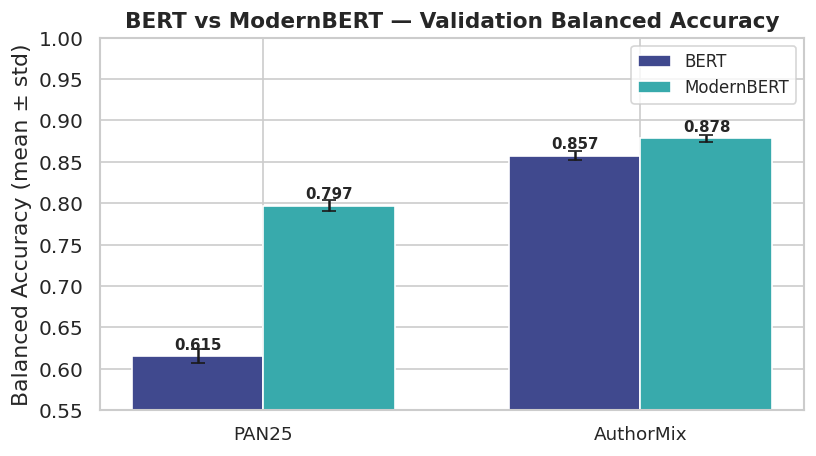

PAN25 multiclass: BERT 0.6152 → ModernBERT 0.7967  Δ = +18.1 pp
AuthorMix: BERT 0.8572 → ModernBERT 0.8784  Δ = +2.1 pp


In [2]:
# performance comparison
perf_df = pd.read_csv(f"{RESULTS}/modernbert_vs_bert_summary.csv")
display(perf_df)

fig, ax = plt.subplots(figsize=(7, 4))
datasets = perf_df["dataset"].unique()
x = np.arange(len(datasets))
width = 0.35
model_colors = {model: color for model, color in zip(["BERT", "ModernBERT"], mako_palette(2))}

for i, model in enumerate(["BERT", "ModernBERT"]):
    vals = [perf_df[(perf_df["dataset"] == d) & (perf_df["model"] == model)]["mean"].values[0]
            for d in datasets]
    errs = [perf_df[(perf_df["dataset"] == d) & (perf_df["model"] == model)]["std"].values[0]
            for d in datasets]
    bars = ax.bar(x + i * width, vals, width, label=model, color=model_colors[model],
                  yerr=errs, capsize=4, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{v:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x + width / 2)
ax.set_xticklabels([d.replace(" multiclass", "") for d in datasets], fontsize=11)
ax.set_ylabel("Balanced Accuracy (mean ± std)")
ax.set_ylim(0.55, 1.0)
ax.set_title("BERT vs ModernBERT — Validation Balanced Accuracy", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.axhline(1.0, color="0.4", lw=0.5, ls="--")
plt.tight_layout()

png_path = f"{RESULTS}/modernbert_vs_bert_balanced_accuracy.png"
pdf_path = f"{RESULTS}/modernbert_vs_bert_balanced_accuracy.pdf"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
print(f"Saved PNG: {png_path}")
print(f"Saved PDF: {pdf_path}")
save_plot(fig, "modernbert_vs_bert_balanced_accuracy")
plt.show()

for d in datasets:
    bert_m = perf_df[(perf_df["dataset"]==d) & (perf_df["model"]=="BERT")]["mean"].values[0]
    mb_m   = perf_df[(perf_df["dataset"]==d) & (perf_df["model"]=="ModernBERT")]["mean"].values[0]
    print(f"{d}: BERT {bert_m:.4f} → ModernBERT {mb_m:.4f}  Δ = +{(mb_m-bert_m)*100:.1f} pp")


In [3]:
# full-validation attribution CSVs and JSONs
pan_ratios = pd.read_csv(f"{RESULTS}/pan25_modernbert_full_validation_all_methods_ratios.csv")
am_ratios  = pd.read_csv(f"{RESULTS}/authormix_modernbert_full_validation_all_methods_ratios.csv")

print(f"PAN25   ratios : {pan_ratios.shape[0]:,} examples, {pan_ratios['class'].nunique()} classes")
print(f"AuthorMix ratios: {am_ratios.shape[0]:,} examples, {am_ratios['class'].nunique()} classes")

def load_json_or_gzip(path_without_suffix):
    """Load either .json or .json.gz attribution files."""
    json_path = path_without_suffix + ".json"
    gz_path = json_path + ".gz"

    if os.path.exists(json_path):
        with open(json_path, "r", encoding="utf-8") as f:
            return json.load(f)

    if os.path.exists(gz_path):
        with gzip.open(gz_path, "rt", encoding="utf-8") as f:
            return json.load(f)

    raise FileNotFoundError(f"Could not find {json_path} or {gz_path}")

pan_data = load_json_or_gzip(f"{RESULTS}/pan25_modernbert_full_validation_all_methods_attributions")
am_data  = load_json_or_gzip(f"{RESULTS}/authormix_modernbert_full_validation_all_methods_attributions")

print(f"PAN25   JSON  : {len(pan_data):,} examples")
print(f"AuthorMix JSON: {len(am_data):,} examples")

# Helper: stratified sample
def stratified_sample(data, n_per_class=20, seed=42):
    rng = np.random.default_rng(seed)
    by_class = defaultdict(list)
    for ex in data:
        by_class[ex["class_name"]].append(ex)
    sampled = []
    for cls in sorted(by_class.keys()):
        exs = by_class[cls]
        n   = min(n_per_class, len(exs))
        idxs = rng.choice(len(exs), size=n, replace=False)
        sampled.extend([exs[i] for i in idxs])
    return sampled

# Ratio checks and non-newline lexical ratios
# Newline is kept in the raw CSVs as an audit category.
# Thesis-facing lexical plots use content/punctuation/stopword ratios
# renormalised over non-newline tokens.

METHODS = [("ig", "IG"), ("gs", "SHAP"), ("ar", "AR")]
RAW_RATIO_TYPES = ["content_ratio", "punct_ratio", "stop_ratio", "newline_ratio"]
LEXICAL_RATIO_TYPES = [
    "content_nonnewline_ratio",
    "punct_nonnewline_ratio",
    "stop_nonnewline_ratio",
]

def check_ratio_columns(df, name):
    missing = []
    for prefix, _ in METHODS:
        for ratio in RAW_RATIO_TYPES:
            col = f"{prefix}_{ratio}"
            if col not in df.columns:
                missing.append(col)

    if missing:
        raise ValueError(f"{name} is missing columns: {missing}")

    print(f"{name}: raw ratio columns found.")

def check_ratio_sums(df, name):
    for prefix, _ in METHODS:
        cols = [f"{prefix}_{r}" for r in RAW_RATIO_TYPES]
        sums = df[cols].sum(axis=1)

        print(
            f"{name} {prefix} ratio-sum min: {round(sums.min(), 6)} "
            f"max: {round(sums.max(), 6)}"
        )

        assert np.allclose(sums, 1.0, atol=1e-6)

def add_nonnewline_ratios(df):
    """Add content/punct/stop ratios renormalised over non-newline tokens."""
    df = df.copy()

    for prefix, _ in METHODS:
        denom = (
            df[f"{prefix}_content_ratio"]
            + df[f"{prefix}_punct_ratio"]
            + df[f"{prefix}_stop_ratio"]
        )

        denom = denom.replace(0, np.nan)

        df[f"{prefix}_content_nonnewline_ratio"] = df[f"{prefix}_content_ratio"] / denom
        df[f"{prefix}_punct_nonnewline_ratio"] = df[f"{prefix}_punct_ratio"] / denom
        df[f"{prefix}_stop_nonnewline_ratio"] = df[f"{prefix}_stop_ratio"] / denom

    return df

def print_newline_audit(df, dataset_name):
    print(f"\nModernBERT {dataset_name}: raw newline ratio audit")
    for prefix, label in METHODS:
        col = f"{prefix}_newline_ratio"
        vals = df[col].dropna()
        print(
            f"  {label}: mean={vals.mean():.4f}, "
            f"median={vals.median():.4f}, max={vals.max():.4f}"
        )

check_ratio_columns(pan_ratios, "ModernBERT PAN25")
check_ratio_columns(am_ratios, "ModernBERT AuthorMix")
check_ratio_sums(pan_ratios, "ModernBERT PAN25")
check_ratio_sums(am_ratios, "ModernBERT AuthorMix")

pan_ratios = add_nonnewline_ratios(pan_ratios)
am_ratios = add_nonnewline_ratios(am_ratios)

print("Added non-newline-normalised lexical ratio columns.")
print_newline_audit(pan_ratios, "PAN25")
print_newline_audit(am_ratios, "AuthorMix")


PAN25   ratios : 3,556 examples, 23 classes
AuthorMix ratios: 3,642 examples, 14 classes
PAN25   JSON  : 3,556 examples
AuthorMix JSON: 3,642 examples
ModernBERT PAN25: raw ratio columns found.
ModernBERT AuthorMix: raw ratio columns found.
ModernBERT PAN25 ig ratio-sum min: 1.0 max: 1.0
ModernBERT PAN25 gs ratio-sum min: 1.0 max: 1.0
ModernBERT PAN25 ar ratio-sum min: 1.0 max: 1.0
ModernBERT AuthorMix ig ratio-sum min: 1.0 max: 1.0
ModernBERT AuthorMix gs ratio-sum min: 1.0 max: 1.0
ModernBERT AuthorMix ar ratio-sum min: 1.0 max: 1.0
Added non-newline-normalised lexical ratio columns.

ModernBERT PAN25: raw newline ratio audit
  IG: mean=0.3329, median=0.3333, max=1.0000
  SHAP: mean=0.3154, median=0.2667, max=0.9333
  AR: mean=0.2102, median=0.2000, max=0.8000

ModernBERT AuthorMix: raw newline ratio audit
  IG: mean=0.0011, median=0.0000, max=0.2000
  SHAP: mean=0.0010, median=0.0000, max=0.2000
  AR: mean=0.0012, median=0.0000, max=0.2000


## 1. Token-level heatmap visualisations

Coloured token heatmaps show which words the classifier "sees" most strongly.
Darker mako-blue = higher attribution. ModernBERT uses `Ġ`-prefixed tokens (GPT-2 style).

In [4]:
def build_attribution_scores(ex, method_key):
    """Align top-k attribution scores with the full token list."""
    tokens = ex["tokens"]
    scores = np.zeros(len(tokens))
    used = set()

    for tok_str, score in ex[method_key]:
        for j, t in enumerate(tokens):
            if j not in used and t == tok_str:
                scores[j] = abs(float(score))
                used.add(j)
                break
    return scores

# Alias used in the BERT notebook.
build_full_attribution_scores = build_attribution_scores


def render_heatmap(ax, tokens, scores, title="", max_tokens=80):
    """
    Render tokens as coloured boxes on a matplotlib axis.
    Uses a readable white-to-mako-blue palette.
    """
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.set_title(title, fontsize=10, fontweight="bold", loc="left")

    if len(tokens) > max_tokens:
        tokens = tokens[:max_tokens]
        scores = scores[:max_tokens]

    smax = scores.max() if scores.max() > 0 else 1.0
    norm_scores = scores / smax

    mako_blue = sns.color_palette("mako", 9)[5]
    cmap = sns.blend_palette(["#f7f7f7", mako_blue], as_cmap=True)

    x, y = 0.01, 0.85
    line_height = 0.13

    for tok, ns in zip(tokens, norm_scores):
        disp = display_tok(tok)
        if disp == "":
            continue

        txt_width = len(disp) * 0.009 + 0.015

        if x + txt_width > 0.99:
            x = 0.01
            y -= line_height
            if y < 0.02:
                break

        color = cmap(ns)

        ax.add_patch(
            plt.Rectangle(
                (x, y - 0.04),
                txt_width,
                0.09,
                facecolor=color,
                edgecolor="white",
                linewidth=0.5,
                alpha=1.0
            )
        )

        r, g, b = color[:3]
        luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
        text_color = "white" if luminance < 0.55 else "black"

        ax.text(
            x + txt_width / 2,
            y,
            disp,
            fontsize=6.8,
            ha="center",
            va="center",
            color=text_color,
            fontfamily="monospace"
        )

        x += txt_width + 0.004

# Alias used in the BERT notebook.
render_heatmap_text = render_heatmap


def safe_filename(text):
    """Make strings safe for file names."""
    text = str(text)
    text = re.sub(r"[^a-zA-Z0-9_-]+", "_", text)
    return text.strip("_").lower()


def plot_heatmaps(data, dataset_name, n=4, save_dir=None):
    """
    For each example, show 3 rows (IG / SHAP / AR) of token heatmaps.
    Optionally saves each figure as PNG and PDF.
    """
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    for ex in data[:n]:
        fig, axes = plt.subplots(3, 1, figsize=(16, 5))

        fig.suptitle(
            f"{dataset_name}  |  Example {ex['example_idx']}  |  True class: {ex['class_name']}",
            fontsize=12,
            fontweight="bold",
            y=1.02
        )

        tokens = ex["tokens"]

        for ax, (method_key, method_label) in zip(axes, [
            ("top_ig", "Integrated Gradients"),
            ("top_gs", "GradientShap"),
            ("top_ar", "Attention Rollout"),
        ]):
            scores = build_attribution_scores(ex, method_key)
            render_heatmap(ax, tokens, scores, title=method_label)

        plt.tight_layout()

        if save_dir is not None:
            dataset_safe = safe_filename(dataset_name)
            class_safe = safe_filename(ex["class_name"])
            example_idx = ex["example_idx"]
            filename_base = f"{dataset_safe}_modernbert_example_{example_idx}_{class_safe}_heatmap"

            png_path = os.path.join(save_dir, filename_base + ".png")
            pdf_path = os.path.join(save_dir, filename_base + ".pdf")

            fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
            fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")

            print(f"Saved PNG: {png_path}")
            print(f"Saved PDF: {pdf_path}")

        plt.show()

# Alias used in the BERT notebook.
plot_example_heatmaps = plot_heatmaps


PAN25: Human vs GPT-4o
Saved PNG: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/pan25_modernbert_example_0_human_heatmap.png
Saved PDF: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/pan25_modernbert_example_0_human_heatmap.pdf


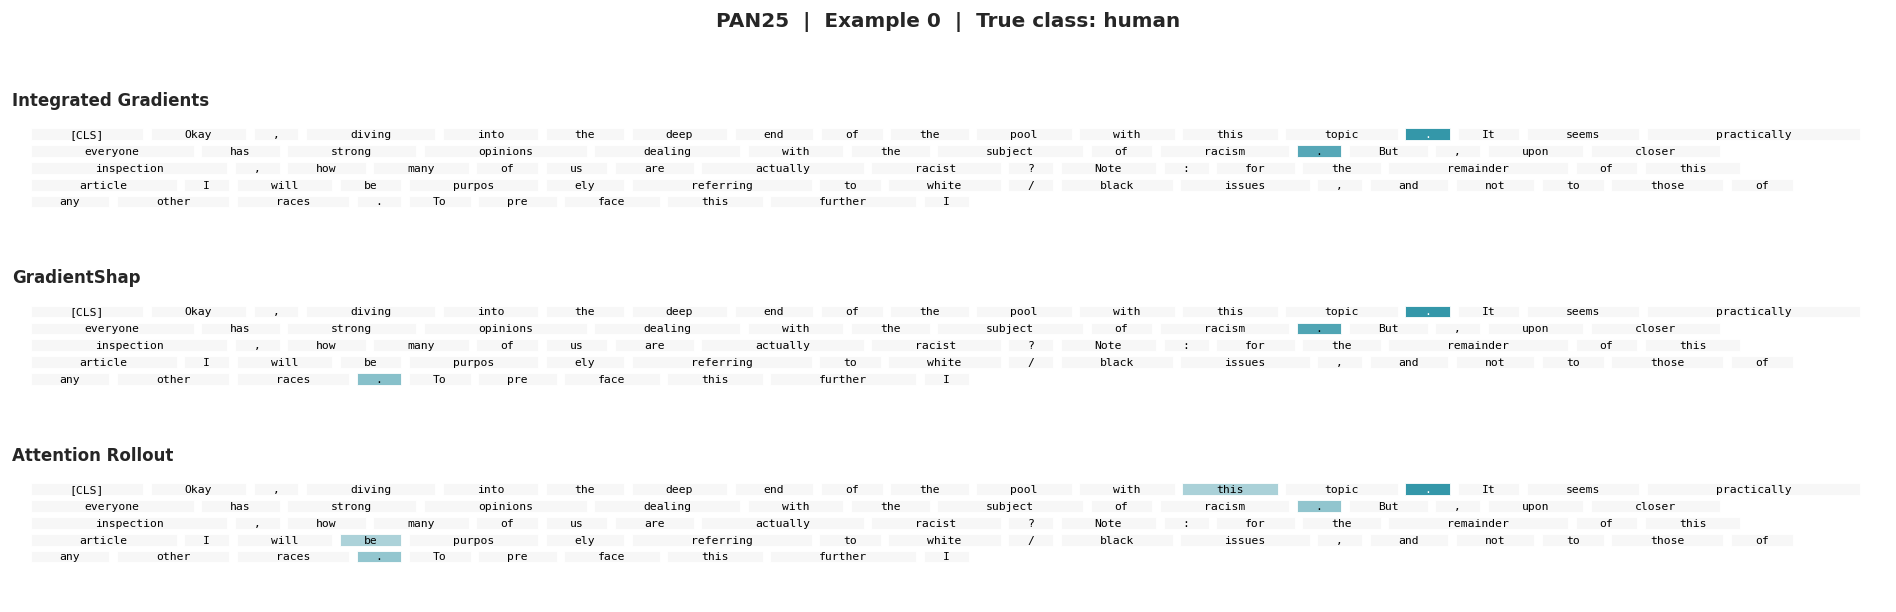

Saved PNG: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/pan25_modernbert_example_2_human_heatmap.png
Saved PDF: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/pan25_modernbert_example_2_human_heatmap.pdf


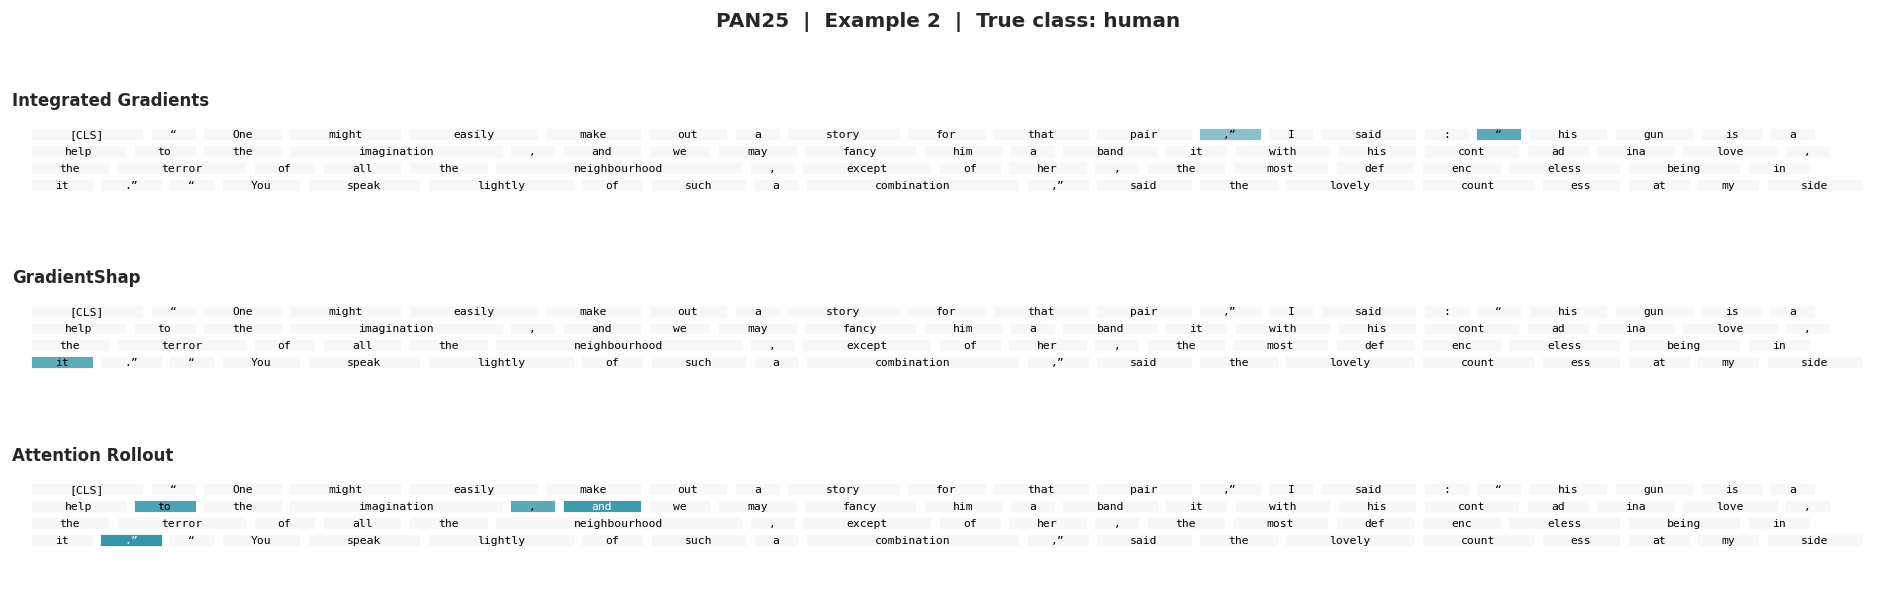

Saved PNG: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/pan25_modernbert_example_18_gpt-4o_heatmap.png
Saved PDF: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/pan25_modernbert_example_18_gpt-4o_heatmap.pdf


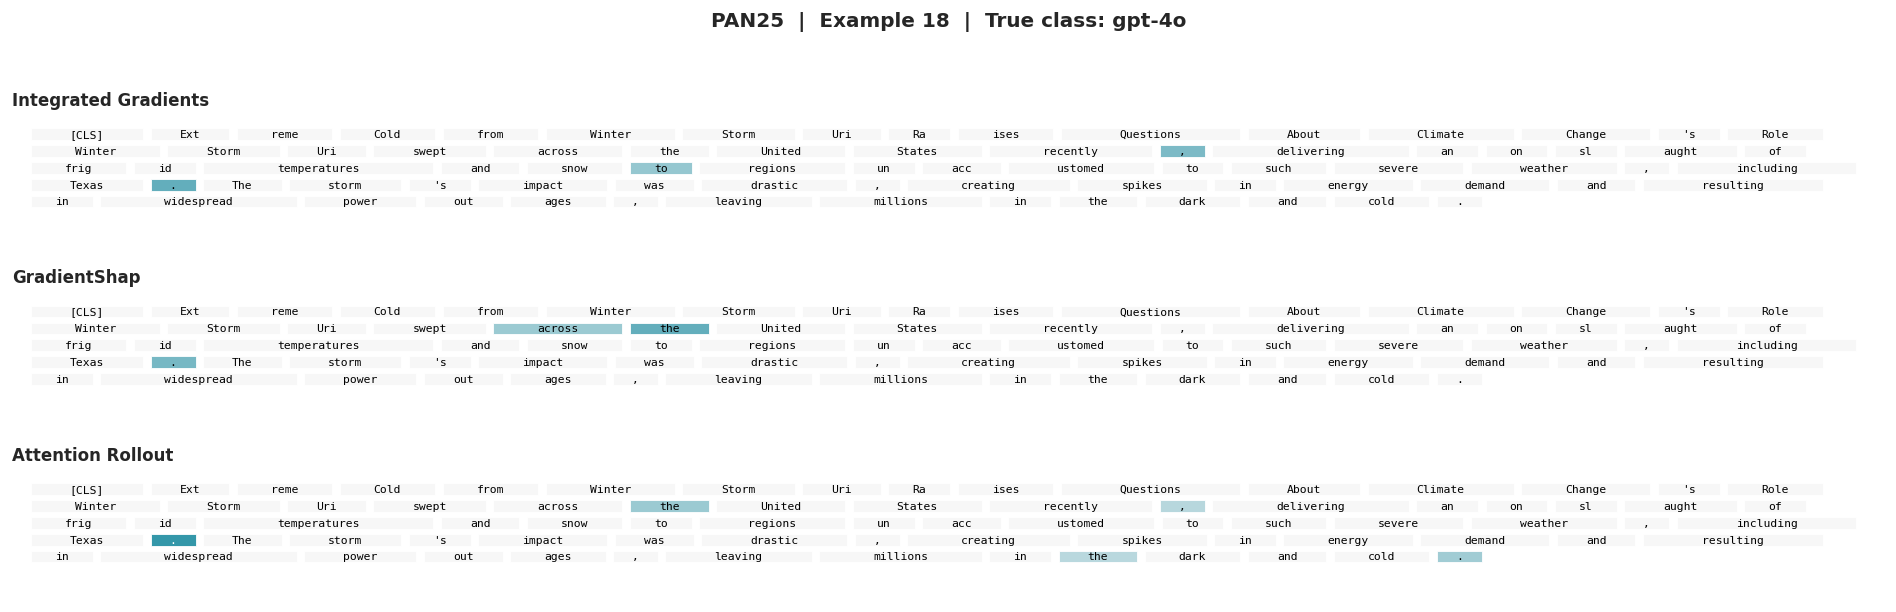

Saved PNG: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/pan25_modernbert_example_32_gpt-4o_heatmap.png
Saved PDF: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/pan25_modernbert_example_32_gpt-4o_heatmap.pdf


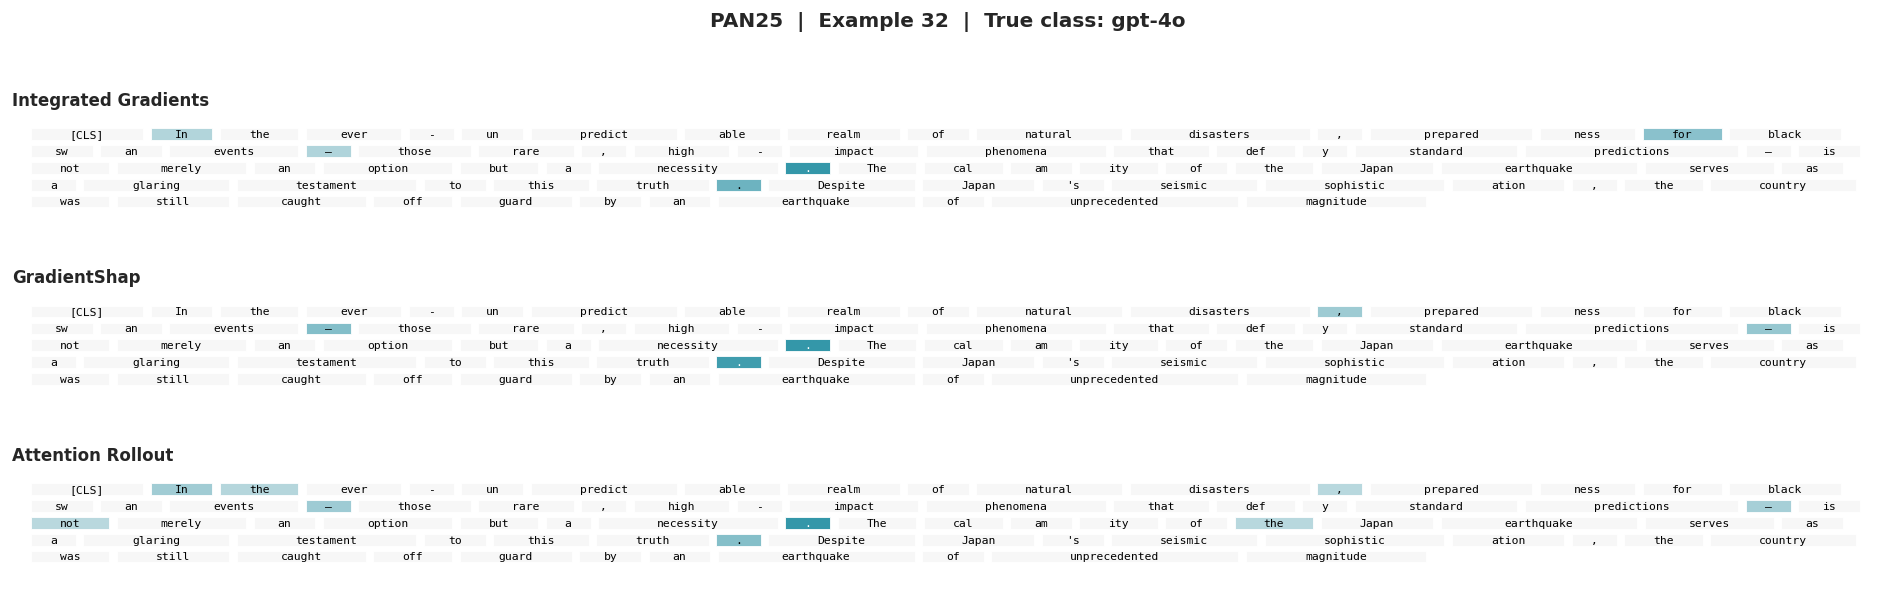

AuthorMix: qq vs blog30102
Saved PNG: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/authormix_modernbert_example_3629_qq_heatmap.png
Saved PDF: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/authormix_modernbert_example_3629_qq_heatmap.pdf


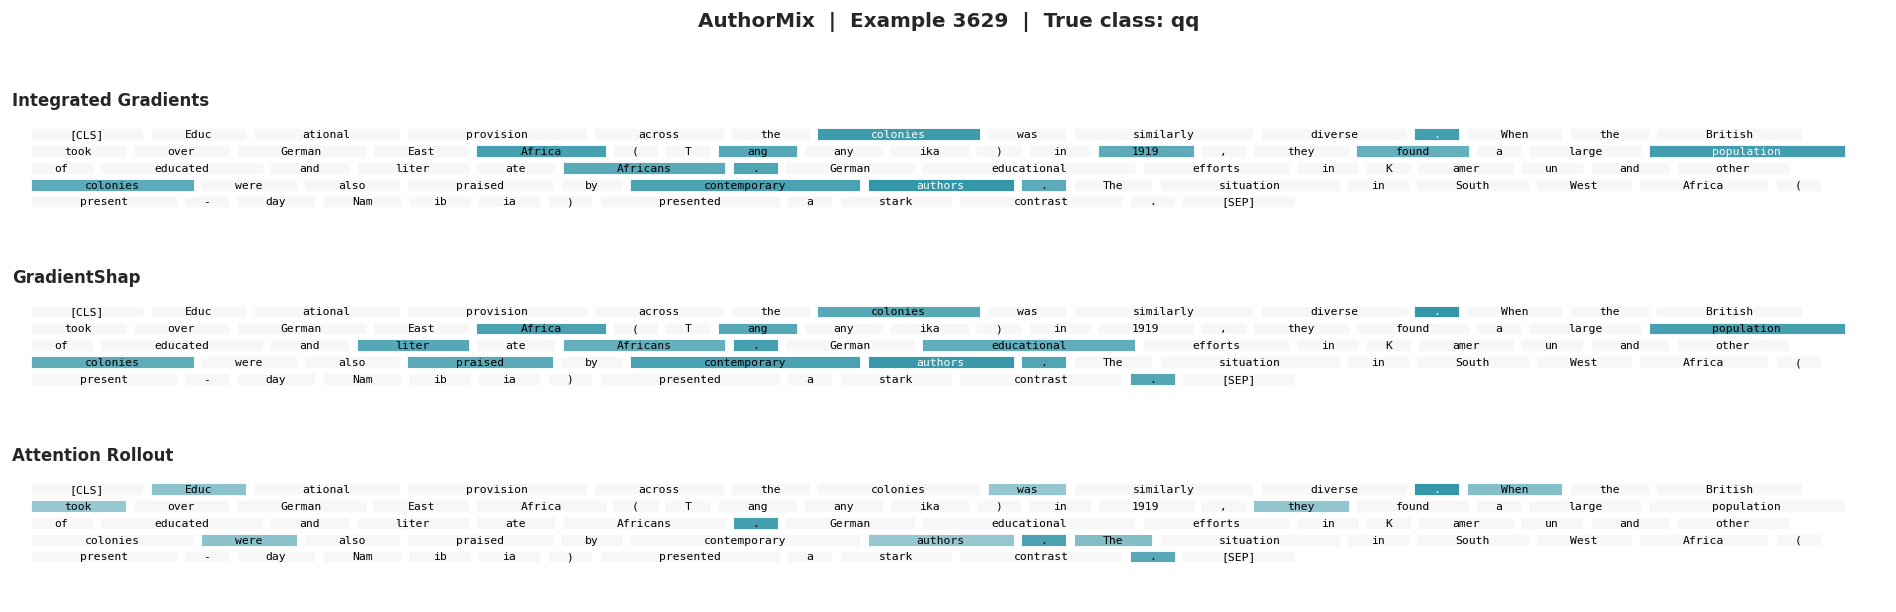

Saved PNG: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/authormix_modernbert_example_3630_qq_heatmap.png
Saved PDF: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/authormix_modernbert_example_3630_qq_heatmap.pdf


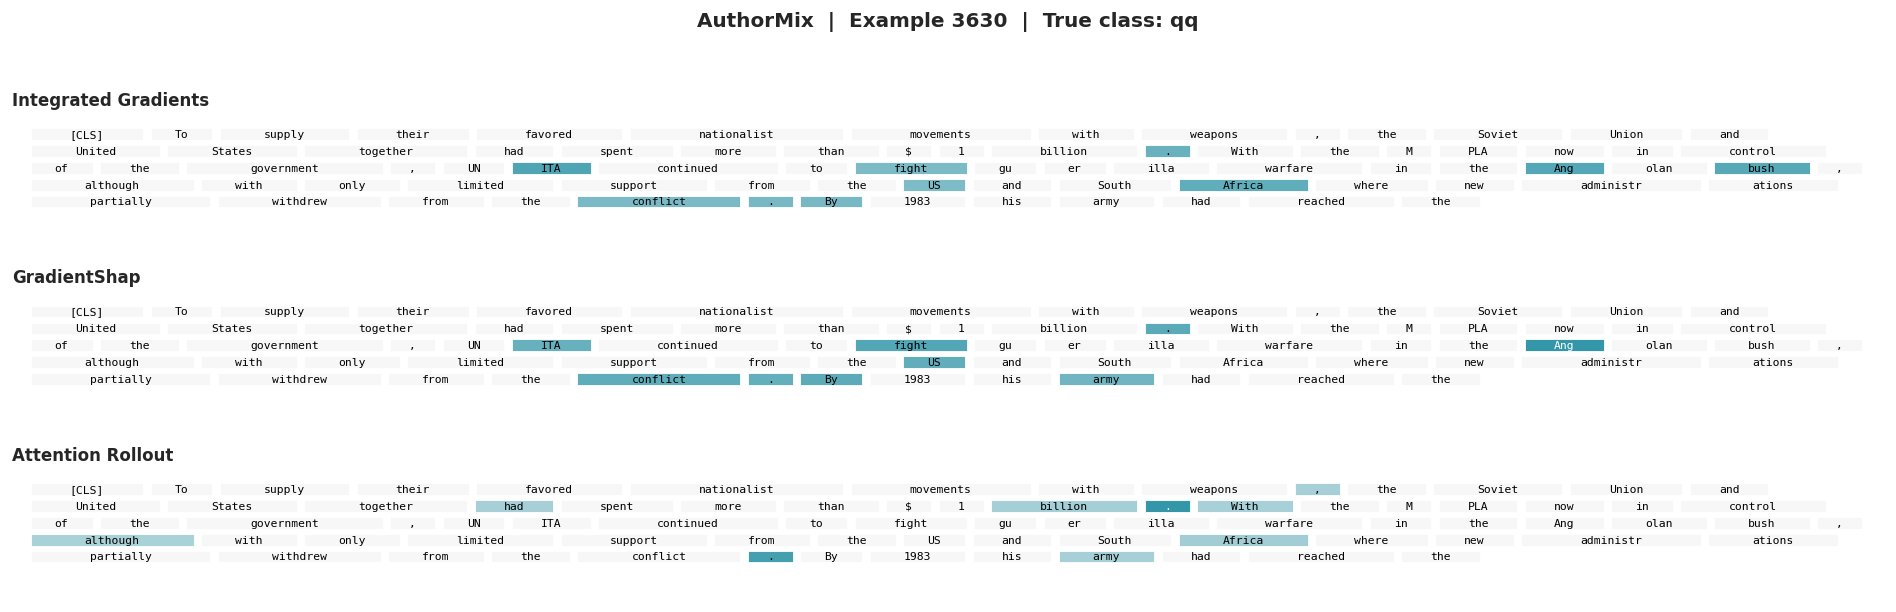

Saved PNG: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/authormix_modernbert_example_3347_blog30102_heatmap.png
Saved PDF: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/authormix_modernbert_example_3347_blog30102_heatmap.pdf


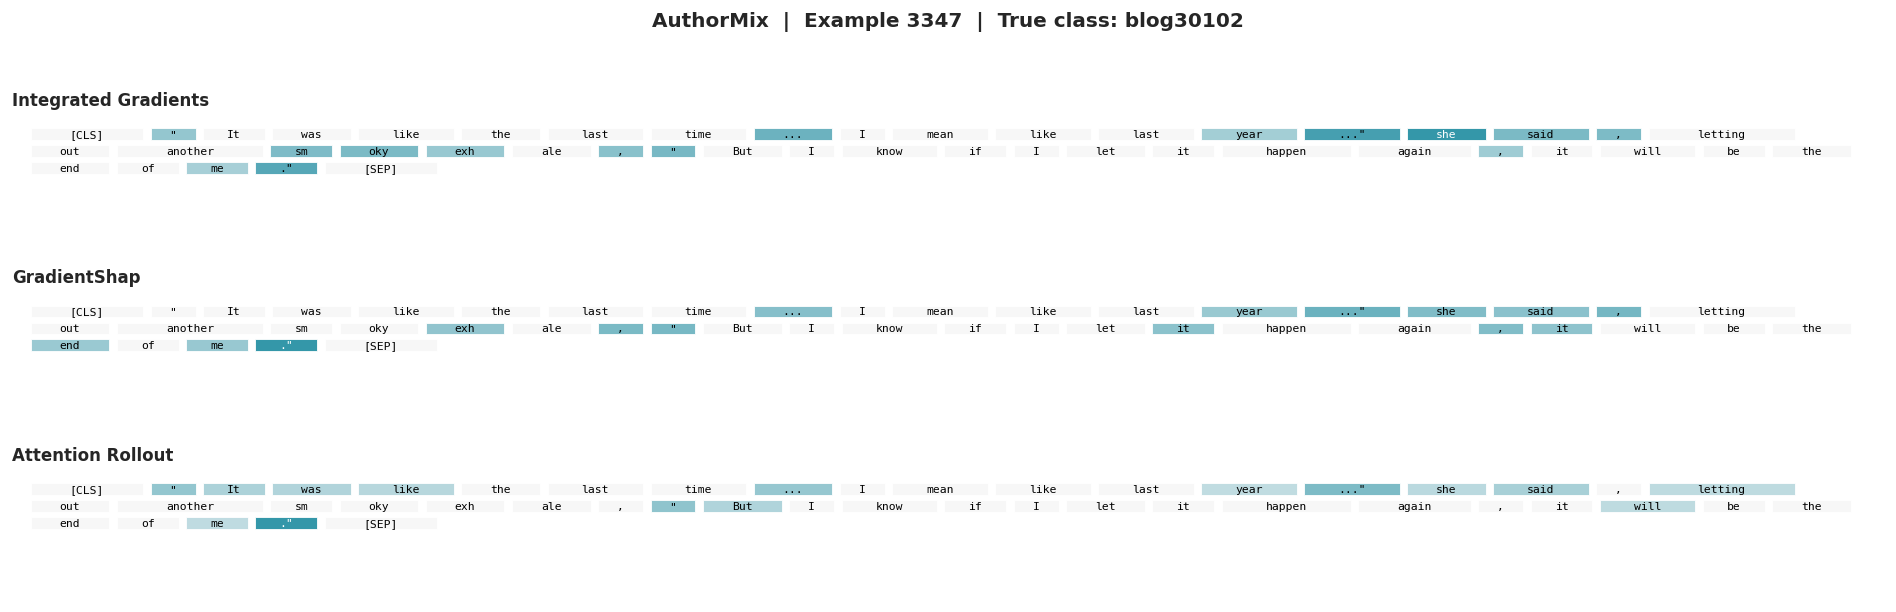

Saved PNG: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/authormix_modernbert_example_3348_blog30102_heatmap.png
Saved PDF: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/authormix_modernbert_example_3348_blog30102_heatmap.pdf


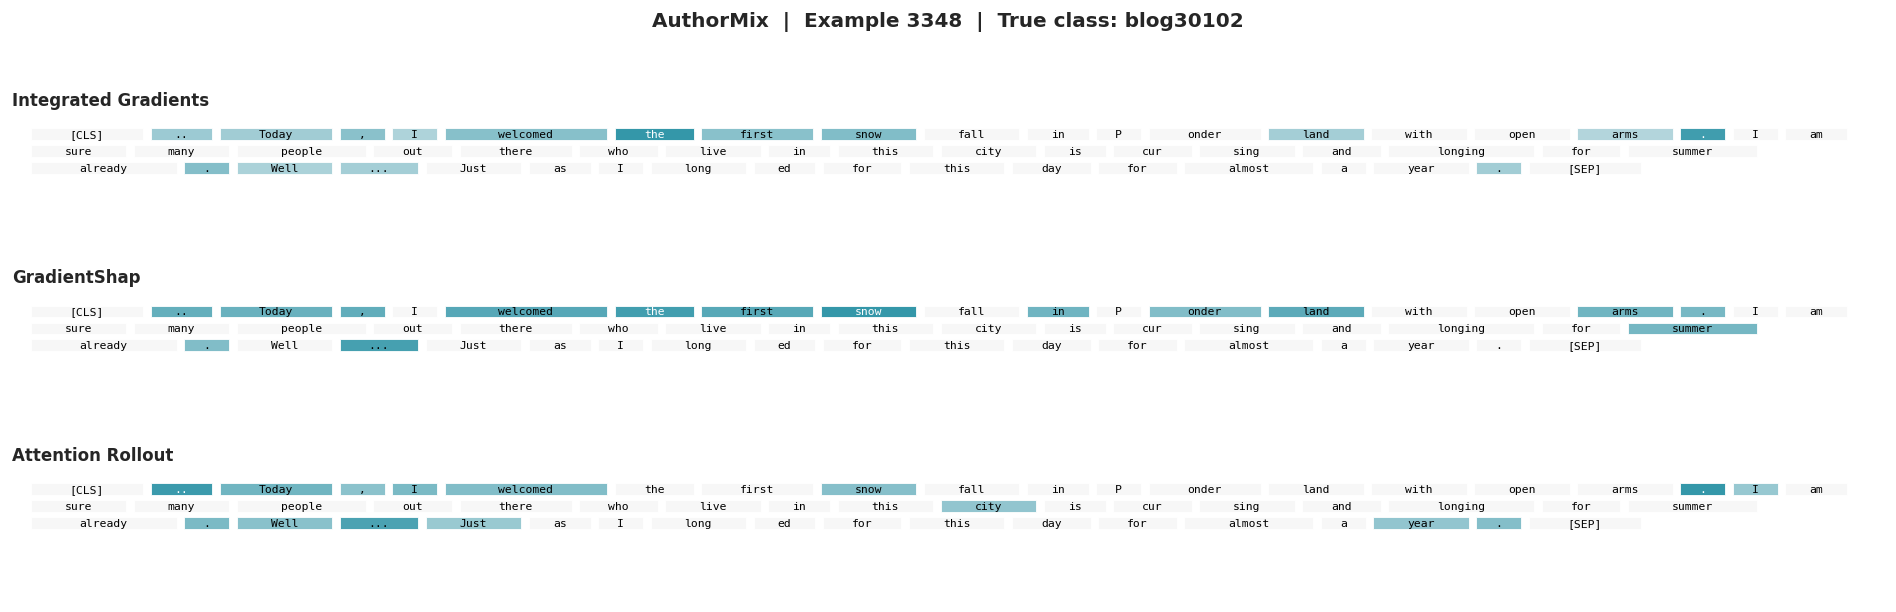

In [5]:
def pick_class(data, class_name, n=2):
    return [ex for ex in data if ex["class_name"] == class_name][:n]

HEATMAP_DIR = f"{RUNS_ROOT}/plots/example_heatmaps"

# PAN25: human vs gpt-4o
pan_sample_hm = pick_class(pan_data, "human", 2) + pick_class(pan_data, "gpt-4o", 2)
print("PAN25: Human vs GPT-4o")
plot_heatmaps(pan_sample_hm, "PAN25", save_dir=HEATMAP_DIR)

# AuthorMix: best vs worst class by IG content ratio, matching the BERT notebook logic
am_classes = am_ratios.groupby("class")["ig_content_nonnewline_ratio"].mean().sort_values()
am_worst = am_classes.index[0]
am_best  = am_classes.index[-1]
am_sample_hm = pick_class(am_data, am_best, 2) + pick_class(am_data, am_worst, 2)
print(f"AuthorMix: {am_best} vs {am_worst}")
plot_heatmaps(am_sample_hm, "AuthorMix", save_dir=HEATMAP_DIR)


## 2. Part-of-speech analysis

Does ModernBERT focus on **content words** (nouns, verbs) or **function words** (determiners, prepositions)?

The top-15 attributed tokens for each example are POS-tagged.

In [6]:
POS_CATEGORIES = {
    "Noun":        {"NN", "NNS", "NNP", "NNPS"},
    "Verb":        {"VB", "VBD", "VBG", "VBN", "VBP", "VBZ"},
    "Adjective":   {"JJ", "JJR", "JJS"},
    "Adverb":      {"RB", "RBR", "RBS"},
    "Determiner":  {"DT", "PDT", "WDT"},
    "Preposition": {"IN"},
    "Conjunction": {"CC"},
    "Pronoun":     {"PRP", "PRP$", "WP", "WP$"},
    "Punctuation": set(),
}

def classify_pos(token_str, pos_tag_str):
    if re.fullmatch(r"\W+", token_str):
        return "Punctuation"
    for cat, tags in POS_CATEGORIES.items():
        if pos_tag_str in tags:
            return cat
    return "Other"

def pos_profile(data, method_key="top_ig"):
    rows = []
    for ex in data:
        cls  = ex["class_name"]
        toks = [t[0] for t in ex[method_key]]
        clean = [clean_tok(t) for t in toks if not is_noise(t) and clean_tok(t)]
        if not clean:
            continue
        tagged = pos_tag(clean)
        cats = [classify_pos(tok, tag) for tok, tag in tagged]
        total = len(cats) or 1
        for cat, cnt in Counter(cats).items():
            rows.append({
                "class": cls,
                "category": cat,
                "proportion": cnt / total,
                "example_idx": ex["example_idx"]
            })
    return pd.DataFrame(rows)

def plot_pos_comparison(data, dataset_name, figsize=None, save_dir=None):
    import textwrap

    methods = [
        ("top_ig", "Integrated Gradients"),
        ("top_gs", "GradientShap"),
        ("top_ar", "Attention Rollout"),
    ]

    class_order = sorted({ex["class_name"] for ex in data})
    n_classes = len(class_order)

    if figsize is None:
        figsize = (max(16, 0.75 * n_classes), 10)

    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True, sharey=True, dpi=150)

    legend_handles = None
    legend_labels = None

    for ax, (method_key, method_label) in zip(axes, methods):
        df = pos_profile(data, method_key)
        if df.empty:
            continue

        pivot = (
            df.groupby(["class", "category"])["proportion"]
              .mean()
              .unstack(fill_value=0)
        )
        pivot = pivot.reindex(class_order)
        pos_colors = mako_palette(len(pivot.columns))

        pivot.plot(
            kind="bar",
            ax=ax,
            width=0.78,
            color=pos_colors,
            edgecolor="white",
            linewidth=0.4
        )

        ax.set_title(method_label, fontsize=12, fontweight="bold", pad=8)
        ax.set_ylabel("Mean Proportion", fontsize=10)
        ax.set_xlabel("")
        ax.grid(axis="y", alpha=0.25)
        ax.tick_params(axis="y", labelsize=9)

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

        if ax.get_legend() is not None:
            ax.get_legend().remove()

    wrapped_labels = ["\n".join(textwrap.wrap(str(label), width=18)) for label in class_order]
    axes[-1].set_xticks(range(len(class_order)))
    axes[-1].set_xticklabels(wrapped_labels, rotation=35, ha="right", fontsize=8)

    fig.suptitle(
        f"{dataset_name} — POS Distribution of Top-Attributed Tokens",
        fontsize=15,
        fontweight="bold",
        y=0.995
    )

    if legend_handles is not None:
        fig.legend(
            legend_handles,
            legend_labels,
            title="POS category",
            loc="upper center",
            bbox_to_anchor=(0.5, 0.955),
            ncol=5,
            fontsize=8,
            title_fontsize=9,
            frameon=False
        )

    plt.tight_layout(rect=[0, 0, 1, 0.91])

    save_plot(fig, f"{dataset_name}_modernbert_pos_distribution", save_dir=save_dir)
    plt.show()


POS sample: 460 PAN25, 264 AuthorMix
Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/pan25_modernbert_pos_distribution.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/pan25_modernbert_pos_distribution.pdf


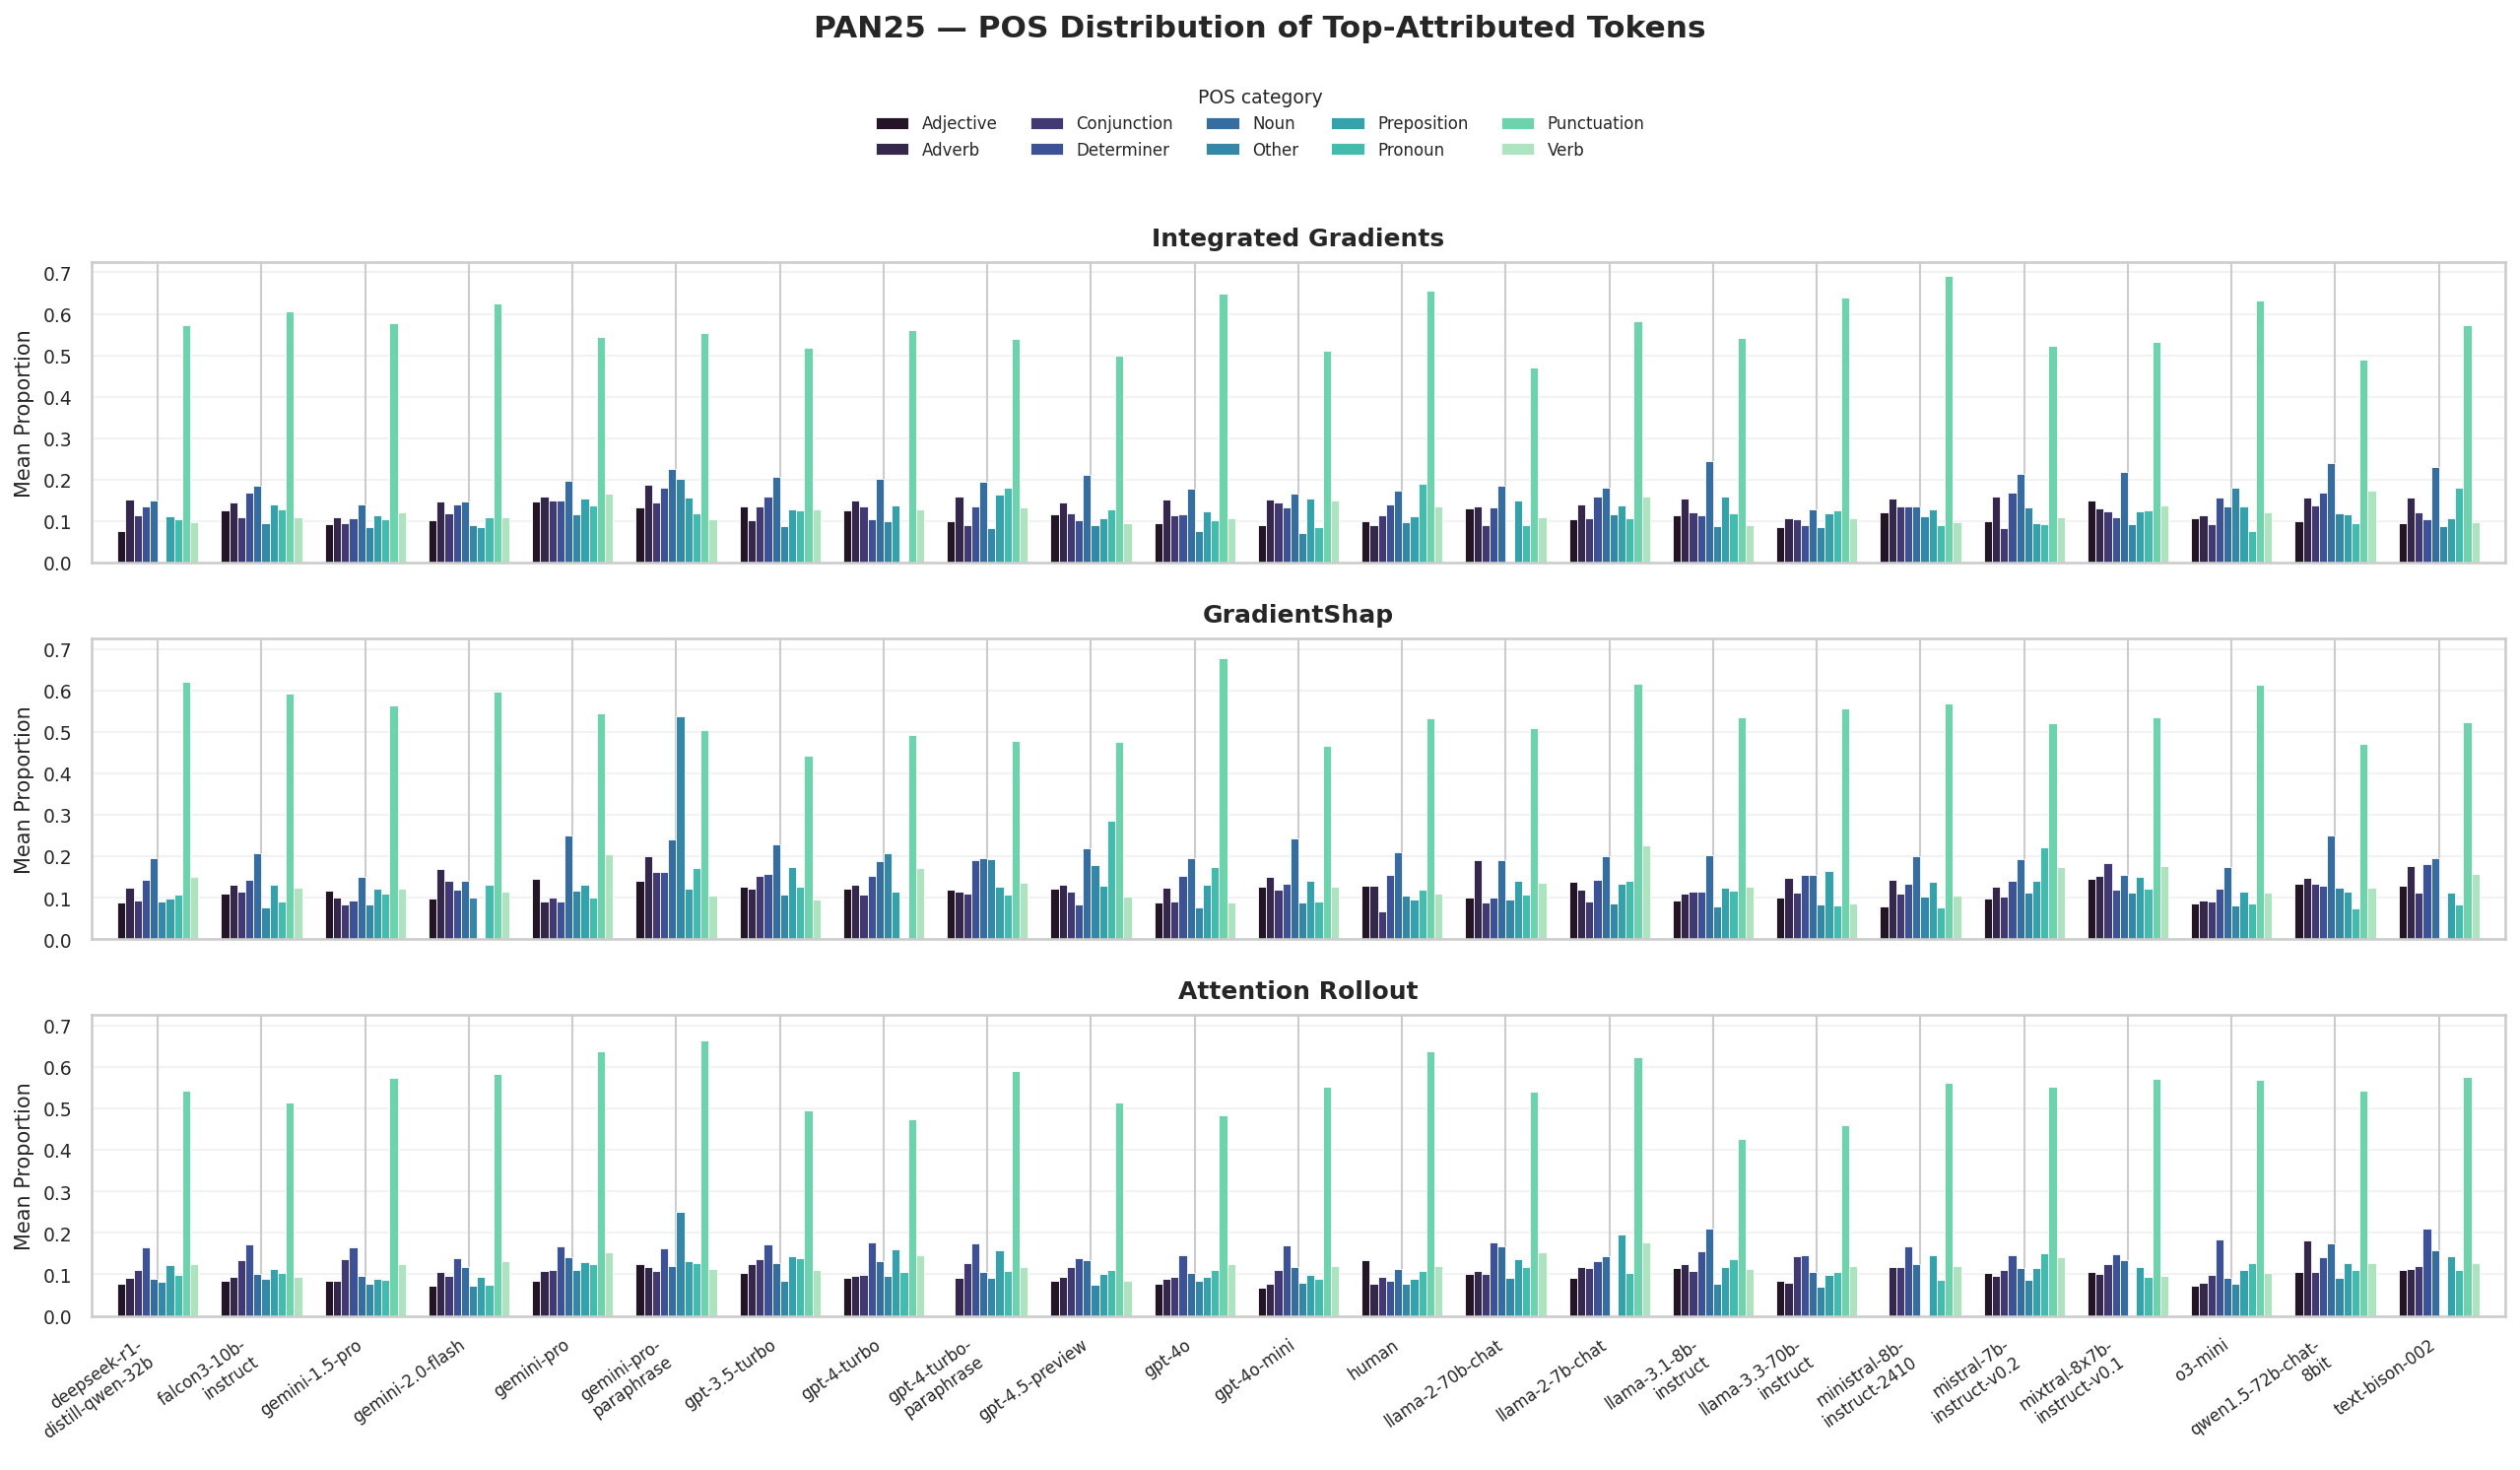

Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/authormix_modernbert_pos_distribution.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/authormix_modernbert_pos_distribution.pdf


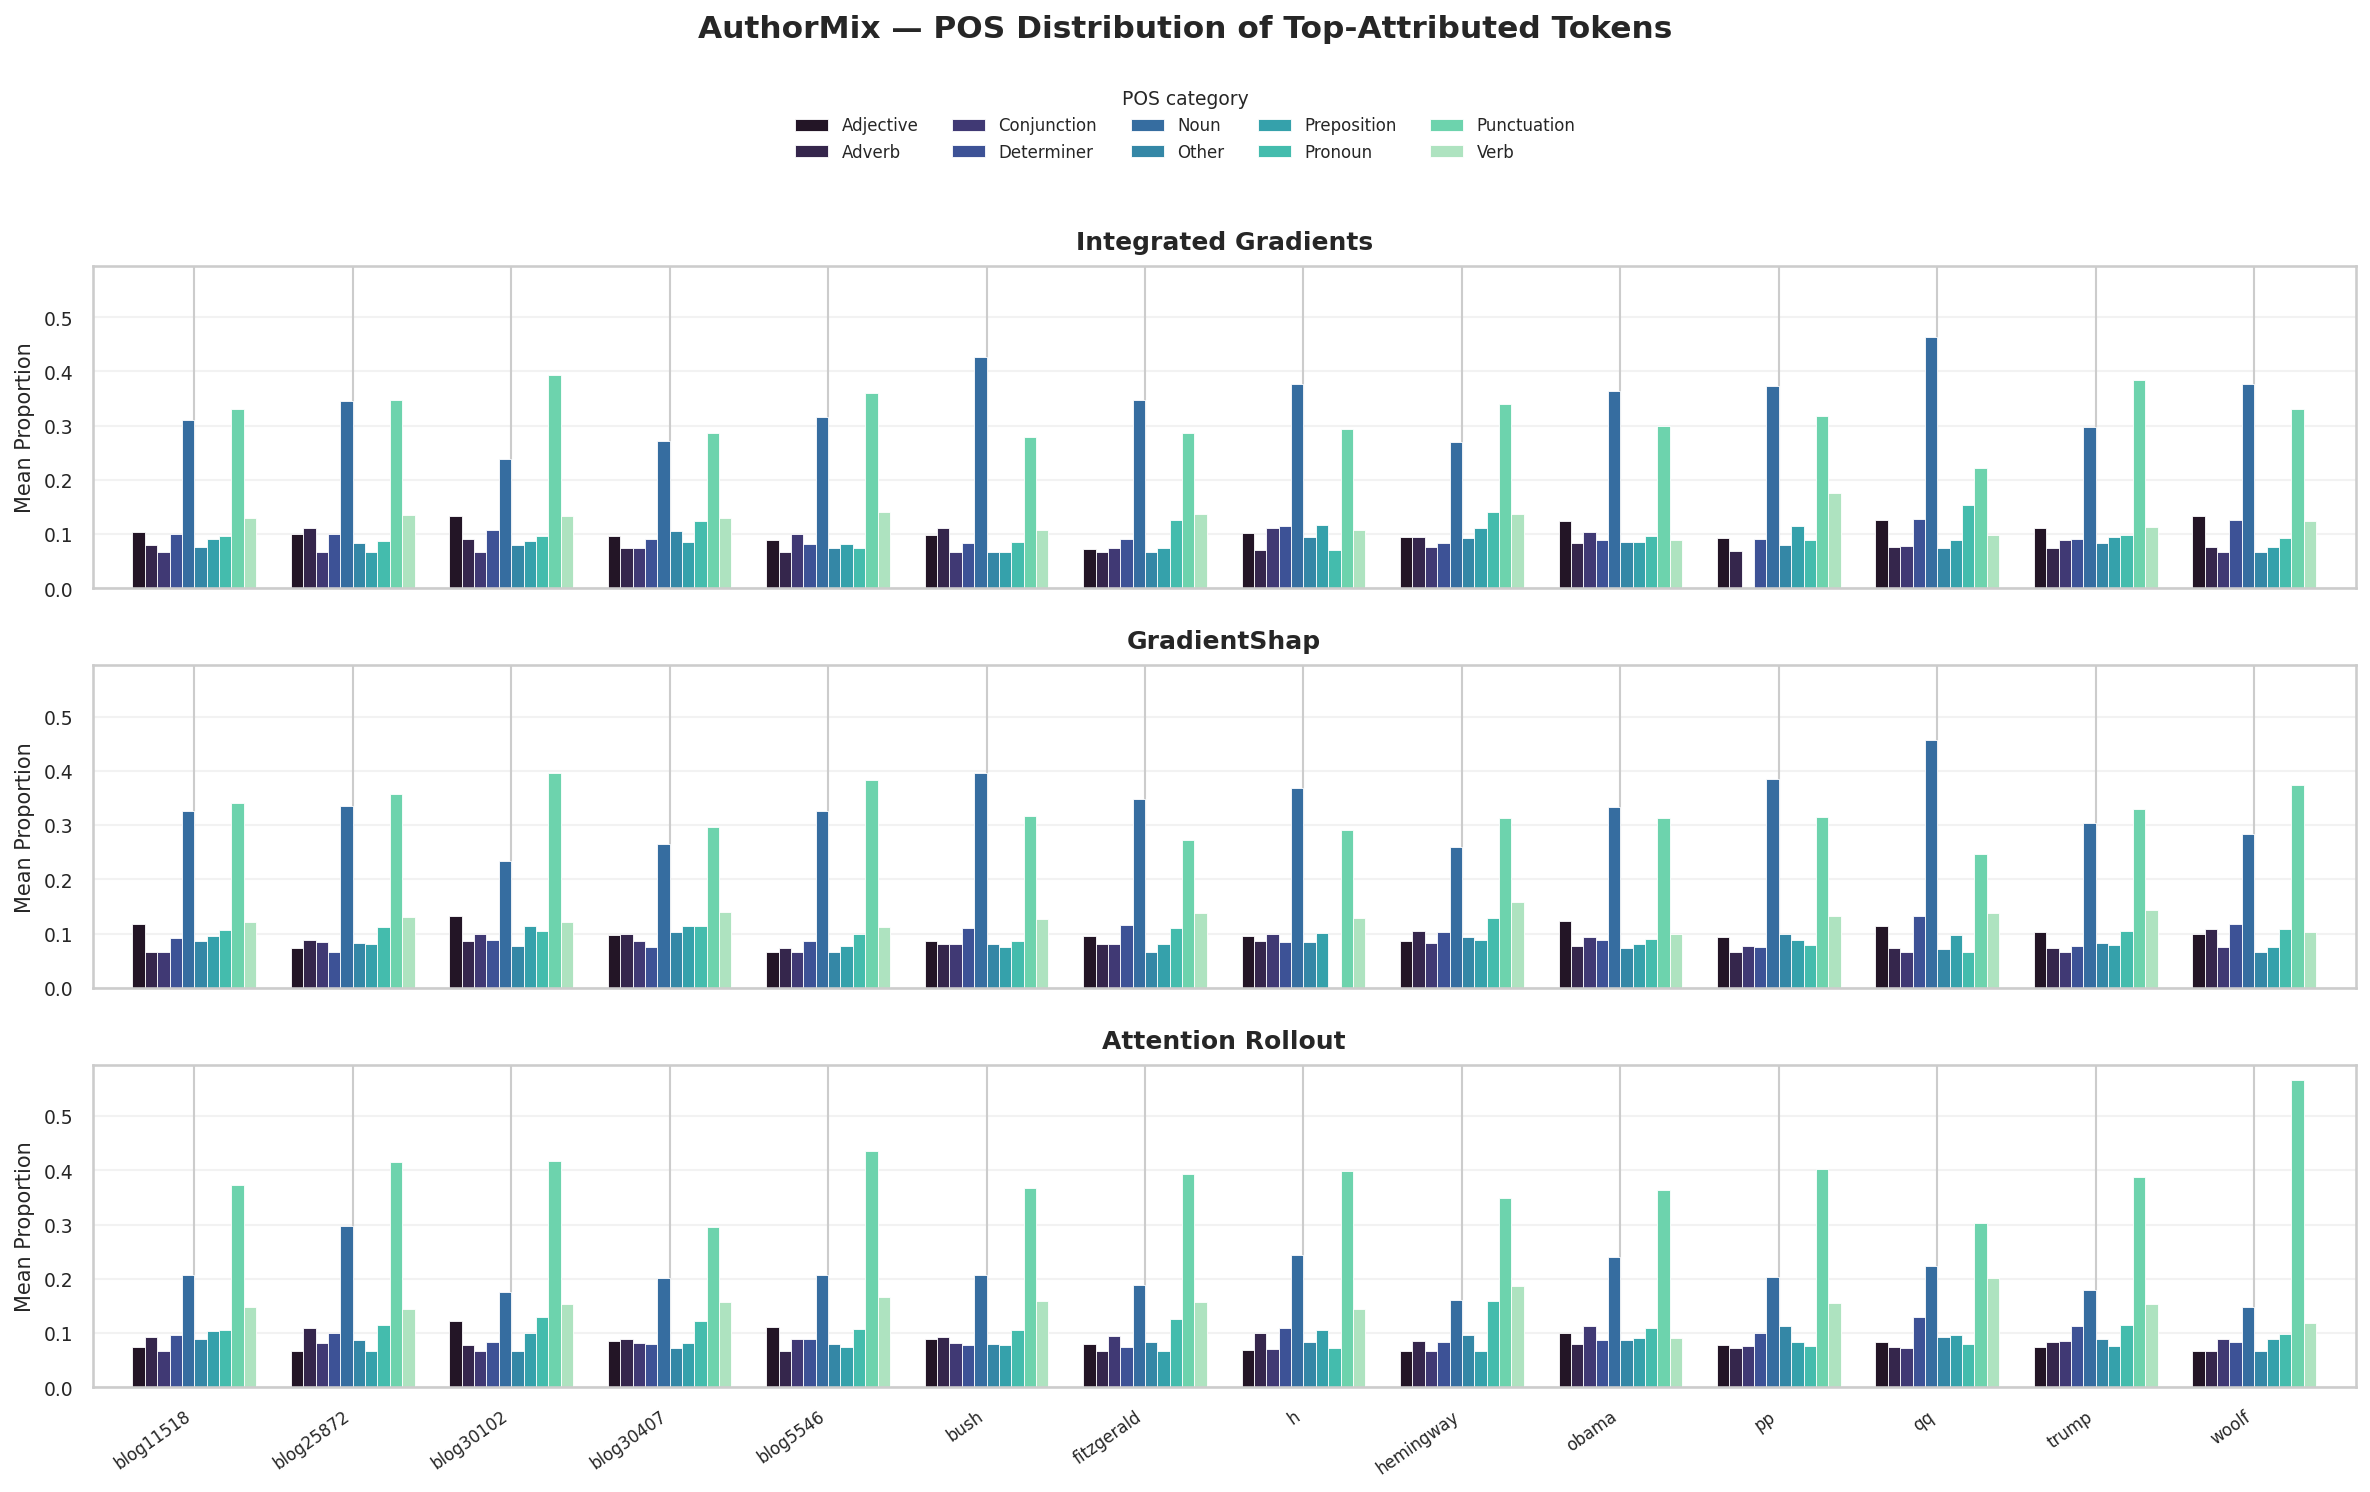


PAN25 — POS proportions (IG, mean over 20 examples/class):


category,Adjective,Adverb,Conjunction,Determiner,Noun,Other,Preposition,Pronoun,Punctuation,Verb
class,,,,,,,,,,
deepseek-r1-distill-qwen-32b,0.077,0.152,0.115,0.135,0.149,0.000,0.112,0.104,0.574,0.098
falcon3-10b-instruct,0.127,0.145,0.111,0.170,0.186,0.095,0.141,0.129,0.607,0.111
gemini-1.5-pro,0.093,0.110,0.094,0.107,0.141,0.086,0.114,0.105,0.577,0.121
gemini-2.0-flash,0.102,0.147,0.118,0.141,0.148,0.091,0.086,0.108,0.624,0.111
gemini-pro,0.148,0.160,0.151,0.151,0.197,0.117,0.154,0.139,0.545,0.167
gemini-pro-paraphrase,0.134,0.188,0.145,0.180,0.225,0.201,0.157,0.119,0.554,0.105
gpt-3.5-turbo,0.135,0.103,0.136,0.160,0.207,0.087,0.127,0.127,0.519,0.130
gpt-4-turbo,0.126,0.150,0.135,0.106,0.201,0.101,0.138,0.000,0.560,0.129
gpt-4-turbo-paraphrase,0.099,0.160,0.091,0.136,0.195,0.084,0.163,0.182,0.539,0.134



AuthorMix — POS proportions (IG, mean over 20 examples/class):


category,Adjective,Adverb,Conjunction,Determiner,Noun,Other,Preposition,Pronoun,Punctuation,Verb
class,,,,,,,,,,
blog11518,0.103,0.080,0.067,0.100,0.310,0.076,0.092,0.096,0.330,0.130
blog25872,0.101,0.111,0.067,0.100,0.345,0.085,0.067,0.088,0.348,0.135
blog30102,0.133,0.092,0.067,0.108,0.239,0.080,0.087,0.096,0.393,0.133
blog30407,0.097,0.075,0.075,0.091,0.272,0.107,0.086,0.124,0.286,0.129
blog5546,0.089,0.067,0.100,0.081,0.317,0.075,0.081,0.075,0.360,0.142
bush,0.098,0.111,0.067,0.083,0.427,0.067,0.067,0.086,0.280,0.108
fitzgerald,0.073,0.067,0.075,0.092,0.347,0.067,0.074,0.126,0.287,0.137
h,0.102,0.071,0.111,0.114,0.376,0.095,0.116,0.071,0.294,0.107
hemingway,0.094,0.095,0.076,0.083,0.270,0.093,0.111,0.141,0.340,0.137


In [7]:
POS_N = 20   # examples per class for POS (slow — POS tagging)
pan_pos = stratified_sample(pan_data, n_per_class=POS_N)
am_pos  = stratified_sample(am_data,  n_per_class=POS_N)
print(f"POS sample: {len(pan_pos)} PAN25, {len(am_pos)} AuthorMix")

plot_pos_comparison(pan_pos, "PAN25")
plot_pos_comparison(am_pos,  "AuthorMix")

# Summary table
for name, data in [("PAN25", pan_pos), ("AuthorMix", am_pos)]:
    df = pos_profile(data, "top_ig")
    if df.empty:
        continue
    tbl = (df.groupby(["class", "category"])["proportion"]
           .mean()
           .unstack(fill_value=0)
           .round(3))
    print(f"\n{name} — POS proportions (IG, mean over {POS_N} examples/class):")
    display(tbl)

## 3. Lexical sophistication and word rarity

Are the classifier's important tokens common everyday words or rare / sophisticated ones?
Metrics: mean word length - subword ratio - stopword ratio - type-token ratio (TTR).

ModernBERT note: subword continuations have no `Ġ` prefix (vs BERT's `##` suffix).

In [8]:
def lexical_metrics(data, method_key="top_ig"):
    rows = []
    for ex in data:
        cls  = ex["class_name"]
        toks = [t[0] for t in ex[method_key]]
        content = [t for t in toks if not is_noise(t)
                   and not re.fullmatch(r"\W+", clean_tok(t))
                   and clean_tok(t)]
        if not content:
            continue
        clean_words = [clean_tok(t) for t in content]
        lengths     = [len(w) for w in clean_words]
        n_sub       = sum(1 for t in content if is_subword(t))
        ttr         = len(set(w.lower() for w in clean_words)) / len(clean_words)
        stop_r      = sum(1 for w in clean_words if w.lower() in STOP_WORDS) / len(clean_words)
        rows.append({
            "class": cls,
            "mean_word_length":  np.mean(lengths),
            "max_word_length":   np.max(lengths),
            "subword_ratio":     n_sub / len(content),
            "type_token_ratio":  ttr,
            "stopword_ratio":    stop_r,
            "example_idx": ex["example_idx"],
        })
    return pd.DataFrame(rows)

def plot_lexical(data, dataset_name, save_dir=None):
    metrics = ["mean_word_length", "subword_ratio", "stopword_ratio", "type_token_ratio"]
    labels  = ["Mean Word Length", "Subword Ratio", "Stopword Ratio", "Type-Token Ratio"]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=150)
    axes = axes.ravel()

    legend_handles = None
    legend_labels = None

    for ax, metric, label in zip(axes, metrics, labels):
        rows = []
        for mk, ml in [("top_ig","IG"),("top_gs","SHAP"),("top_ar","AR")]:
            df = lexical_metrics(data, mk)
            if df.empty:
                continue
            df["method"] = ml
            rows.append(df)
        if not rows:
            ax.set_visible(False)
            continue
        combined = pd.concat(rows, ignore_index=True)
        sns.barplot(data=combined, x="method", y=metric, hue="class",
                    ax=ax, palette="mako", edgecolor="white")
        ax.set_title(label, fontsize=11, fontweight="bold")
        ax.set_xlabel("")
        ax.grid(axis="y", alpha=0.25)
        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    fig.suptitle(f"{dataset_name} — Lexical Sophistication of Attributed Tokens",
                 fontsize=13, fontweight="bold")
    if legend_handles is not None:
        fig.legend(legend_handles, legend_labels, title="Class", loc="lower center",
                   bbox_to_anchor=(0.5, 0.01), ncol=4, fontsize=7,
                   title_fontsize=8, frameon=False)
    plt.tight_layout(rect=[0, 0.14, 1, 0.94])
    save_plot(fig, f"{dataset_name}_modernbert_lexical_sophistication", save_dir=save_dir)
    plt.show()


Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/pan25_modernbert_lexical_sophistication.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/pan25_modernbert_lexical_sophistication.pdf


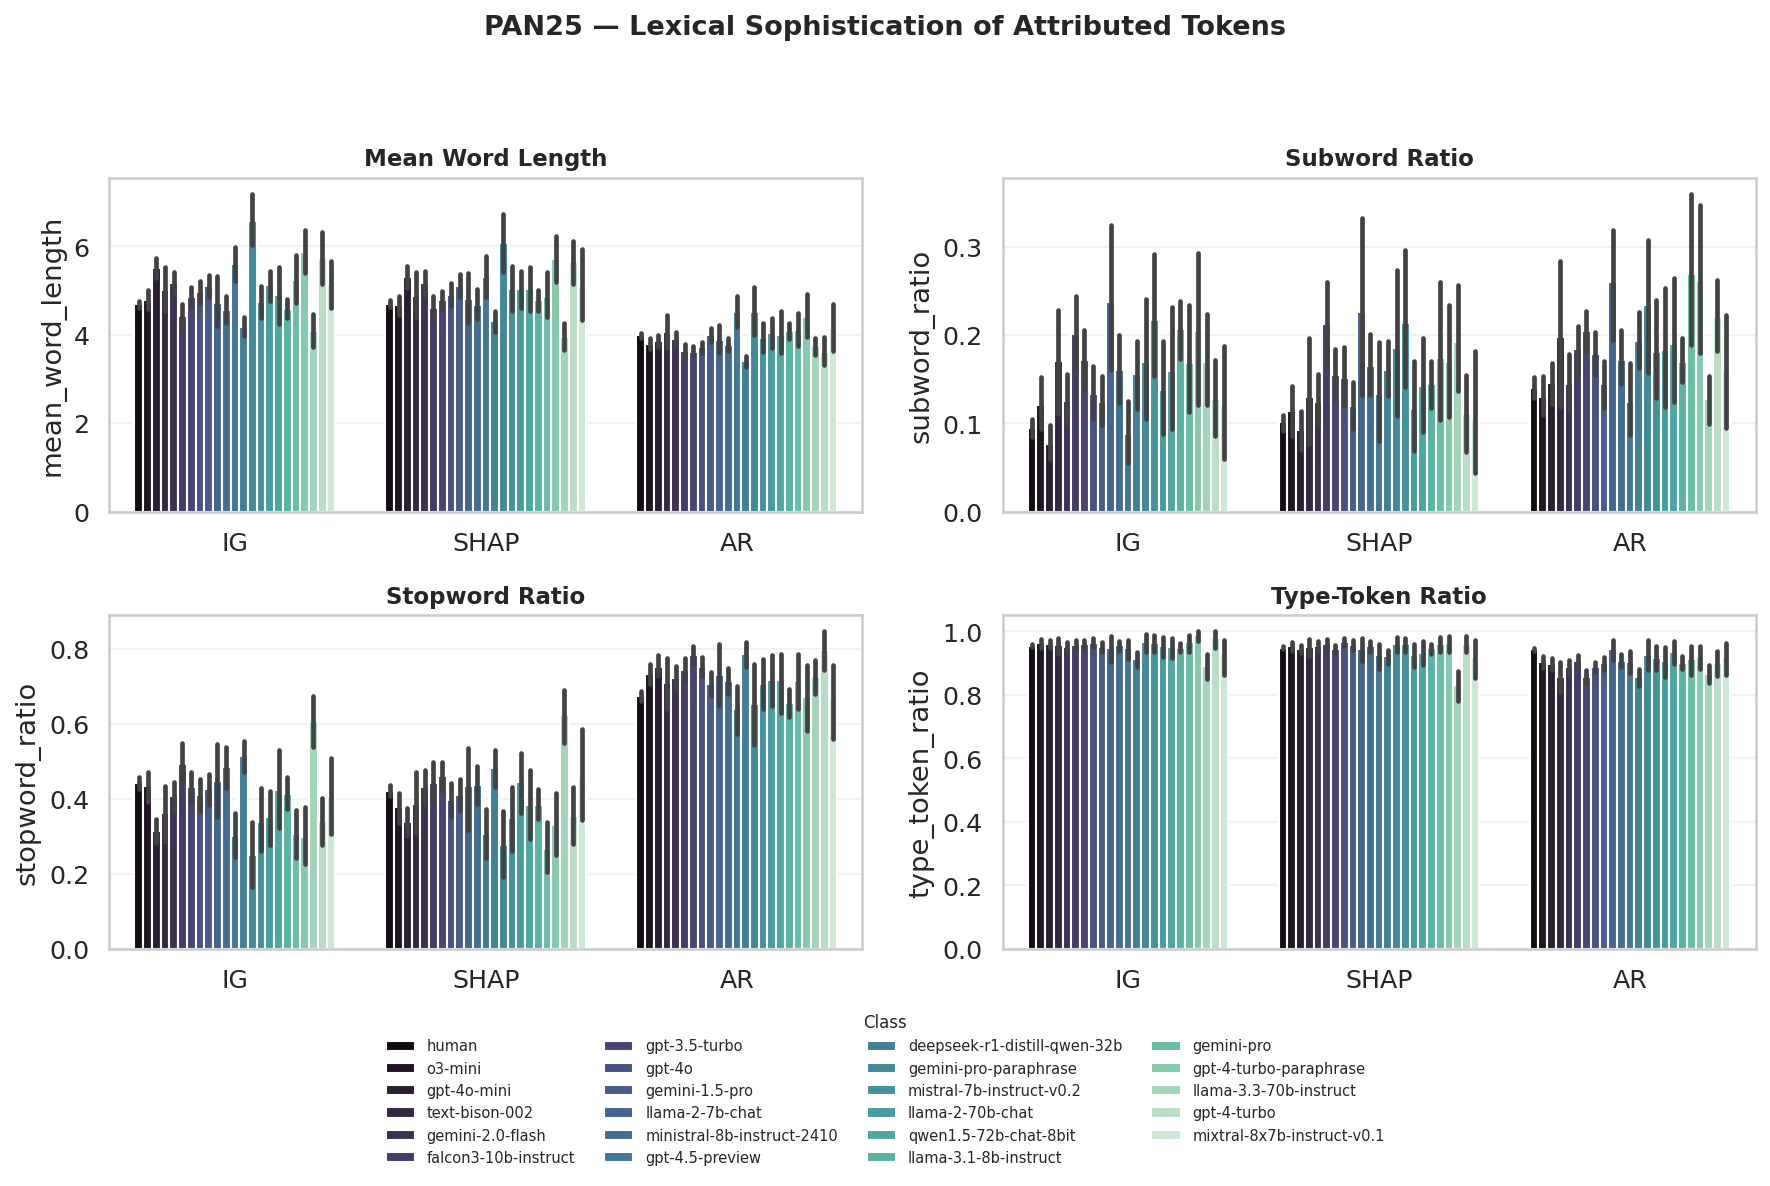

Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/authormix_modernbert_lexical_sophistication.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/authormix_modernbert_lexical_sophistication.pdf


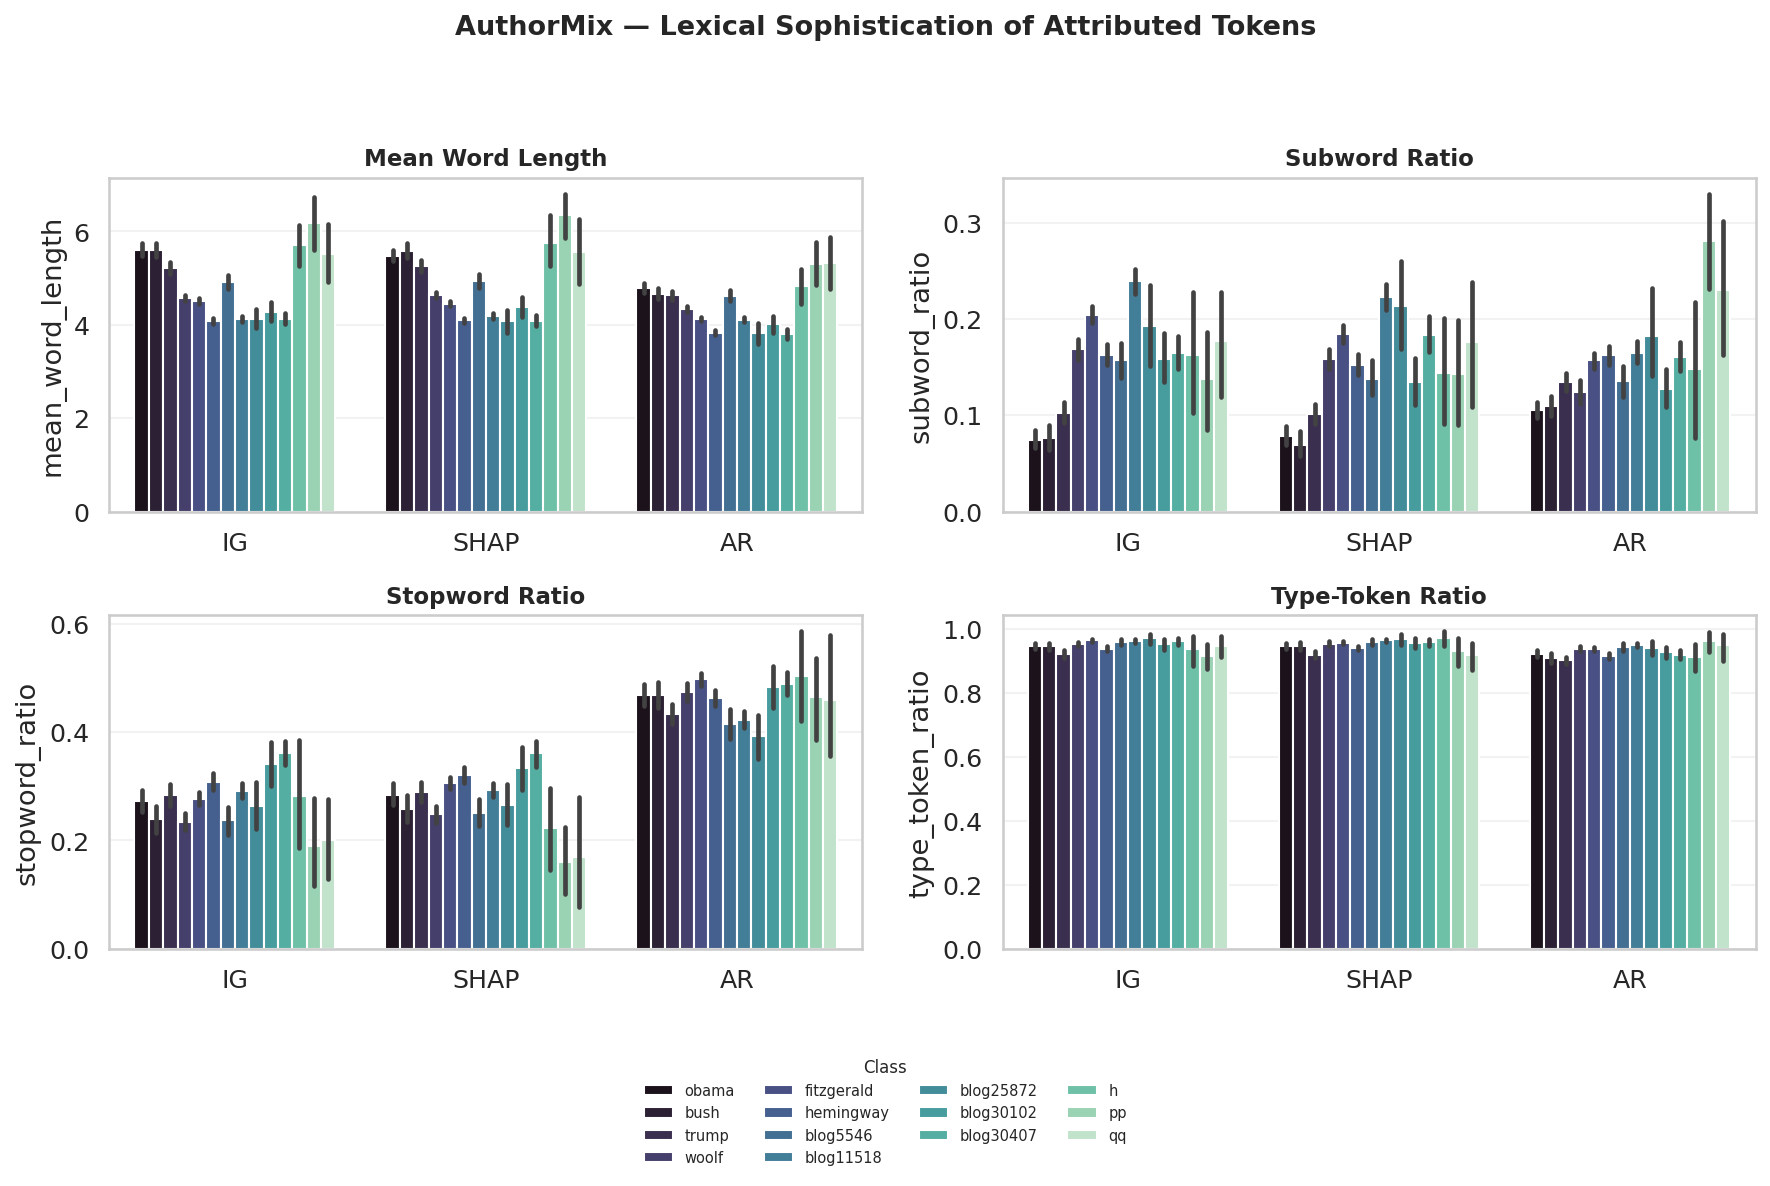

In [9]:
plot_lexical(pan_data, "PAN25")
plot_lexical(am_data,  "AuthorMix")

## 4. Attribution concentration (entropy and Gini)

Does ModernBERT spread attribution broadly or focus on a few decisive tokens?
- **Normalised entropy**: 1 = perfectly uniform, 0 = single token
- **Gini coefficient**: 1 = fully concentrated
- **Top-3 dominance**: share of total attribution held by the 3 highest-scoring tokens

In [10]:
def attribution_concentration(data, method_key="top_ig"):
    rows = []
    for ex in data:
        cls    = ex["class_name"]
        scores = np.array([abs(float(t[1])) for t in ex[method_key]])
        if scores.sum() == 0:
            continue
        probs = scores / scores.sum()
        n     = len(probs)

        entropy     = -np.sum(probs * np.log2(probs + 1e-12))
        max_entropy = np.log2(n)
        norm_ent    = entropy / max_entropy if max_entropy > 0 else 0

        sorted_p = np.sort(probs)
        idx      = np.arange(1, n + 1)
        gini     = ((2 * np.sum(idx * sorted_p) - (n + 1) * sorted_p.sum())
                    / (n * sorted_p.sum() + 1e-12))

        top3_share = np.sort(probs)[-3:].sum() if n >= 3 else probs.sum()

        rows.append({
            "class": cls,
            "normalised_entropy": norm_ent,
            "gini":               gini,
            "top3_dominance":     top3_share,
            "example_idx": ex["example_idx"],
        })
    return pd.DataFrame(rows)

def plot_concentration(data, dataset_name, save_dir=None):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=150)
    for ax, (mk, ml) in zip(axes, [
        ("top_ig","Integrated Gradients"),
        ("top_gs","GradientSHAP"),
        ("top_ar","Attention Rollout"),
    ]):
        df = attribution_concentration(data, mk)
        if df.empty:
            ax.set_visible(False)
            continue
        classes = sorted(df["class"].unique())
        metrics = ["normalised_entropy", "gini", "top3_dominance"]
        x = np.arange(len(metrics))
        w = 0.8 / len(classes)
        class_colors = mako_palette(len(classes))
        for i, cls in enumerate(classes):
            sub  = df[df["class"] == cls]
            vals = [sub[m].mean() for m in metrics]
            errs = [sub[m].std()  for m in metrics]
            ax.bar(x + i*w, vals, w, yerr=errs, label=cls,
                   color=class_colors[i], capsize=2, edgecolor="white")
        ax.set_xticks(x + w * len(classes) / 2)
        ax.set_xticklabels(["Norm. Entropy", "Gini", "Top-3 Share"], fontsize=8)
        ax.set_title(ml, fontsize=11, fontweight="bold")
        ax.legend(fontsize=5, ncol=3)
        ax.set_ylim(0, 1.1)
        ax.grid(axis="y", alpha=0.25)
    fig.suptitle(f"{dataset_name} — Attribution Concentration",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    save_plot(fig, f"{dataset_name}_modernbert_attribution_concentration", save_dir=save_dir)
    plt.show()


Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/pan25_modernbert_attribution_concentration.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/pan25_modernbert_attribution_concentration.pdf


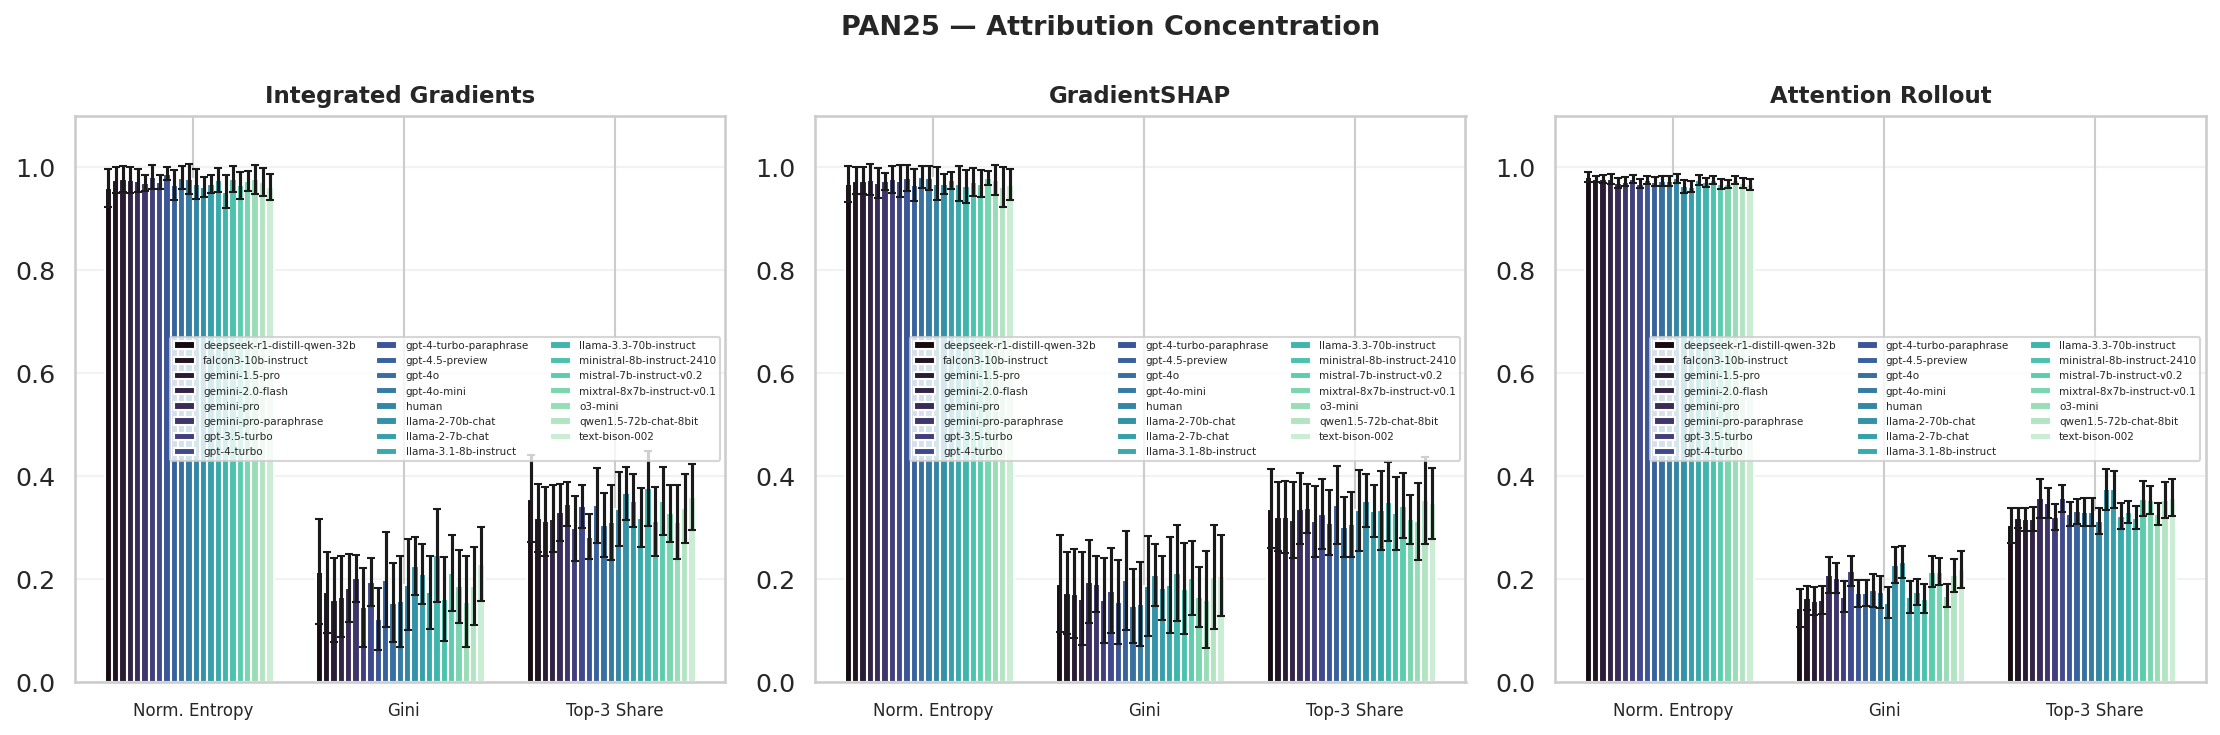

Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/authormix_modernbert_attribution_concentration.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/authormix_modernbert_attribution_concentration.pdf


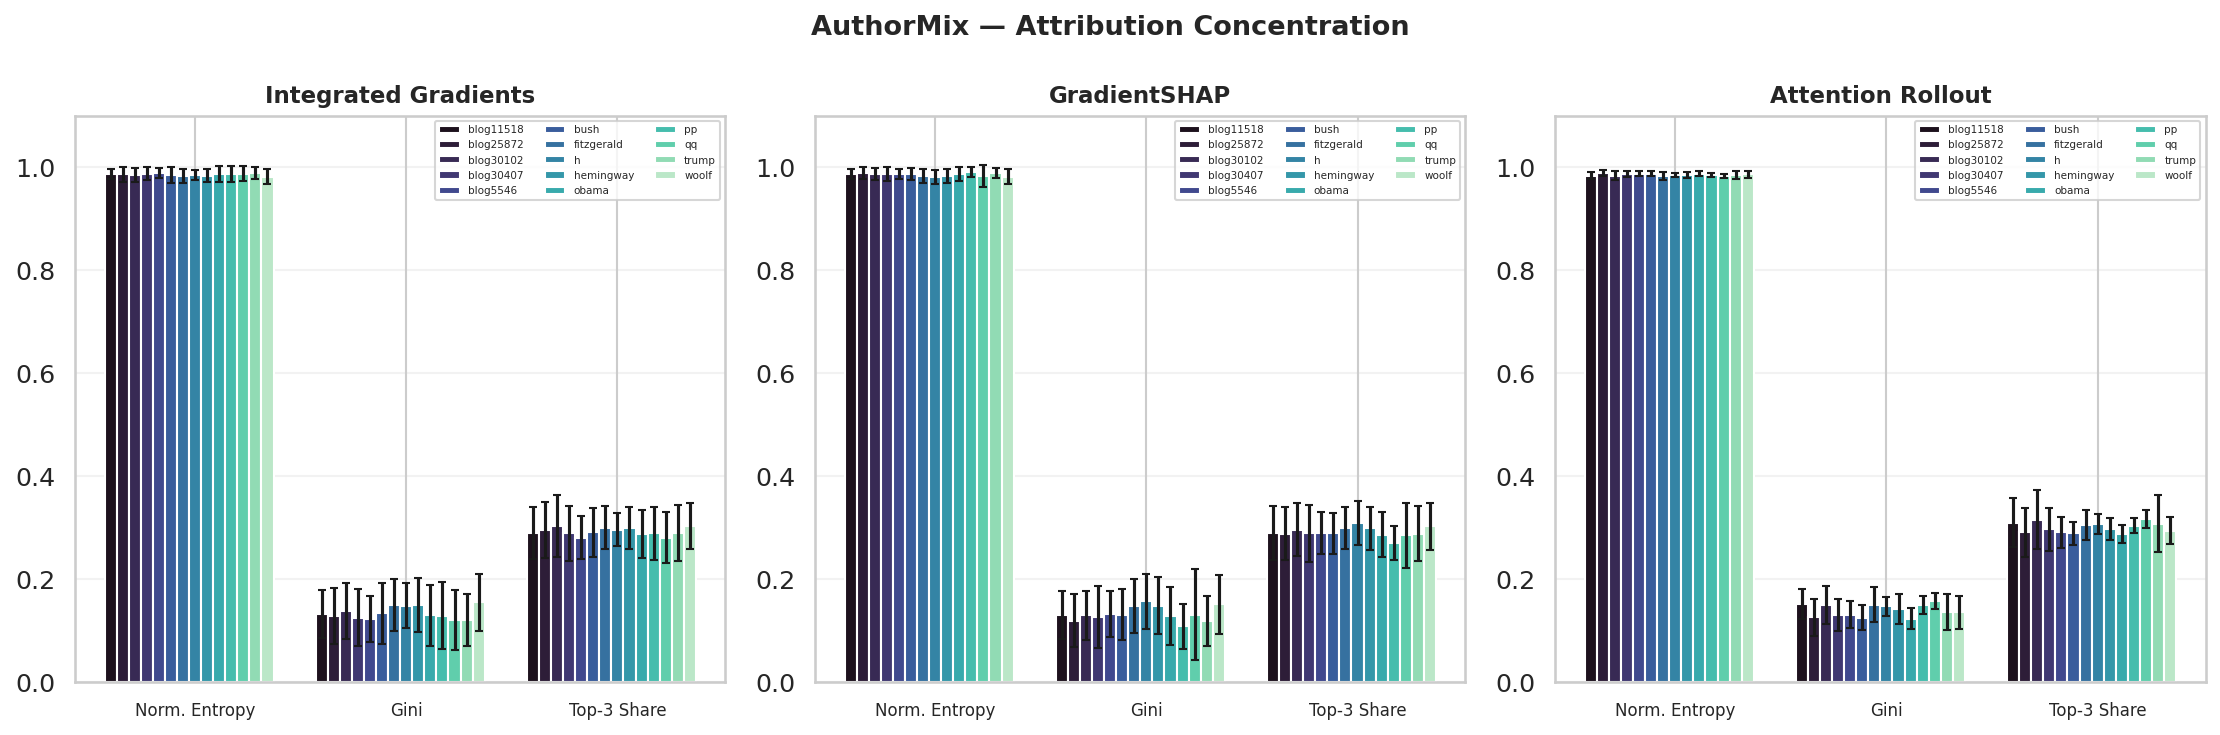

In [11]:
plot_concentration(pan_data, "PAN25")
plot_concentration(am_data,  "AuthorMix")

## 5. Cross-method agreement (Jaccard overlap)

If IG, SHAP, and AR agree on the same tokens, this indicates high confidence that those tokens
are genuinely important for classification (not artefacts of a single method).

In [12]:
def pairwise_agreement(data):
    methods = [("top_ig","IG"), ("top_gs","SHAP"), ("top_ar","AR")]
    rows = []
    for ex in data:
        cls  = ex["class_name"]
        sets = {lbl: set(t[0] for t in ex[key]) for key, lbl in methods}
        for (l1, s1), (l2, s2) in combinations(sets.items(), 2):
            union   = s1 | s2
            jaccard = len(s1 & s2) / len(union) if union else 0
            rows.append({"class": cls, "pair": f"{l1}-{l2}",
                         "jaccard": jaccard, "overlap_count": len(s1 & s2),
                         "example_idx": ex["example_idx"]})
    return pd.DataFrame(rows)

def plot_agreement(data, dataset_name, save_dir=None):
    df = pairwise_agreement(data)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4), dpi=150)

    if df.empty:
        for ax in axes:
            ax.set_visible(False)
        fig.suptitle(f"{dataset_name} — Cross-Method Agreement", fontsize=13, fontweight="bold")
        save_plot(fig, f"{dataset_name}_modernbert_cross_method_agreement", save_dir=save_dir)
        plt.show()
        return df

    classes = sorted(df["class"].unique())
    palette = {c: color for c, color in zip(classes, mako_palette(len(classes)))}
    sns.barplot(data=df, x="pair", y="jaccard", hue="class",
                ax=axes[0], palette=palette, edgecolor="white")
    axes[0].set_title("Jaccard Overlap by Method Pair", fontsize=11, fontweight="bold")
    axes[0].set_ylabel("Jaccard Similarity"); axes[0].set_xlabel("")
    axes[0].legend(fontsize=6, ncol=3)
    axes[0].grid(axis="y", alpha=0.25)

    labels = ["IG", "SHAP", "AR"]
    mat = np.eye(3)
    for i, m1 in enumerate(labels):
        for j, m2 in enumerate(labels):
            if i != j:
                sub = df[(df["pair"] == f"{m1}-{m2}") | (df["pair"] == f"{m2}-{m1}")]
                mat[i][j] = sub["jaccard"].mean() if len(sub) > 0 else 0
    sns.heatmap(mat, annot=True, fmt=".2f", xticklabels=labels, yticklabels=labels,
                cmap="mako", ax=axes[1], vmin=0, vmax=1, square=True,
                cbar_kws={"label":"Jaccard"})
    axes[1].set_title("Average Pairwise Agreement", fontsize=11, fontweight="bold")

    fig.suptitle(f"{dataset_name} — Cross-Method Agreement",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    save_plot(fig, f"{dataset_name}_modernbert_cross_method_agreement", save_dir=save_dir)
    plt.show()
    return df


Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/pan25_modernbert_cross_method_agreement.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/pan25_modernbert_cross_method_agreement.pdf


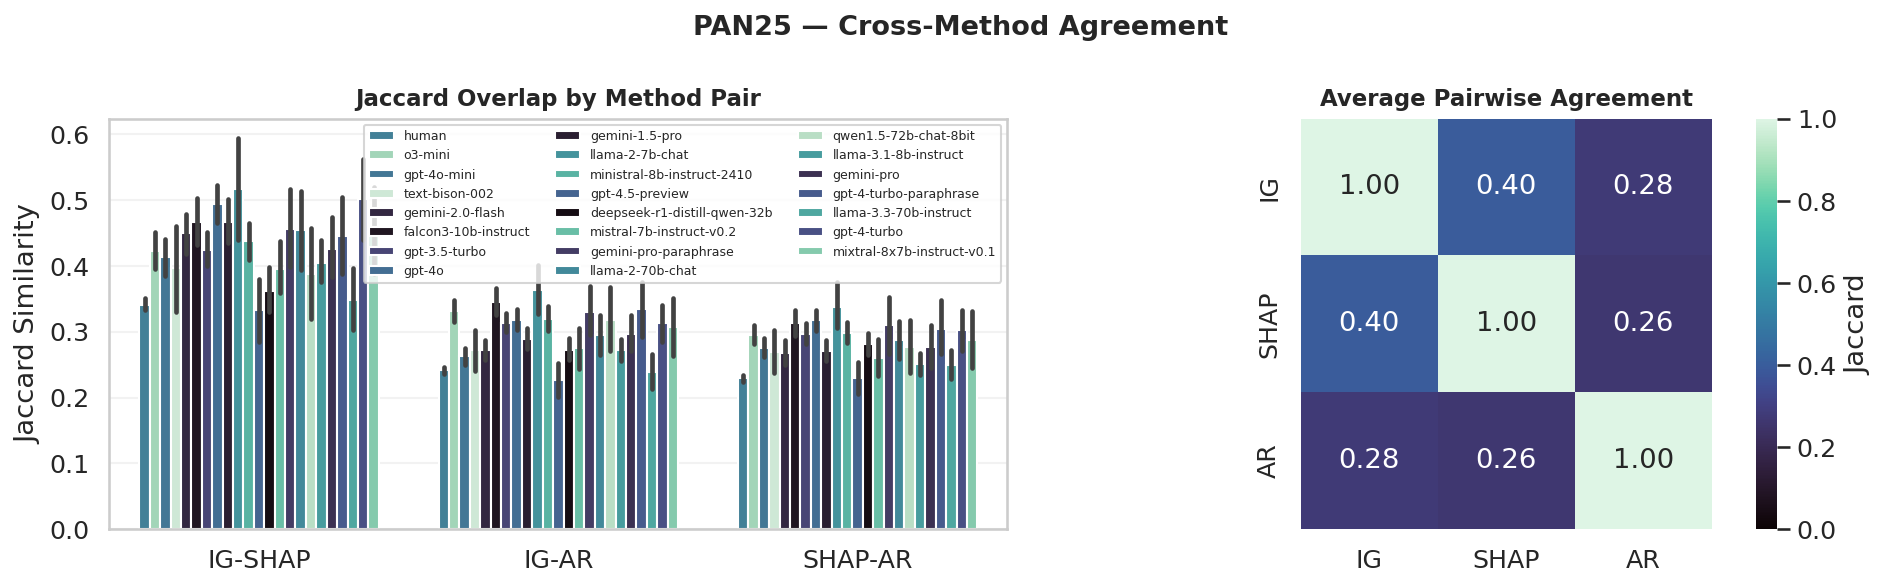

Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/authormix_modernbert_cross_method_agreement.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/authormix_modernbert_cross_method_agreement.pdf


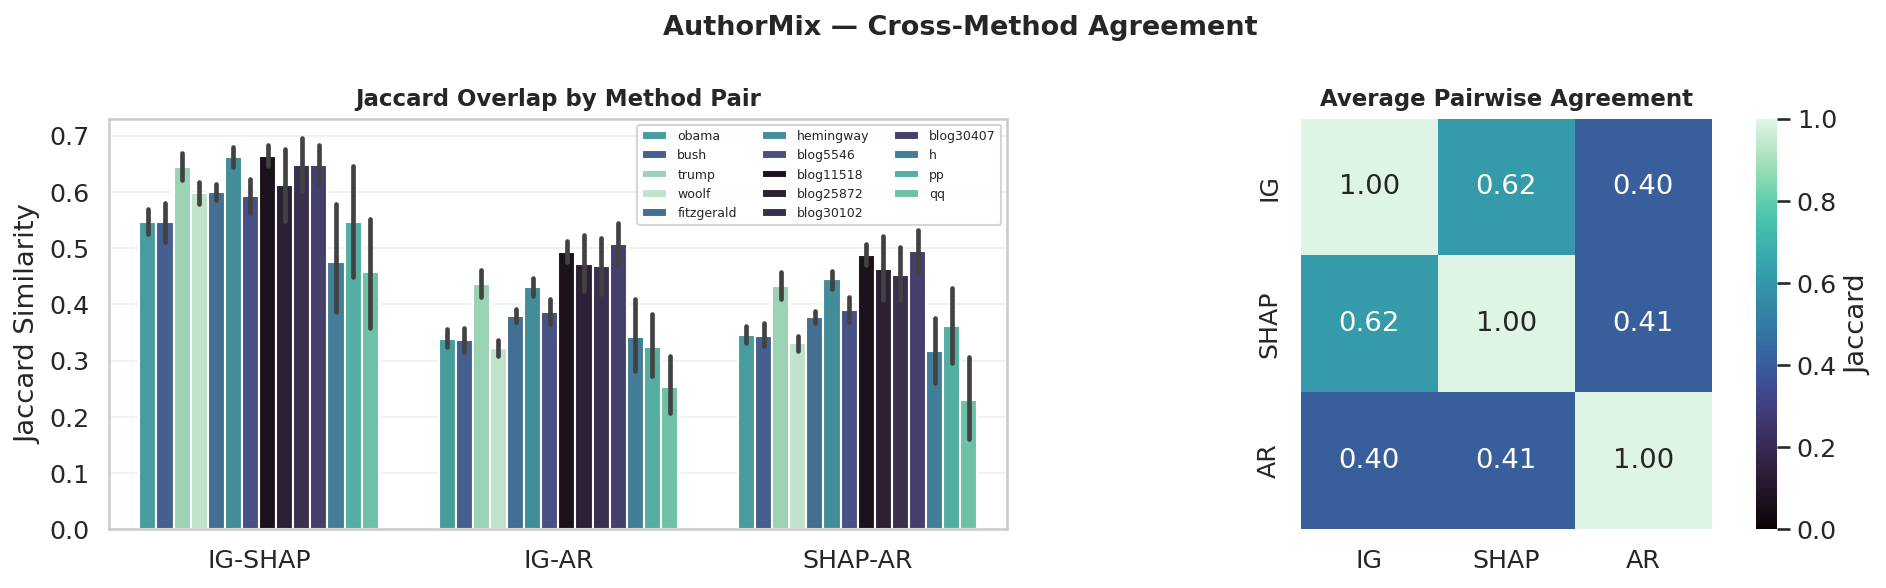


PAN25 — Mean Jaccard Overlap:


,mean,std
pair,,
IG-AR,0.276,0.116
IG-SHAP,0.397,0.199
SHAP-AR,0.264,0.115



AuthorMix — Mean Jaccard Overlap:


,mean,std
pair,,
IG-AR,0.404,0.193
IG-SHAP,0.617,0.216
SHAP-AR,0.405,0.191



  PAN25 — Consensus Tokens (all 3 methods, first 15)
  ex0 (human): ['.']
  ex1 (o3-mini): [',', '.']
  ex2 (human): ['.']
  ex3 (human): ['.']
  ex4 (human): ['.', 'Particularly', 'they']
  ex5 (human): ['.']
  ex6 (human): ['."']
  ex7 (o3-mini): ['.', 'In', 'but']
  ex8 (o3-mini): ['.', 'the', '—']
  ex9 (human): [',', '.', 'the']
  ex10 (gpt-4o-mini): ['.']
  ex11 (text-bison-002): [',', '.']
  ex12 (gpt-4o-mini): ['.']
  ex13 (gemini-2.0-flash): ['.']
  ex14 (falcon3-10b-instruct): [',', '.']

  AuthorMix — Consensus Tokens (all 3 methods, first 15)
  ex0 (obama): ['.', 'Much', 'Thank', 'grac', 'ias', 'much', 'very', 'you']
  ex1 (obama): ['--', '.', 'Africa', 'Ebola', 'doctors', 'workers']
  ex2 (obama): ['--', '.']
  ex3 (obama): ["'ve", ',', '.', 'immigrants']
  ex4 (obama): [',', '.', ':', '?', 'But', 'Why', 'asked', 'debate', 'many', 'still', 'welcomed']
  ex5 (obama): [',', '.', 'but', 'climate', 'the']
  ex6 (obama): [',', '.', 'celebration', 'society']
  ex7 (obama): [','

In [13]:
plot_agreement(pan_data, "PAN25")
plot_agreement(am_data,  "AuthorMix")

pan_agree = pairwise_agreement(pan_data)
am_agree  = pairwise_agreement(am_data)

print("\nPAN25 — Mean Jaccard Overlap:")
display(pan_agree.groupby("pair")["jaccard"].agg(["mean","std"]).round(3))

print("\nAuthorMix — Mean Jaccard Overlap:")
display(am_agree.groupby("pair")["jaccard"].agg(["mean","std"]).round(3))

# Tokens agreed on by ALL 3 methods
def consensus_tokens(data, dataset_name, max_show=15):
    print(f"\n{'='*60}")
    print(f"  {dataset_name} — Consensus Tokens (all 3 methods, first {max_show})")
    print(f"{'='*60}")
    shown = 0
    for ex in data:
        if shown >= max_show:
            break
        ig_set = set(clean_tok(t[0]) for t in ex["top_ig"])
        gs_set = set(clean_tok(t[0]) for t in ex["top_gs"])
        ar_set = set(clean_tok(t[0]) for t in ex["top_ar"])
        consensus = (ig_set & gs_set & ar_set) - {"", "[CLS]", "[SEP]"}
        if consensus:
            print(f"  ex{ex['example_idx']} ({ex['class_name']}): {sorted(consensus)}")
            shown += 1

consensus_tokens(pan_data, "PAN25")
consensus_tokens(am_data,  "AuthorMix")

## 6. Vocabulary fingerprints

Which tokens does each class "own"? Attribution scores are aggregated across all examples
per class to build class-level vocabulary signatures.

In [14]:
def vocabulary_fingerprint(data, method_key="top_ig"):
    class_score = defaultdict(lambda: defaultdict(float))
    class_freq  = defaultdict(lambda: defaultdict(int))
    for ex in data:
        cls = ex["class_name"]
        for tok, score in ex[method_key]:
            ct = clean_tok(tok).lower()
            if not ct or ct in {"[cls]", "[sep]", "[pad]"}:
                continue
            class_score[cls][ct] += abs(float(score))
            class_freq[cls][ct]  += 1
    return class_score, class_freq

def plot_fingerprint(data, dataset_name, method_key="top_ig", method_label="IG",
                     top_n=15, classes_to_show=None, save_dir=None):
    scores, freqs = vocabulary_fingerprint(data, method_key)
    classes = sorted(scores.keys()) if classes_to_show is None else classes_to_show
    classes = [cls for cls in classes if cls in scores]
    if not classes:
        print(f"No fingerprint data for {dataset_name} ({method_label}).")
        return None
    fig, axes = plt.subplots(1, len(classes),
                             figsize=(6 * len(classes), 6),
                             squeeze=False, dpi=150)
    for ax, cls in zip(axes[0], classes):
        top = sorted(scores[cls].items(), key=lambda x: -x[1])[:top_n]
        words  = [w for w, _ in top]
        vals   = [s for _, s in top]
        f_vals = [freqs[cls][w] for w in words]
        colors = sns.color_palette("mako", as_cmap=True)(np.linspace(0.3, 0.9, max(len(words), 1)))[::-1]
        ax.barh(range(len(words)), vals, color=colors, edgecolor="white")
        ax.set_yticks(range(len(words)))
        ax.set_yticklabels([f"{w}  (x{f})" for w, f in zip(words, f_vals)], fontsize=9)
        ax.invert_yaxis()
        ax.set_xlabel("Total Attribution Score")
        ax.set_title(f"Class: {cls}", fontsize=12, fontweight="bold")
        ax.grid(axis="x", alpha=0.25)
    fig.suptitle(f"{dataset_name} — Vocabulary Fingerprint ({method_label})",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    class_part = "_".join(classes[:4]) if classes_to_show is not None else "all_classes"
    save_plot(fig, f"{dataset_name}_modernbert_vocabulary_fingerprint_{method_label}_{class_part}", save_dir=save_dir)
    plt.show()
    return scores, freqs

def exclusive_tokens(data, method_key="top_ig", top_n=10):
    class_toks = defaultdict(set)
    for ex in data:
        cls = ex["class_name"]
        for tok, _ in ex[method_key]:
            ct = clean_tok(tok).lower()
            if ct and ct not in {"[cls]","[sep]","[pad]"}:
                class_toks[cls].add(ct)
    print(f"\nExclusive tokens ({method_key}, up to {top_n}/class):")
    all_others = {}
    for cls in class_toks:
        others = set()
        for other in class_toks:
            if other != cls:
                others |= class_toks[other]
        all_others[cls] = class_toks[cls] - others
    for cls in sorted(class_toks.keys()):
        excl = sorted(all_others[cls])[:top_n]
        print(f"  {cls} ({len(all_others[cls])} total): {excl if excl else 'none'}")


Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/pan25_modernbert_vocabulary_fingerprint_ig_human_gpt-4o.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/pan25_modernbert_vocabulary_fingerprint_ig_human_gpt-4o.pdf


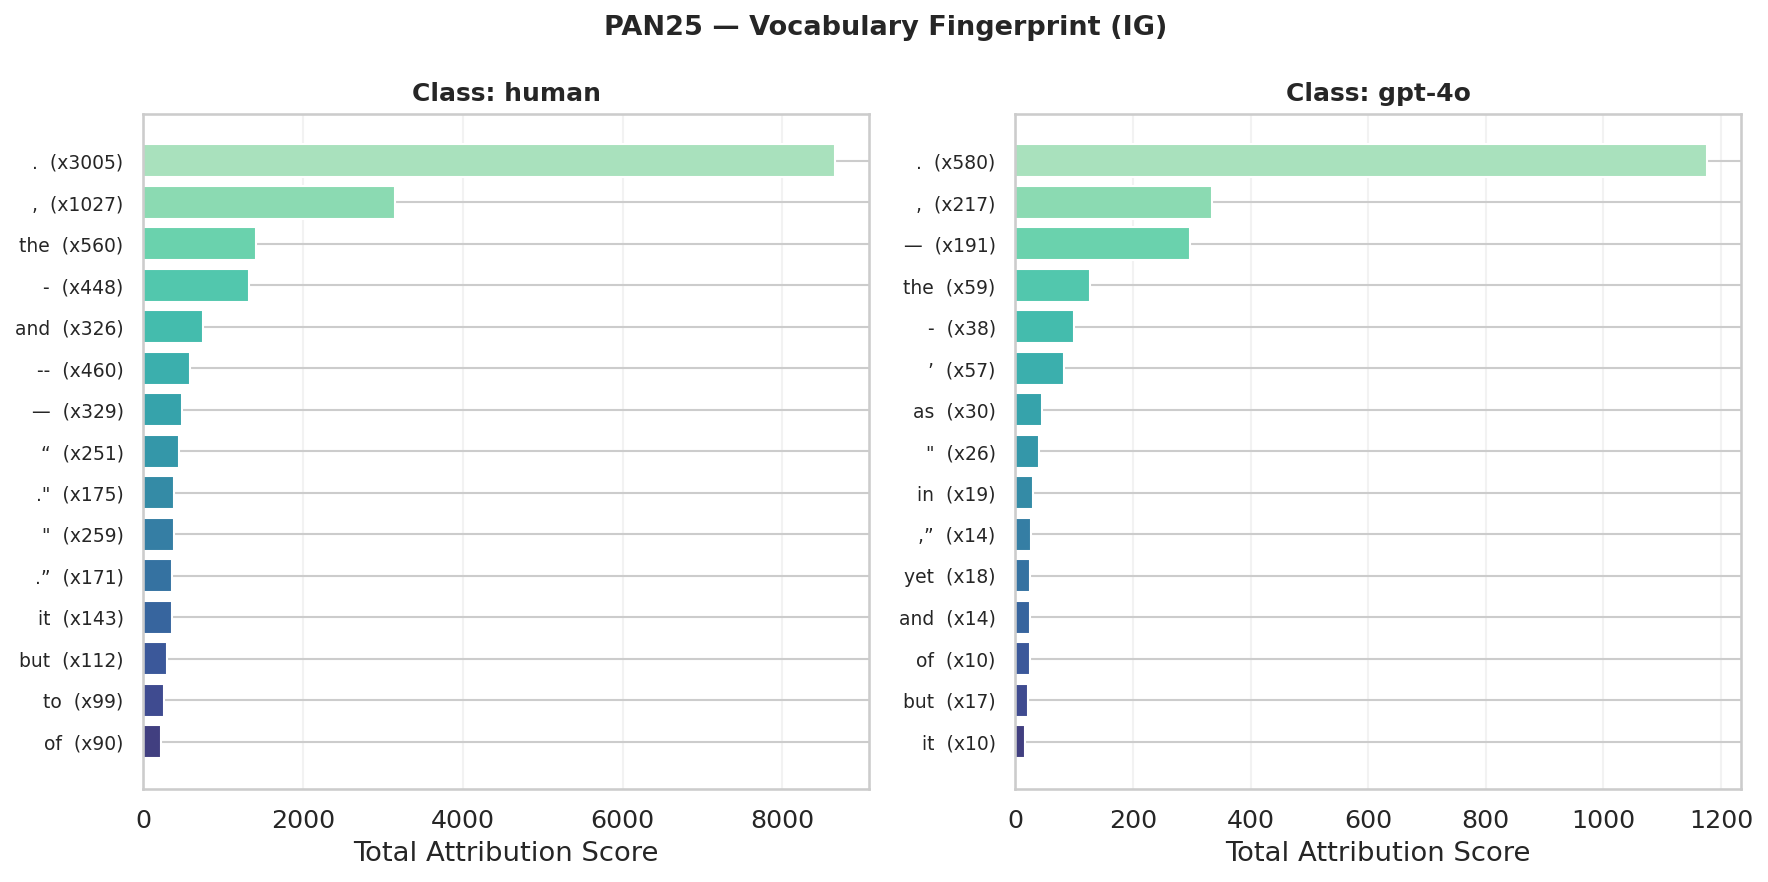

Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/pan25_modernbert_vocabulary_fingerprint_ar_human_gpt-4o.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/pan25_modernbert_vocabulary_fingerprint_ar_human_gpt-4o.pdf


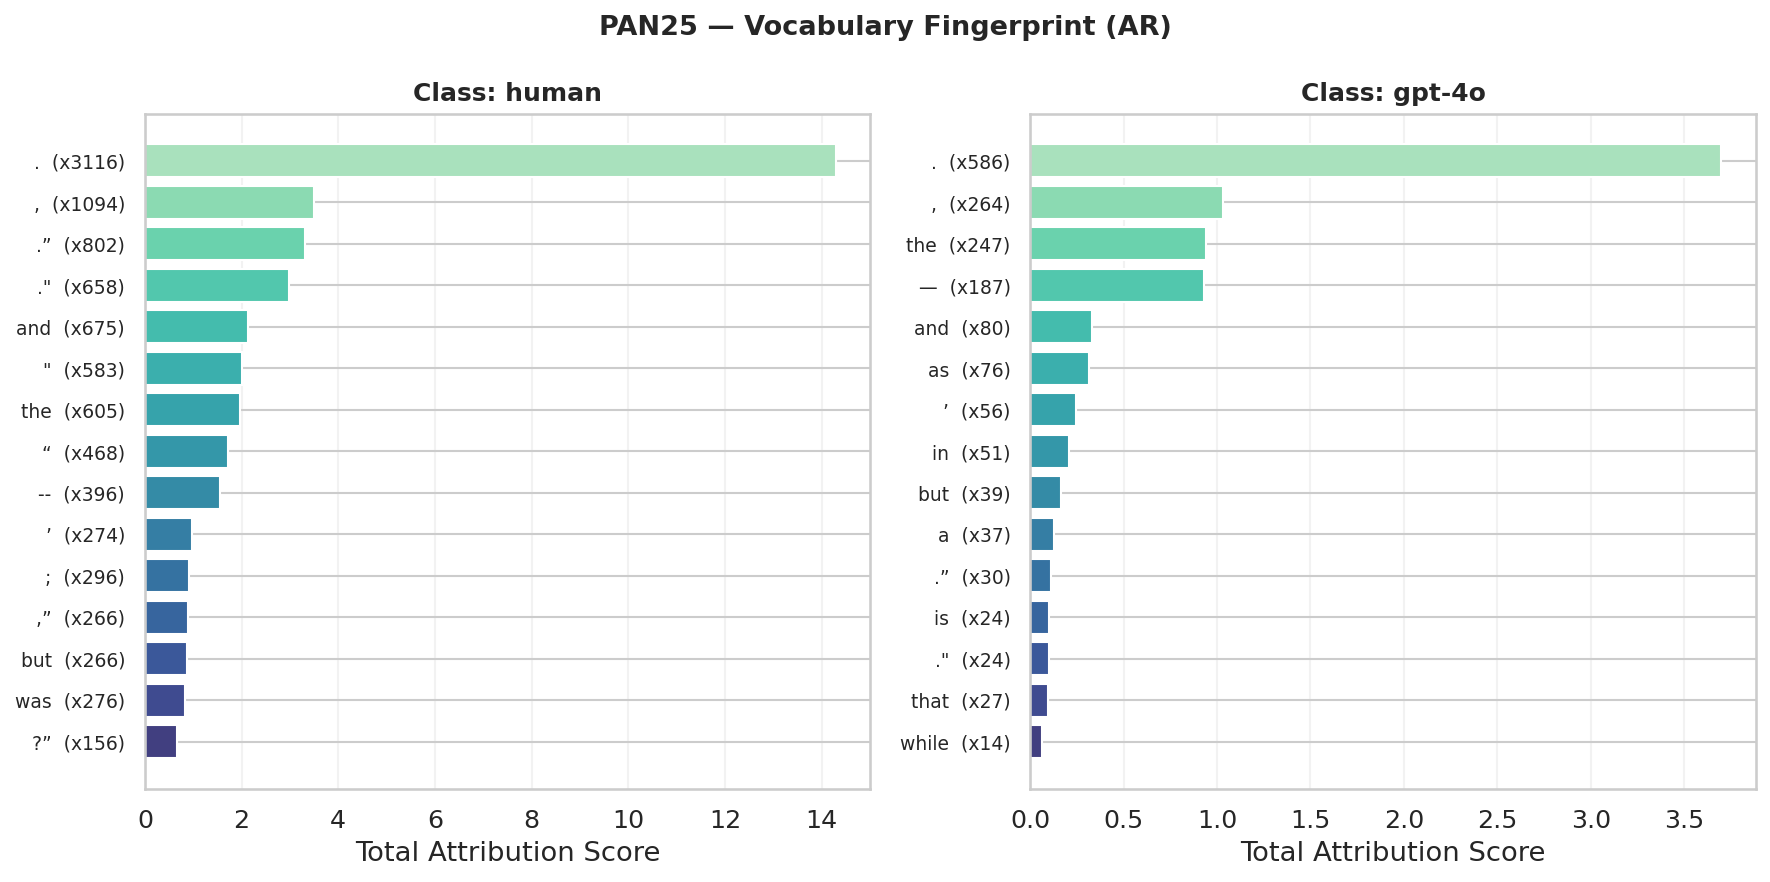

Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/authormix_modernbert_vocabulary_fingerprint_ig_obama_trump_hemingway_woolf.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/authormix_modernbert_vocabulary_fingerprint_ig_obama_trump_hemingway_woolf.pdf


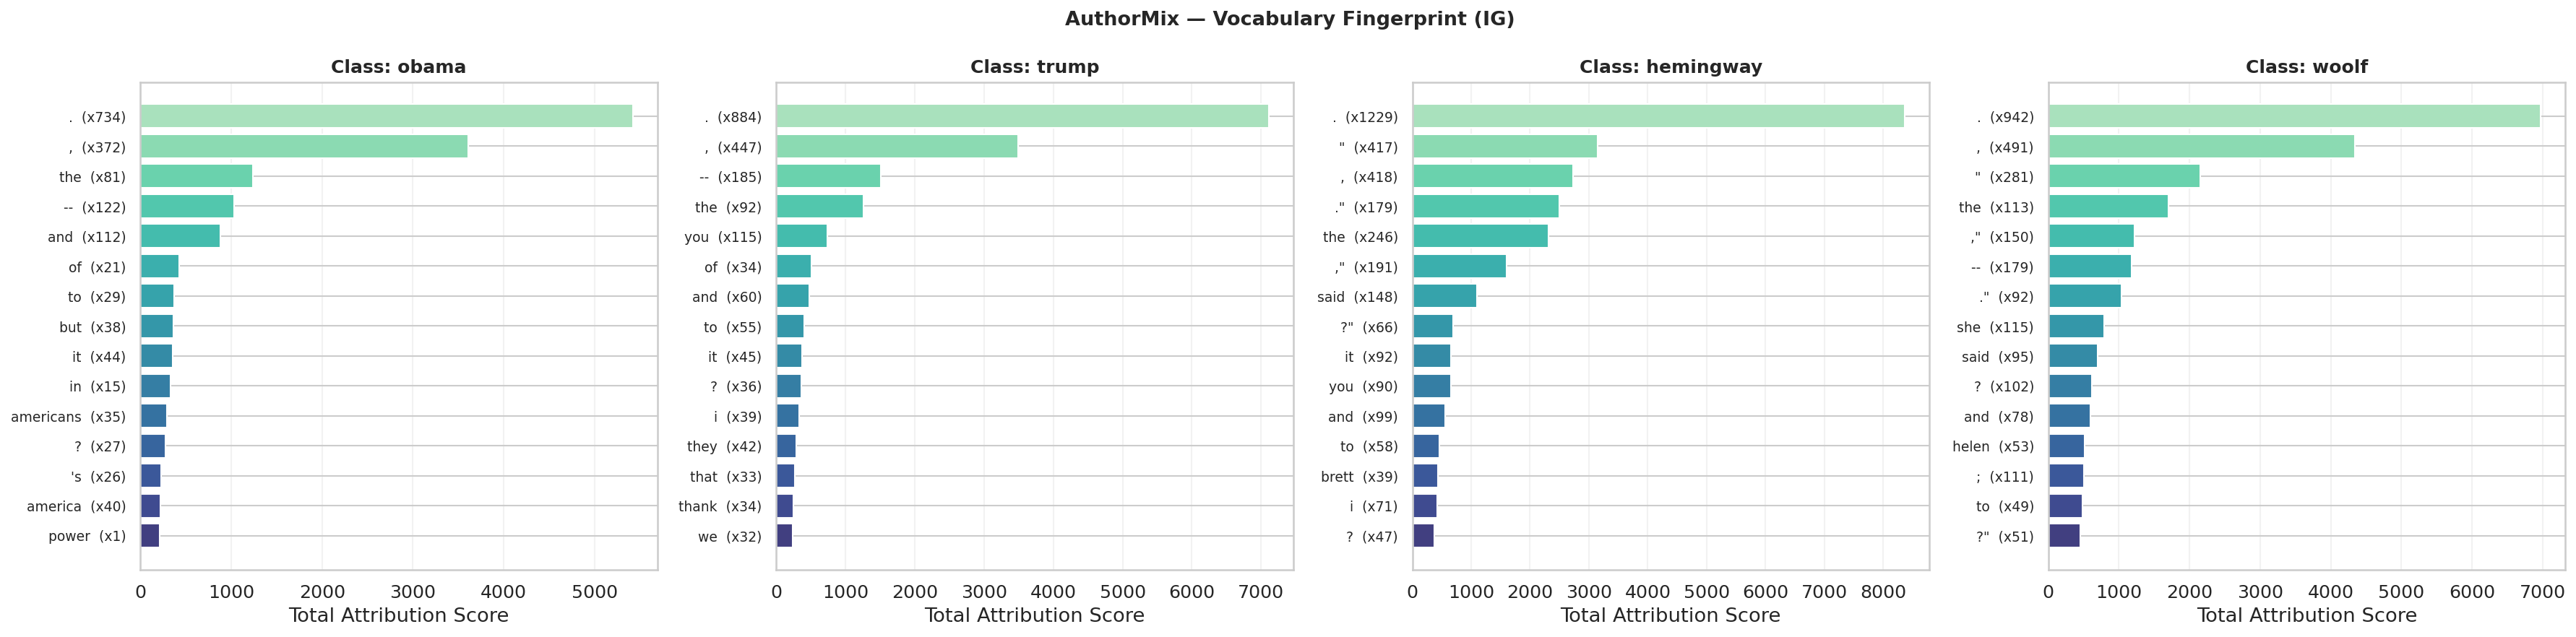


──────────────────────────────────────────────────  TOP_IG
PAN25:

Exclusive tokens (top_ig, up to 10/class):
  deepseek-r1-distill-qwen-32b (76 total): ['.—', 'arine', 'arrival', 'bark', 'before', 'bench', 'brushing', 'cabin', 'catalog', 'chair']
  falcon3-10b-instruct (65 total): ['60', 'aging', 'aling', 'antage', 'apologize', 'arc', 'armed', 'backdrop', 'beacon', 'bers']
  gemini-1.5-pro (102 total): ['accustomed', 'acknowledges', 'akes', 'amph', 'ances', 'anglo', 'appear', 'appeared', 'apprec', 'arbitrary']
  gemini-2.0-flash (90 total): [',—', '.,', 'abandon', 'actions', 'agency', 'anxiety', 'appro', 'arguably', 'arguments', 'carrying']
  gemini-pro (37 total): ['),', '98', 'andrew', 'apps', 'biden', 'bruno', 'businesses', 'capabilities', 'commonwealth', 'cyber']
  gemini-pro-paraphrase (23 total): ['+.', '2019', 'amm', 'attack', 'battles', 'cement', 'chilling', 'congress', 'development', 'ds']
  gpt-3.5-turbo (93 total): ['advised', 'advocacy', 'amed', 'ament', 'among', 'approve

In [15]:
# PAN25: human vs gpt-4o
plot_fingerprint(pan_data, "PAN25", "top_ig", "IG",
                 classes_to_show=["human", "gpt-4o"])
plot_fingerprint(pan_data, "PAN25", "top_ar", "AR",
                 classes_to_show=["human", "gpt-4o"])

# AuthorMix: literary & political contrast
plot_fingerprint(am_data, "AuthorMix", "top_ig", "IG",
                 classes_to_show=["obama", "trump", "hemingway", "woolf"])

# Exclusive tokens
for mk in ["top_ig", "top_gs"]:
    print(f"\n{'─'*50}  {mk.upper()}")
    print("PAN25:");    exclusive_tokens(pan_data, mk)
    print("AuthorMix:"); exclusive_tokens(am_data, mk)

## 7. Positional analysis

Does ModernBERT focus on the beginning (topic sentences), middle, or end of texts?
ModernBERT's 8192-token native context means the full text is available - unlike BERT's 512-token cap.

In [16]:
def positional_analysis(data, method_key="top_ig"):
    rows = []
    for ex in data:
        cls      = ex["class_name"]
        tokens   = ex["tokens"]
        n_tokens = len(tokens)
        scores   = build_attribution_scores(ex, method_key)
        top_idx  = np.argsort(scores)[-15:]
        positions = top_idx / max(n_tokens - 1, 1)
        rows.append({
            "class": cls,
            "mean_position":  positions.mean(),
            "std_position":   positions.std(),
            "first_third":    (positions < 0.33).mean(),
            "middle_third":   ((positions >= 0.33) & (positions < 0.67)).mean(),
            "last_third":     (positions >= 0.67).mean(),
            "positions":      positions.tolist(),
            "example_idx": ex["example_idx"],
        })
    return pd.DataFrame(rows)

def plot_positions(data, dataset_name, save_dir=None):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=150)
    for ax, (mk, ml) in zip(axes, [
        ("top_ig","IG"), ("top_gs","SHAP"), ("top_ar","AR")
    ]):
        df = positional_analysis(data, mk)
        if df.empty:
            ax.set_visible(False)
            continue
        classes = sorted(df["class"].unique())
        palette = {c: color for c, color in zip(classes, mako_palette(len(classes)))}
        for cls in classes:
            all_pos = []
            for _, row in df[df["class"] == cls].iterrows():
                all_pos.extend(row["positions"])
            ax.hist(all_pos, bins=15, alpha=0.4, label=cls, density=True,
                    color=palette[cls], edgecolor="white", linewidth=0.3)
        ax.set_title(ml, fontsize=11, fontweight="bold")
        ax.set_xlabel("Normalised Position (0=start, 1=end)")
        ax.set_ylabel("Density")
        ax.legend(fontsize=6, ncol=2)
        ax.grid(axis="y", alpha=0.25)
    fig.suptitle(f"{dataset_name} — Positional Distribution of Top Attributions",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    save_plot(fig, f"{dataset_name}_modernbert_positional_distribution", save_dir=save_dir)
    plt.show()

def position_table(data, dataset_name):
    print(f"\n{dataset_name} — Mean position statistics:")
    for mk, ml in [("top_ig","IG"),("top_gs","SHAP"),("top_ar","AR")]:
        df  = positional_analysis(data, mk)
        tbl = df.groupby("class")[["mean_position","first_third","middle_third","last_third"]].mean().round(3)
        print(f"  {ml}:"); display(tbl)


Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/pan25_modernbert_positional_distribution.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/pan25_modernbert_positional_distribution.pdf


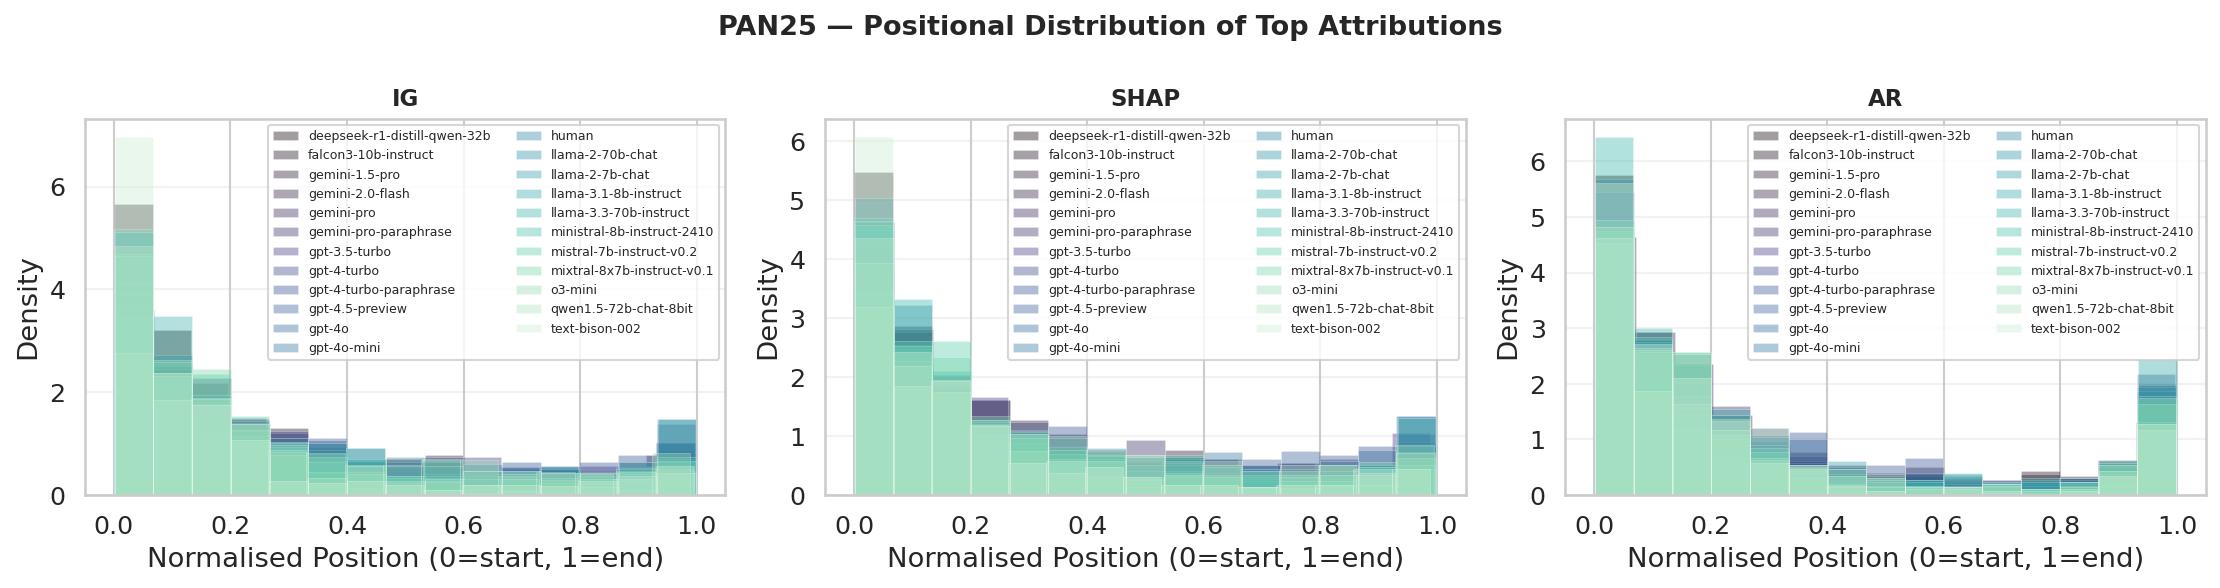

Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/authormix_modernbert_positional_distribution.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/authormix_modernbert_positional_distribution.pdf


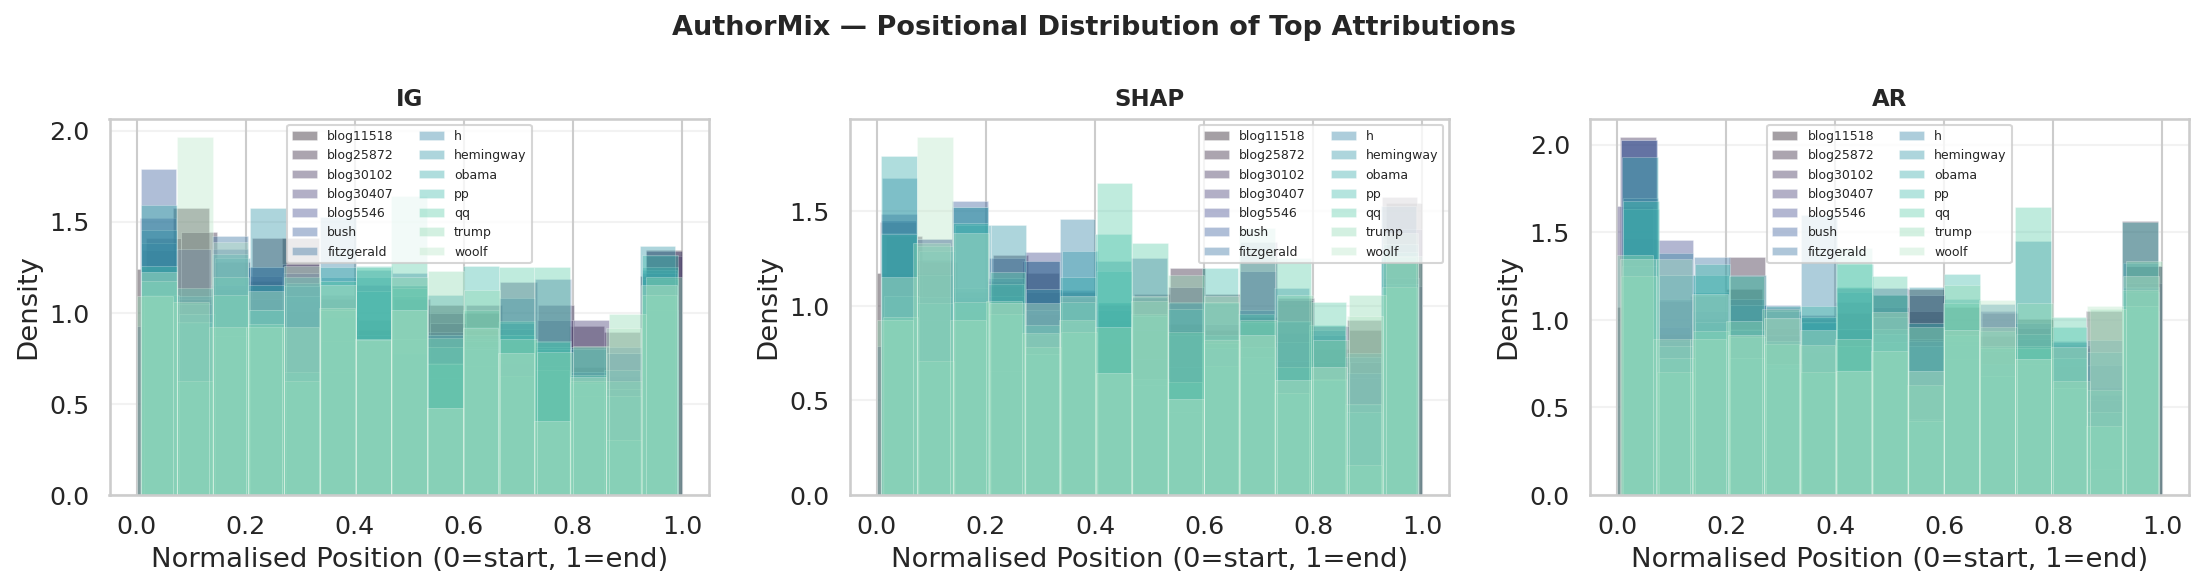


PAN25 — Mean position statistics:
  IG:


,mean_position,first_third,middle_third,last_third
class,,,,
deepseek-r1-distill-qwen-32b,0.211,0.789,0.116,0.096
falcon3-10b-instruct,0.289,0.678,0.182,0.140
gemini-1.5-pro,0.328,0.618,0.207,0.176
gemini-2.0-flash,0.305,0.638,0.191,0.171
gemini-pro,0.242,0.753,0.142,0.104
gemini-pro-paraphrase,0.309,0.676,0.160,0.164
gpt-3.5-turbo,0.349,0.580,0.240,0.180
gpt-4-turbo,0.286,0.720,0.118,0.162
gpt-4-turbo-paraphrase,0.393,0.524,0.231,0.244


  SHAP:


,mean_position,first_third,middle_third,last_third
class,,,,
deepseek-r1-distill-qwen-32b,0.207,0.787,0.138,0.076
falcon3-10b-instruct,0.281,0.700,0.184,0.116
gemini-1.5-pro,0.306,0.636,0.216,0.149
gemini-2.0-flash,0.299,0.656,0.189,0.156
gemini-pro,0.242,0.753,0.142,0.104
gemini-pro-paraphrase,0.322,0.629,0.218,0.153
gpt-3.5-turbo,0.334,0.620,0.200,0.180
gpt-4-turbo,0.284,0.716,0.127,0.158
gpt-4-turbo-paraphrase,0.362,0.569,0.216,0.216


  AR:


...

,mean_position,first_third,middle_third,last_third
class,,,,
blog11518,0.444,0.431,0.320,0.249
blog25872,0.465,0.404,0.307,0.289
blog30102,0.476,0.371,0.333,0.296
blog30407,0.489,0.368,0.308,0.324
blog5546,0.447,0.422,0.300,0.278
bush,0.456,0.411,0.293,0.296
fitzgerald,0.462,0.396,0.327,0.278
h,0.463,0.352,0.371,0.276
hemingway,0.462,0.382,0.371,0.247


  SHAP:


,mean_position,first_third,middle_third,last_third
class,,,,
blog11518,0.489,0.364,0.320,0.316
blog25872,0.500,0.349,0.327,0.324
blog30102,0.467,0.384,0.320,0.296
blog30407,0.502,0.341,0.326,0.332
blog5546,0.451,0.416,0.302,0.282
bush,0.443,0.402,0.340,0.258
fitzgerald,0.457,0.396,0.344,0.260
h,0.469,0.371,0.310,0.319
hemingway,0.462,0.396,0.336,0.269


  AR:


,mean_position,first_third,middle_third,last_third
class,,,,
blog11518,0.494,0.333,0.364,0.302
blog25872,0.493,0.360,0.324,0.316
blog30102,0.454,0.384,0.333,0.282
blog30407,0.465,0.386,0.326,0.288
blog5546,0.435,0.407,0.333,0.260
bush,0.459,0.396,0.320,0.284
fitzgerald,0.460,0.407,0.313,0.280
h,0.464,0.352,0.352,0.295
hemingway,0.470,0.371,0.353,0.276


In [17]:
POS_POS_N = 30  # per class for positional analysis
pan_pos_s = stratified_sample(pan_data, n_per_class=POS_POS_N)
am_pos_s  = stratified_sample(am_data,  n_per_class=POS_POS_N)

plot_positions(pan_pos_s, "PAN25")
plot_positions(am_pos_s,  "AuthorMix")
position_table(pan_pos_s, "PAN25")
position_table(am_pos_s,  "AuthorMix")

## 8. Statistical testing

Beyond p-values: Cohen's d (standardised effect size) reveals whether the
difference between two classes is practically meaningful.
Rule of thumb: |d| < 0.2 = small, 0.2-0.8 = medium, > 0.8 = large.

In [18]:
def cohens_d(a, b):
    na, nb = len(a), len(b)
    if na < 2 or nb < 2:
        return np.nan
    pooled = np.sqrt(((na-1)*a.std()**2 + (nb-1)*b.std()**2) / (na+nb-2))
    return (a.mean() - b.mean()) / pooled if pooled > 0 else 0

def statistical_comparison(ratios_df, dataset_name, class_a, class_b):
    """
    Class-pair tests on thesis-facing lexical ratios.

    Newline stays in the raw CSV as an audit category, but these tests use
    content/punctuation/stopword ratios renormalised over non-newline tokens.
    """
    results = []
    metric_map = {
        "content_nonnewline_ratio": "Content",
        "punct_nonnewline_ratio": "Punctuation",
        "stop_nonnewline_ratio": "Stopword",
    }

    for prefix, label in METHODS:
        for rtype, metric_label in metric_map.items():
            col  = f"{prefix}_{rtype}"
            a_v  = ratios_df[ratios_df["class"] == class_a][col].dropna().values
            b_v  = ratios_df[ratios_df["class"] == class_b][col].dropna().values
            if len(a_v) < 2 or len(b_v) < 2:
                continue

            t_s, t_p = ttest_ind(a_v, b_v, equal_var=False)
            u_s, u_p = mannwhitneyu(a_v, b_v, alternative="two-sided")
            d        = cohens_d(a_v, b_v)

            results.append({
                "Method": label,
                "Metric": metric_label,
                f"Mean {class_a}": f"{a_v.mean():.3f}",
                f"Mean {class_b}": f"{b_v.mean():.3f}",
                "Cohen's d": f"{d:.3f}",
                "t p-value": f"{t_p:.2e}",
                "U p-value": f"{u_p:.2e}",
            })

    if not results:
        print(f"No data for {class_a} vs {class_b}")
        return None

    df_out = pd.DataFrame(results)
    print(f"\n{'='*70}")
    print(f"  {dataset_name}: {class_a} vs {class_b}")
    print("  Lexical ratios are non-newline normalised.")
    print("="*70)
    display(df_out)
    return df_out

def effect_size_heatmap(stats_df, title, save_dir=None):
    if stats_df is None or len(stats_df) == 0:
        return
    df = stats_df.copy()
    df["d_val"] = df["Cohen's d"].astype(float)
    pivot = df.pivot(index="Metric", columns="Method", values="d_val")
    fig, ax = plt.subplots(figsize=(7, 4), dpi=150)
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="mako", center=0,
                ax=ax, linewidths=0.5, vmin=-2, vmax=2)
    ax.set_title(f"{title}\nCohen's d (positive = higher for first class)",
                 fontsize=11, fontweight="bold")
    plt.tight_layout()
    save_plot(fig, f"modernbert_effect_size_{title}", save_dir=save_dir)
    plt.show()



  PAN25: human vs gpt-4o
  Lexical ratios are non-newline normalised.


,Method,Metric,Mean human,Mean gpt-4o,Cohen's d,t p-value,U p-value
0,IG,Content,0.253,0.219,0.207,4.41e-03,7.93e-03
1,IG,Punctuation,0.551,0.634,-0.448,6.21e-09,1.10e-08
2,IG,Stopword,0.196,0.147,0.353,2.76e-07,4.16e-06
3,SHAP,Content,0.284,0.232,0.292,3.16e-05,5.22e-04
4,SHAP,Punctuation,0.514,0.625,-0.570,5.89e-13,3.91e-13
5,SHAP,Stopword,0.202,0.143,0.397,4.29e-09,2.21e-07
6,AR,Content,0.133,0.124,0.090,2.06e-01,4.24e-01
7,AR,Punctuation,0.597,0.529,0.385,2.09e-10,1.10e-06
8,AR,Stopword,0.270,0.347,-0.550,2.92e-17,5.40e-14


Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/modernbert_effect_size_pan25_human_vs_gpt-4o.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/modernbert_effect_size_pan25_human_vs_gpt-4o.pdf


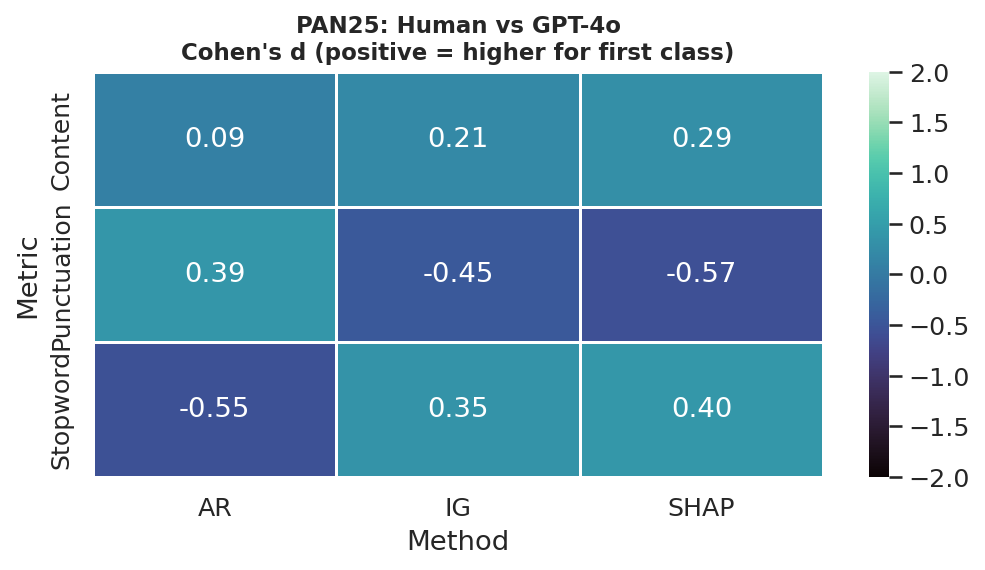


  PAN25: human vs gpt-4-turbo-paraphrase
  Lexical ratios are non-newline normalised.


,Method,Metric,Mean human,Mean gpt-4-turbo-paraphrase,Cohen's d,t p-value,U p-value
0,IG,Content,0.253,0.352,-0.606,2.08e-03,1.01e-03
1,IG,Punctuation,0.551,0.501,0.271,1.10e-01,1.03e-01
2,IG,Stopword,0.196,0.148,0.342,1.16e-02,5.84e-02
3,SHAP,Content,0.284,0.361,-0.418,1.51e-02,6.08e-03
4,SHAP,Punctuation,0.514,0.460,0.277,7.29e-02,1.07e-01
5,SHAP,Stopword,0.202,0.179,0.150,3.69e-01,2.93e-01
6,AR,Content,0.133,0.137,-0.040,8.47e-01,9.60e-01
7,AR,Punctuation,0.597,0.588,0.051,7.12e-01,9.63e-01
8,AR,Stopword,0.270,0.275,-0.035,8.30e-01,8.90e-01


Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/modernbert_effect_size_pan25_human_vs_gpt-4-turbo-paraphrase.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/modernbert_effect_size_pan25_human_vs_gpt-4-turbo-paraphrase.pdf


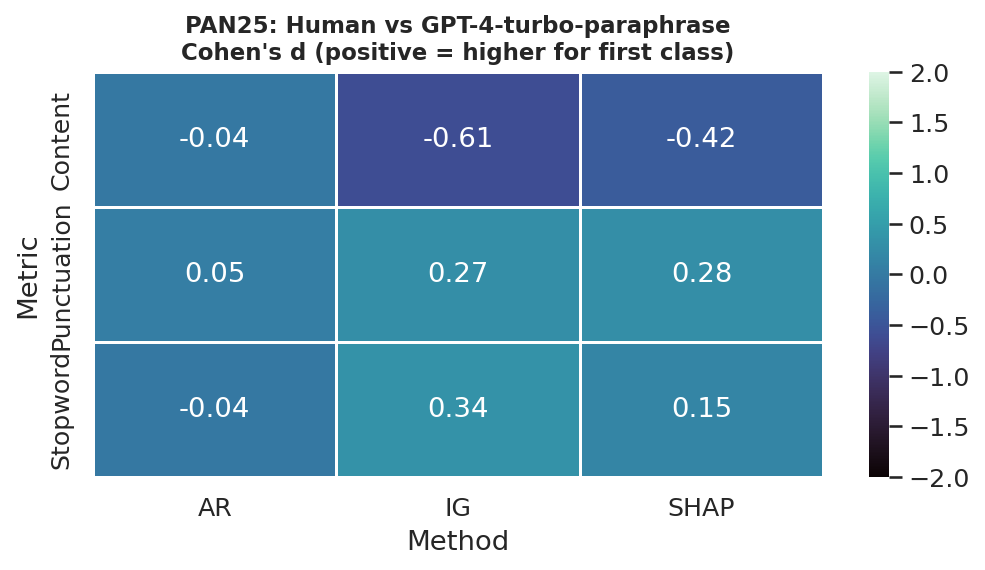


  AuthorMix: hemingway vs woolf
  Lexical ratios are non-newline normalised.


,Method,Metric,Mean hemingway,Mean woolf,Cohen's d,t p-value,U p-value
0,IG,Content,0.447,0.488,-0.298,3.51e-06,3.26e-05
1,IG,Punctuation,0.349,0.363,-0.123,5.45e-02,8.67e-02
2,IG,Stopword,0.204,0.148,0.470,3.02e-13,9.98e-13
3,SHAP,Content,0.436,0.476,-0.282,1.14e-05,2.15e-05
4,SHAP,Punctuation,0.351,0.369,-0.145,2.34e-02,4.12e-02
5,SHAP,Stopword,0.212,0.155,0.474,1.74e-13,6.05e-13
6,AR,Content,0.325,0.253,0.651,1.76e-23,1.92e-21
7,AR,Punctuation,0.390,0.516,-0.999,3.11e-49,1.73e-46
8,AR,Stopword,0.285,0.231,0.470,3.07e-13,9.94e-11


Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/modernbert_effect_size_authormix_hemingway_vs_woolf.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/modernbert_effect_size_authormix_hemingway_vs_woolf.pdf


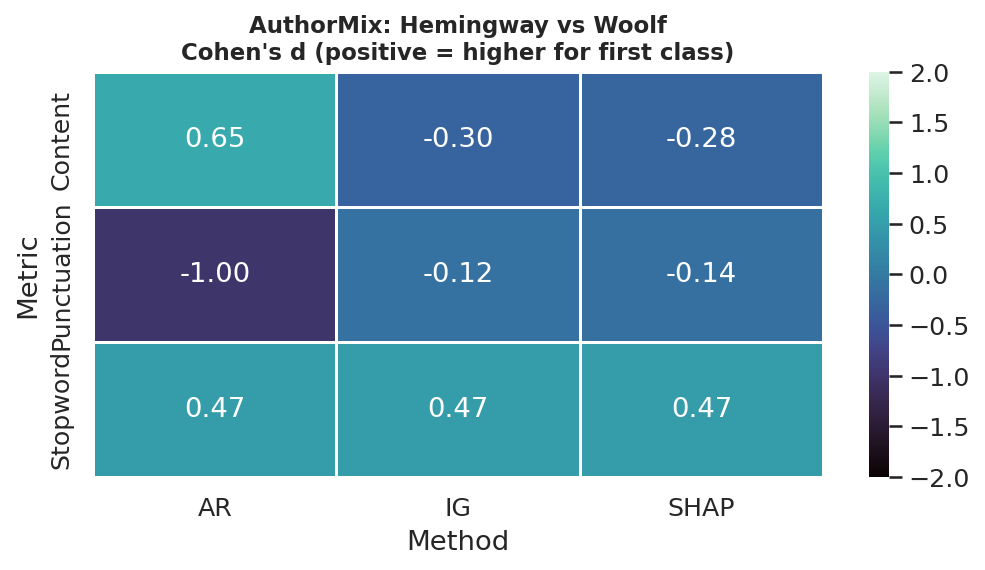


  AuthorMix: obama vs trump
  Lexical ratios are non-newline normalised.


,Method,Metric,Mean obama,Mean trump,Cohen's d,t p-value,U p-value
0,IG,Content,0.489,0.470,0.128,1.19e-01,3.39e-02
1,IG,Punctuation,0.332,0.342,-0.095,2.37e-01,2.69e-01
2,IG,Stopword,0.180,0.188,-0.065,4.24e-01,8.69e-01
3,SHAP,Content,0.476,0.470,0.043,6.02e-01,4.07e-01
4,SHAP,Punctuation,0.338,0.339,-0.006,9.39e-01,8.44e-01
5,SHAP,Stopword,0.186,0.191,-0.046,5.75e-01,9.40e-01
6,AR,Content,0.326,0.365,-0.344,3.31e-05,4.64e-05
7,AR,Punctuation,0.391,0.351,0.353,1.99e-05,1.62e-05
8,AR,Stopword,0.284,0.283,0.001,9.91e-01,9.90e-01


Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/modernbert_effect_size_authormix_obama_vs_trump.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/modernbert_effect_size_authormix_obama_vs_trump.pdf


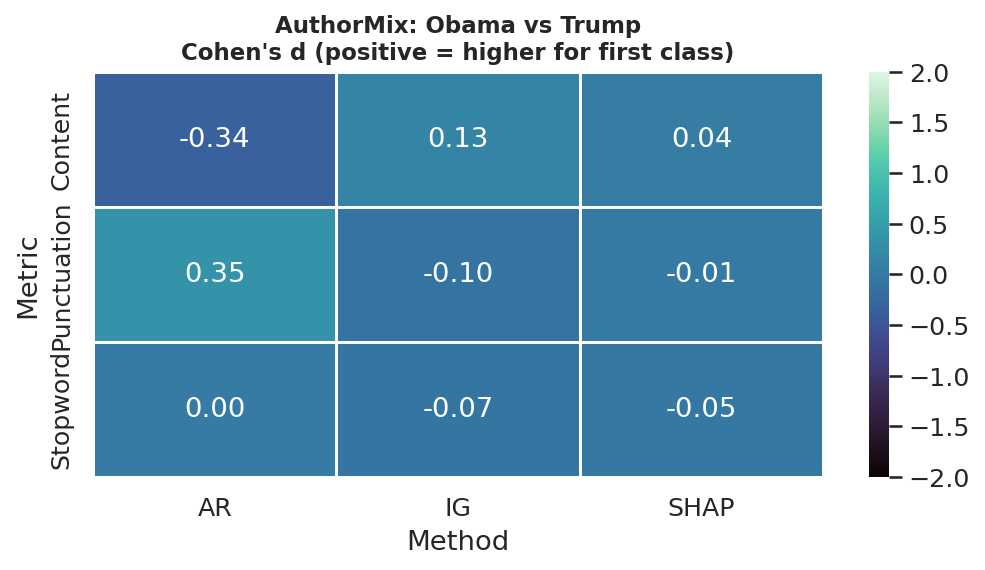

In [19]:
# PAN25: human vs gpt-4o
pan_stats = statistical_comparison(pan_ratios, "PAN25", "human", "gpt-4o")
effect_size_heatmap(pan_stats, "PAN25: Human vs GPT-4o")

# PAN25: human vs gpt-4-turbo (paraphrase model)
pan_stats2 = statistical_comparison(pan_ratios, "PAN25", "human", "gpt-4-turbo-paraphrase")
effect_size_heatmap(pan_stats2, "PAN25: Human vs GPT-4-turbo-paraphrase")

# AuthorMix: literary contrast
am_stats = statistical_comparison(am_ratios, "AuthorMix", "hemingway", "woolf")
effect_size_heatmap(am_stats, "AuthorMix: Hemingway vs Woolf")

# AuthorMix: political contrast
am_stats2 = statistical_comparison(am_ratios, "AuthorMix", "obama", "trump")
effect_size_heatmap(am_stats2, "AuthorMix: Obama vs Trump")

## 9. Content ratio analysis (full validation set)

**Content ratio** = proportion of the top-15 attributed tokens that are content words
(not punctuation, not stopwords). A high ratio means the classifier relies on
*semantic vocabulary* rather than *stylistic markers*.

In [20]:
def plot_full_ratios(ratios_df, dataset_name, method_prefix="ig", method_label="IG", save_dir=None):
    """Plot non-newline-normalised content ratio per class."""
    col   = f"{method_prefix}_content_nonnewline_ratio"
    means = ratios_df.groupby("class")[col].mean().sort_values()
    stds  = ratios_df.groupby("class")[col].std().reindex(means.index)
    colors = sns.color_palette("mako", as_cmap=True)(np.linspace(0.25, 0.9, len(means)))

    fig, ax = plt.subplots(figsize=(10, max(5, len(means) * 0.42)), dpi=150)
    ax.barh(means.index, means.values, xerr=stds.values,
            color=colors, edgecolor="white", capsize=3)
    ax.set_xlabel(f"Mean Content Ratio ({method_label}, non-newline normalised)")
    ax.set_title(
        f"{dataset_name} — Content Ratio per Class "
        f"({method_label}, non-newline normalised)",
        fontsize=12,
        fontweight="bold",
    )
    ax.set_xlim(0, 1)
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    save_plot(
        fig,
        f"{dataset_name}_modernbert_content_nonnewline_ratio_per_class_{method_label}",
        save_dir=save_dir,
    )
    plt.show()

def ratio_summary(ratios_df, dataset_name):
    """Show thesis-facing lexical ratios only: content, punctuation, stopword."""
    for prefix, label in METHODS:
        cols = [
            f"{prefix}_content_nonnewline_ratio",
            f"{prefix}_punct_nonnewline_ratio",
            f"{prefix}_stop_nonnewline_ratio",
        ]
        tbl = ratios_df.groupby("class")[cols].agg(["mean", "std"]).round(3)
        print(f"\n{dataset_name} — {label} non-newline-normalised lexical ratios:")
        display(tbl)


Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/pan25_modernbert_content_nonnewline_ratio_per_class_ig.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/pan25_modernbert_content_nonnewline_ratio_per_class_ig.pdf


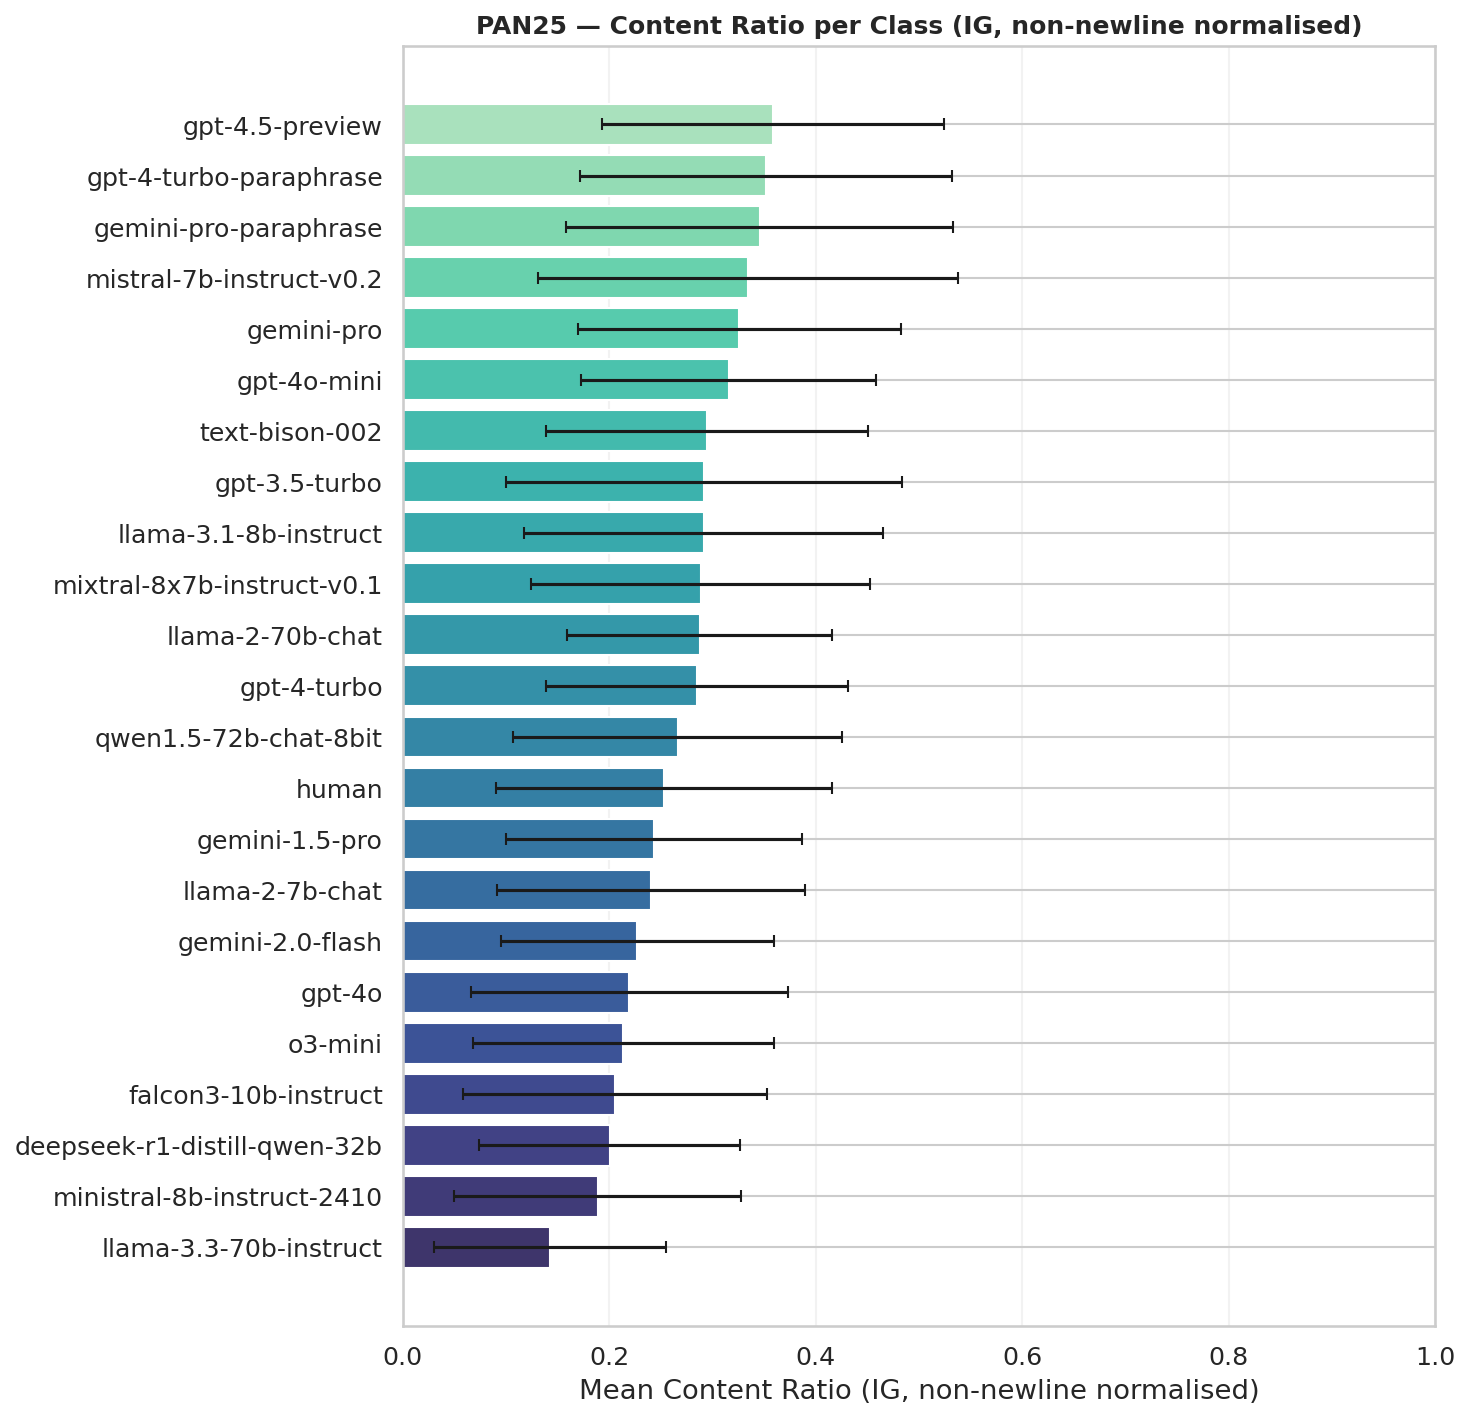

Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/pan25_modernbert_content_nonnewline_ratio_per_class_shap.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/pan25_modernbert_content_nonnewline_ratio_per_class_shap.pdf


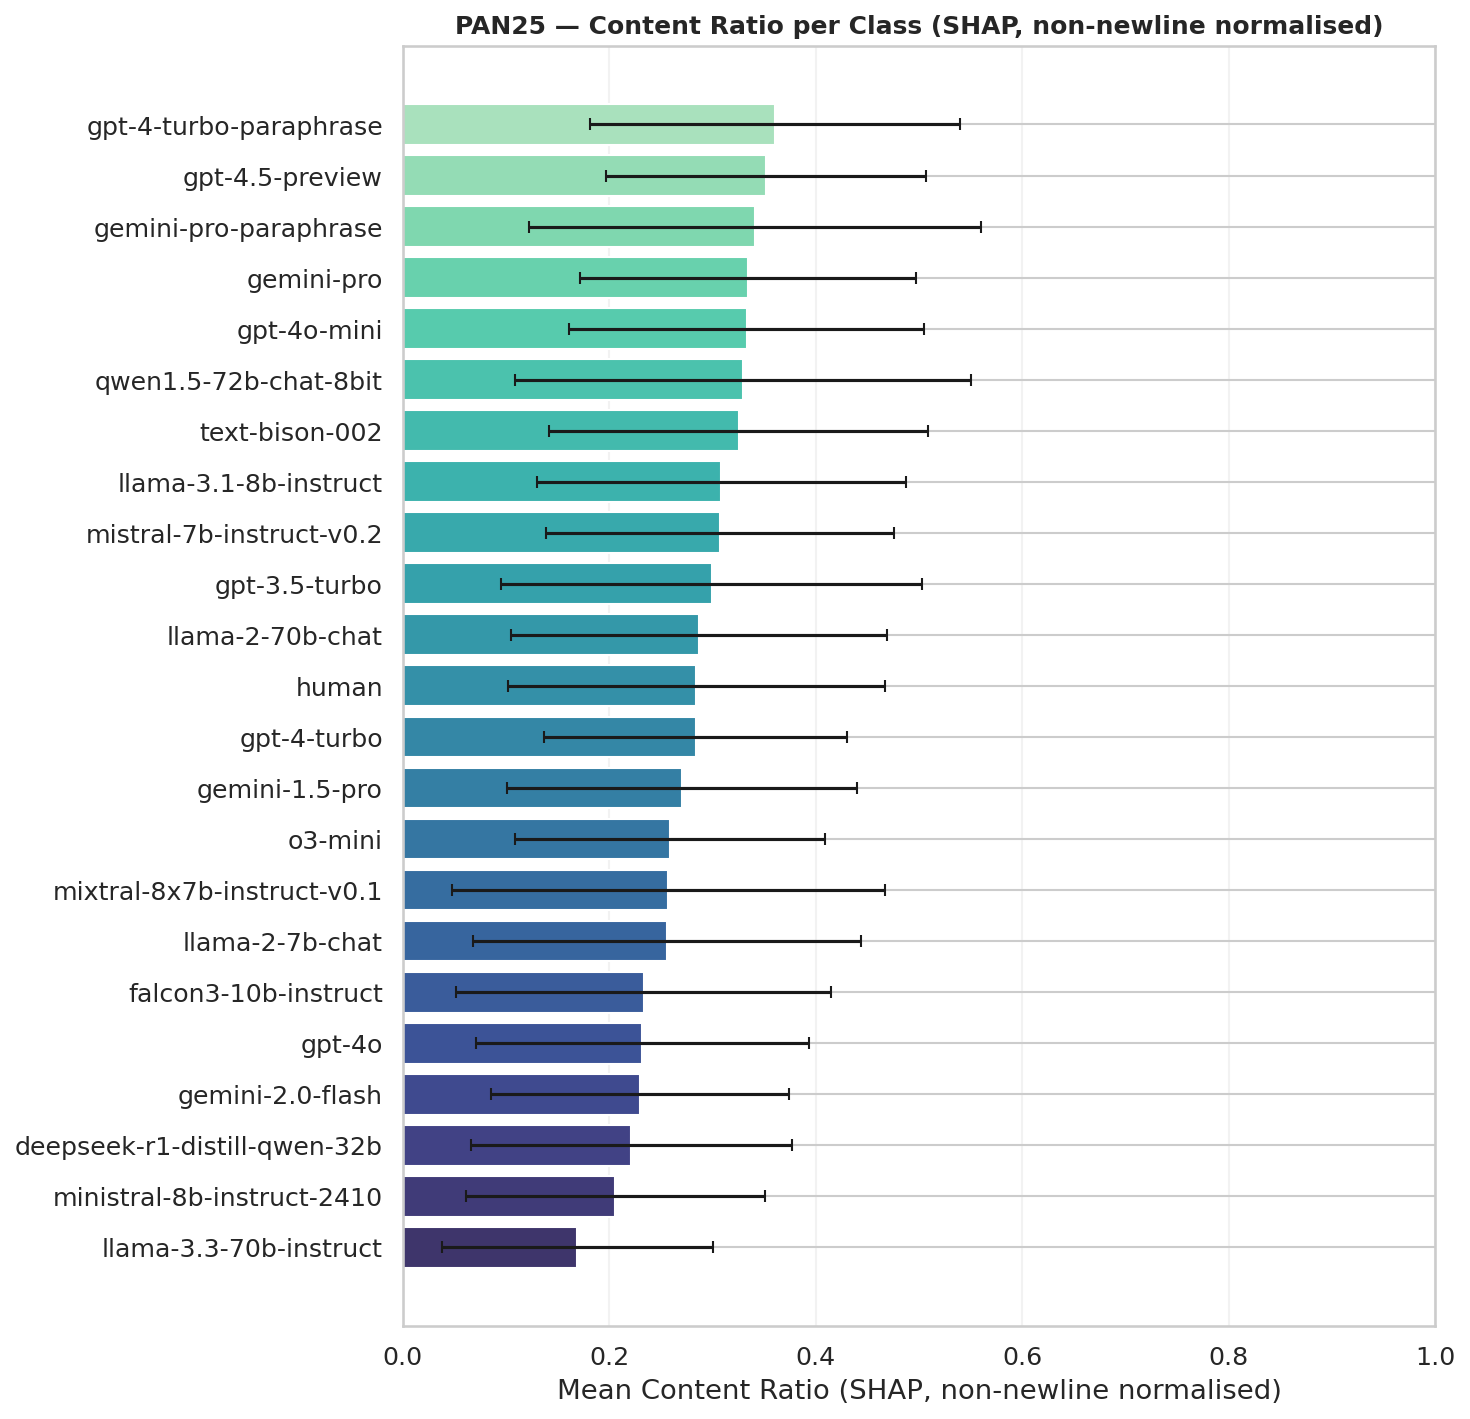

Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/pan25_modernbert_content_nonnewline_ratio_per_class_ar.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/pan25_modernbert_content_nonnewline_ratio_per_class_ar.pdf


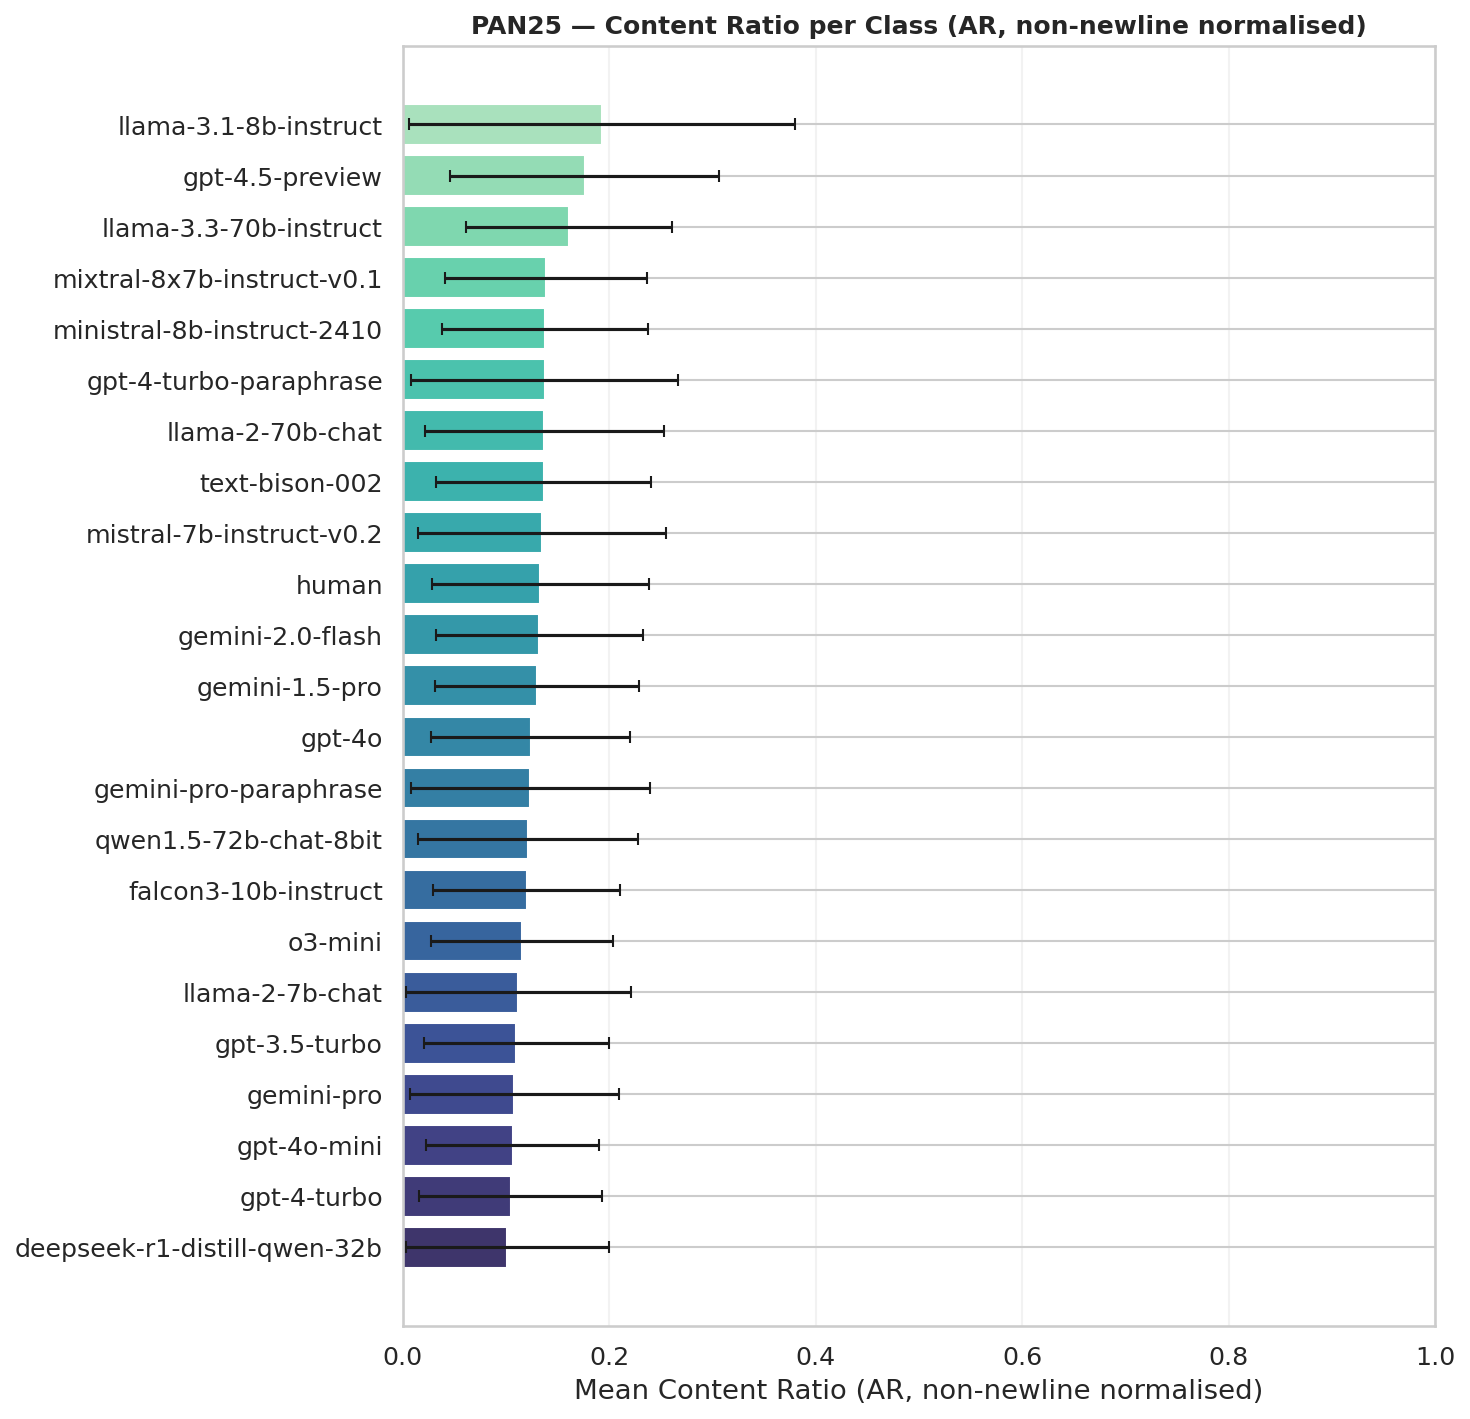


PAN25 — IG non-newline-normalised lexical ratios:


ig_content_nonnewline_ratio         \
                                                    mean    std   
class                                                             
deepseek-r1-distill-qwen-32b                       0.200  0.126   
falcon3-10b-instruct                               0.206  0.147   
gemini-1.5-pro                                     0.243  0.143   
gemini-2.0-flash                                   0.227  0.132   
gemini-pro                                         0.326  0.156   
gemini-pro-paraphrase                              0.346  0.187   
gpt-3.5-turbo                                      0.292  0.191   
gpt-4-turbo                                        0.285  0.147   
gpt-4-turbo-paraphrase                             0.352  0.180   
gpt-4.5-preview                                    0.358  0.166   
gpt-4o                                             0.219  0.153   
gpt-4o-mini                                        0.316  0.143   
human                                              0.253  0.163   
llama-2-70b-chat                                   0.288  0.128   
llama-2-7b-chat                                    0.240  0.149   
llama-3.1-8b-instruct                              0.291  0.174   
llama-3.3-70b-instruct                             0.143  0.112   
ministral-8b-instruct-2410                         0.189  0.139   
mistral-7b-instruct-v0.2                           0.334  0.203   
mixtral-8x7b-instruct-v0.1                         0.288  0.164   
o3-mini                                            0.214  0.145   
qwen1.5-72b-chat-8bit                              0.266  0.159   
text-bison-002                                     0.295  0.156   

                             ig_punct_nonnewline_ratio         \
                                                  mean    std   
class                                                           
deepseek-r1-distill-qwen-32b                     0.585  0.162   
falcon3-10b-instruct                             0.596  0.176   
gemini-1.5-pro                                   0.579  0.150   
gemini-2.0-flash                                 0.612  0.161   
gemini-pro                                       0.515  0.186   
gemini-pro-paraphrase                            0.529  0.184   
gpt-3.5-turbo                                    0.498  0.197   
gpt-4-turbo                                      0.554  0.177   
gpt-4-turbo-paraphrase                           0.501  0.185   
gpt-4.5-preview                                  0.499  0.148   
gpt-4o                                           0.634  0.183   
gpt-4o-mini                                      0.536  0.153   
human                                            0.551  0.186   
llama-2-70b-chat                                 0.541  0.164   
llama-2-7b-chat                                  0.567  0.140   
llama-3.1-8b-instruct                            0.521  0.165   
llama-3.3-70b-instruct                           0.633  0.123   
ministral-8b-instruct-2410                       0.633  0.173   
mistral-7b-instruct-v0.2                         0.511  0.189   
mixtral-8x7b-instruct-v0.1                       0.528  0.137   
o3-mini                                          0.625  0.172   
qwen1.5-72b-chat-8bit                            0.522  0.173   
text-bison-002                                   0.542  0.154   

                             ig_stop_nonnewline_ratio         
                                                 mean    std  
class                                                         
deepseek-r1-distill-qwen-32b                    0.215  0.137  
falcon3-10b-instruct                            0.198  0.142  
gemini-1.5-pro                                  0.178  0.128  
gemini-2.0-flash                                0.161  0.124  
gemini-pro                                      0.159  0.131  
gemini-pro-paraphrase                           0.125  0.143  
gpt-3.5-turbo               


PAN25 — SHAP non-newline-normalised lexical ratios:


gs_content_nonnewline_ratio         \
                                                    mean    std   
class                                                             
deepseek-r1-distill-qwen-32b                       0.221  0.155   
falcon3-10b-instruct                               0.233  0.182   
gemini-1.5-pro                                     0.270  0.170   
gemini-2.0-flash                                   0.229  0.144   
gemini-pro                                         0.334  0.162   
gemini-pro-paraphrase                              0.341  0.219   
gpt-3.5-turbo                                      0.299  0.204   
gpt-4-turbo                                        0.284  0.147   
gpt-4-turbo-paraphrase                             0.361  0.179   
gpt-4.5-preview                                    0.352  0.155   
gpt-4o                                             0.232  0.161   
gpt-4o-mini                                        0.333  0.172   
human                                              0.284  0.182   
llama-2-70b-chat                                   0.287  0.182   
llama-2-7b-chat                                    0.256  0.188   
llama-3.1-8b-instruct                              0.309  0.179   
llama-3.3-70b-instruct                             0.169  0.131   
ministral-8b-instruct-2410                         0.206  0.145   
mistral-7b-instruct-v0.2                           0.307  0.169   
mixtral-8x7b-instruct-v0.1                         0.257  0.210   
o3-mini                                            0.259  0.150   
qwen1.5-72b-chat-8bit                              0.329  0.221   
text-bison-002                                     0.325  0.184   

                             gs_punct_nonnewline_ratio         \
                                                  mean    std   
class                                                           
deepseek-r1-distill-qwen-32b                     0.588  0.178   
falcon3-10b-instruct                             0.596  0.199   
gemini-1.5-pro                                   0.554  0.184   
gemini-2.0-flash                                 0.599  0.180   
gemini-pro                                       0.540  0.164   
gemini-pro-paraphrase                            0.512  0.247   
gpt-3.5-turbo                                    0.467  0.189   
gpt-4-turbo                                      0.546  0.175   
gpt-4-turbo-paraphrase                           0.460  0.174   
gpt-4.5-preview                                  0.491  0.159   
gpt-4o                                           0.625  0.193   
gpt-4o-mini                                      0.509  0.165   
human                                            0.514  0.195   
llama-2-70b-chat                                 0.509  0.183   
llama-2-7b-chat                                  0.566  0.177   
llama-3.1-8b-instruct                            0.512  0.172   
llama-3.3-70b-instruct                           0.559  0.156   
ministral-8b-instruct-2410                       0.629  0.182   
mistral-7b-instruct-v0.2                         0.524  0.193   
mixtral-8x7b-instruct-v0.1                       0.537  0.239   
o3-mini                                          0.576  0.176   
qwen1.5-72b-chat-8bit                            0.483  0.222   
text-bison-002                                   0.474  0.198   

                             gs_stop_nonnewline_ratio         
                                                 mean    std  
class                                                         
deepseek-r1-distill-qwen-32b                    0.190  0.132  
falcon3-10b-instruct                            0.171  0.135  
gemini-1.5-pro                                  0.176  0.125  
gemini-2.0-flash                                0.172  0.129  
gemini-pro                                      0.126  0.113  
gemini-pro-paraphrase                           0.146  0.168  
gpt-3.5-turbo               


PAN25 — AR non-newline-normalised lexical ratios:


ar_content_nonnewline_ratio         \
                                                    mean    std   
class                                                             
deepseek-r1-distill-qwen-32b                       0.101  0.099   
falcon3-10b-instruct                               0.120  0.091   
gemini-1.5-pro                                     0.130  0.099   
gemini-2.0-flash                                   0.132  0.100   
gemini-pro                                         0.108  0.101   
gemini-pro-paraphrase                              0.123  0.116   
gpt-3.5-turbo                                      0.110  0.089   
gpt-4-turbo                                        0.104  0.089   
gpt-4-turbo-paraphrase                             0.137  0.129   
gpt-4.5-preview                                    0.176  0.130   
gpt-4o                                             0.124  0.096   
gpt-4o-mini                                        0.107  0.084   
human                                              0.133  0.105   
llama-2-70b-chat                                   0.137  0.116   
llama-2-7b-chat                                    0.112  0.109   
llama-3.1-8b-instruct                              0.193  0.187   
llama-3.3-70b-instruct                             0.161  0.099   
ministral-8b-instruct-2410                         0.138  0.100   
mistral-7b-instruct-v0.2                           0.135  0.120   
mixtral-8x7b-instruct-v0.1                         0.139  0.098   
o3-mini                                            0.115  0.088   
qwen1.5-72b-chat-8bit                              0.121  0.107   
text-bison-002                                     0.137  0.104   

                             ar_punct_nonnewline_ratio         \
                                                  mean    std   
class                                                           
deepseek-r1-distill-qwen-32b                     0.553  0.146   
falcon3-10b-instruct                             0.526  0.128   
gemini-1.5-pro                                   0.559  0.163   
gemini-2.0-flash                                 0.545  0.164   
gemini-pro                                       0.617  0.204   
gemini-pro-paraphrase                            0.604  0.183   
gpt-3.5-turbo                                    0.514  0.116   
gpt-4-turbo                                      0.499  0.113   
gpt-4-turbo-paraphrase                           0.588  0.148   
gpt-4.5-preview                                  0.535  0.143   
gpt-4o                                           0.529  0.129   
gpt-4o-mini                                      0.581  0.130   
human                                            0.597  0.182   
llama-2-70b-chat                                 0.549  0.155   
llama-2-7b-chat                                  0.607  0.152   
llama-3.1-8b-instruct                            0.485  0.162   
llama-3.3-70b-instruct                           0.416  0.105   
ministral-8b-instruct-2410                       0.513  0.137   
mistral-7b-instruct-v0.2                         0.555  0.141   
mixtral-8x7b-instruct-v0.1                       0.557  0.175   
o3-mini                                          0.580  0.125   
qwen1.5-72b-chat-8bit                            0.579  0.146   
text-bison-002                                   0.545  0.142   

                             ar_stop_nonnewline_ratio         
                                                 mean    std  
class                                                         
deepseek-r1-distill-qwen-32b                    0.346  0.133  
falcon3-10b-instruct                            0.353  0.135  
gemini-1.5-pro                                  0.311  0.147  
gemini-2.0-flash                                0.323  0.133  
gemini-pro                                      0.275  0.174  
gemini-pro-paraphrase                           0.273  0.188  
gpt-3.5-turbo               

Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/authormix_modernbert_content_nonnewline_ratio_per_class_ig.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/authormix_modernbert_content_nonnewline_ratio_per_class_ig.pdf


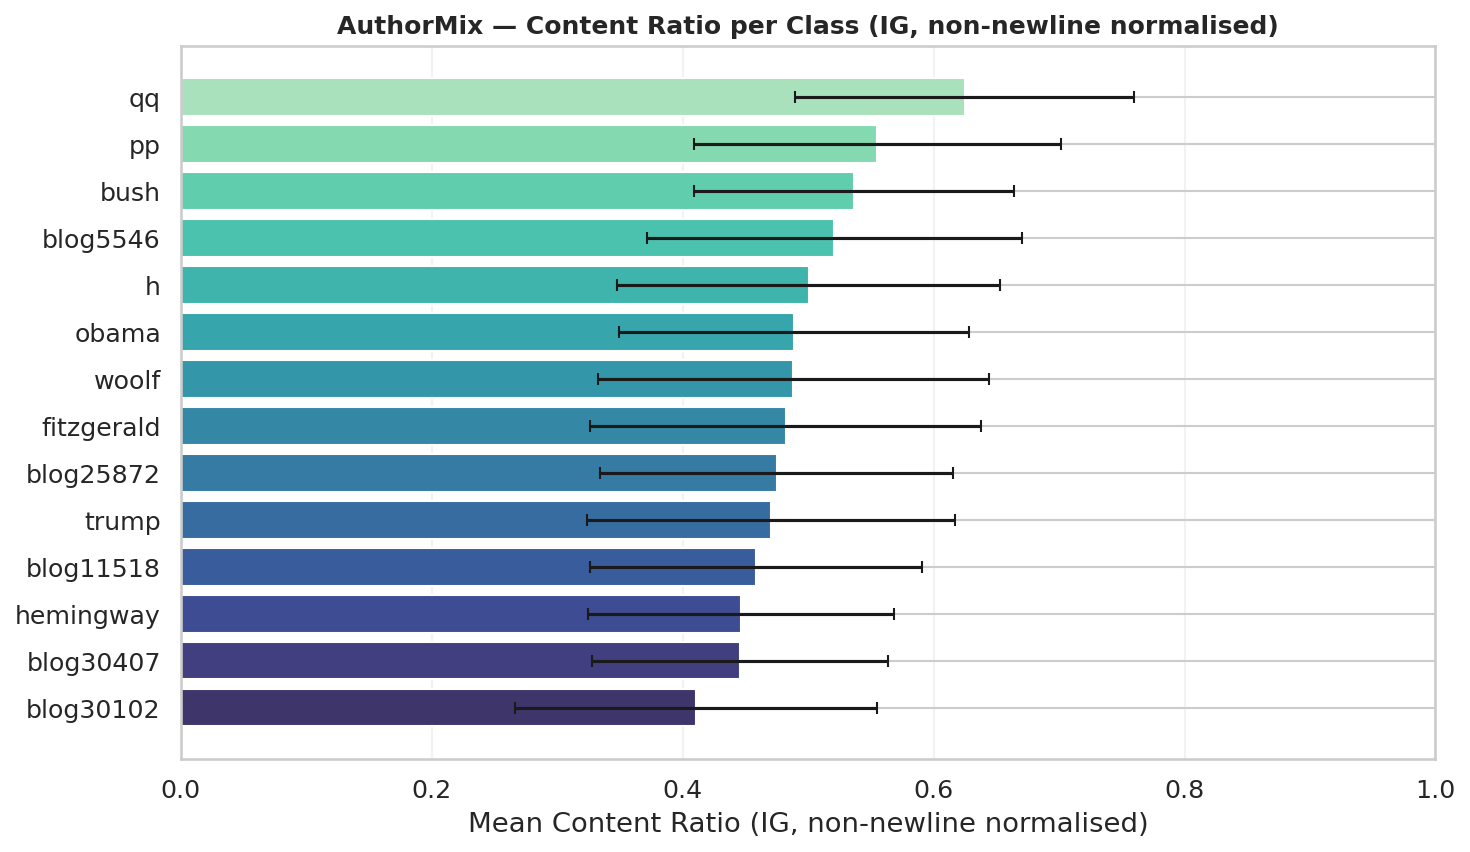

Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/authormix_modernbert_content_nonnewline_ratio_per_class_shap.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/authormix_modernbert_content_nonnewline_ratio_per_class_shap.pdf


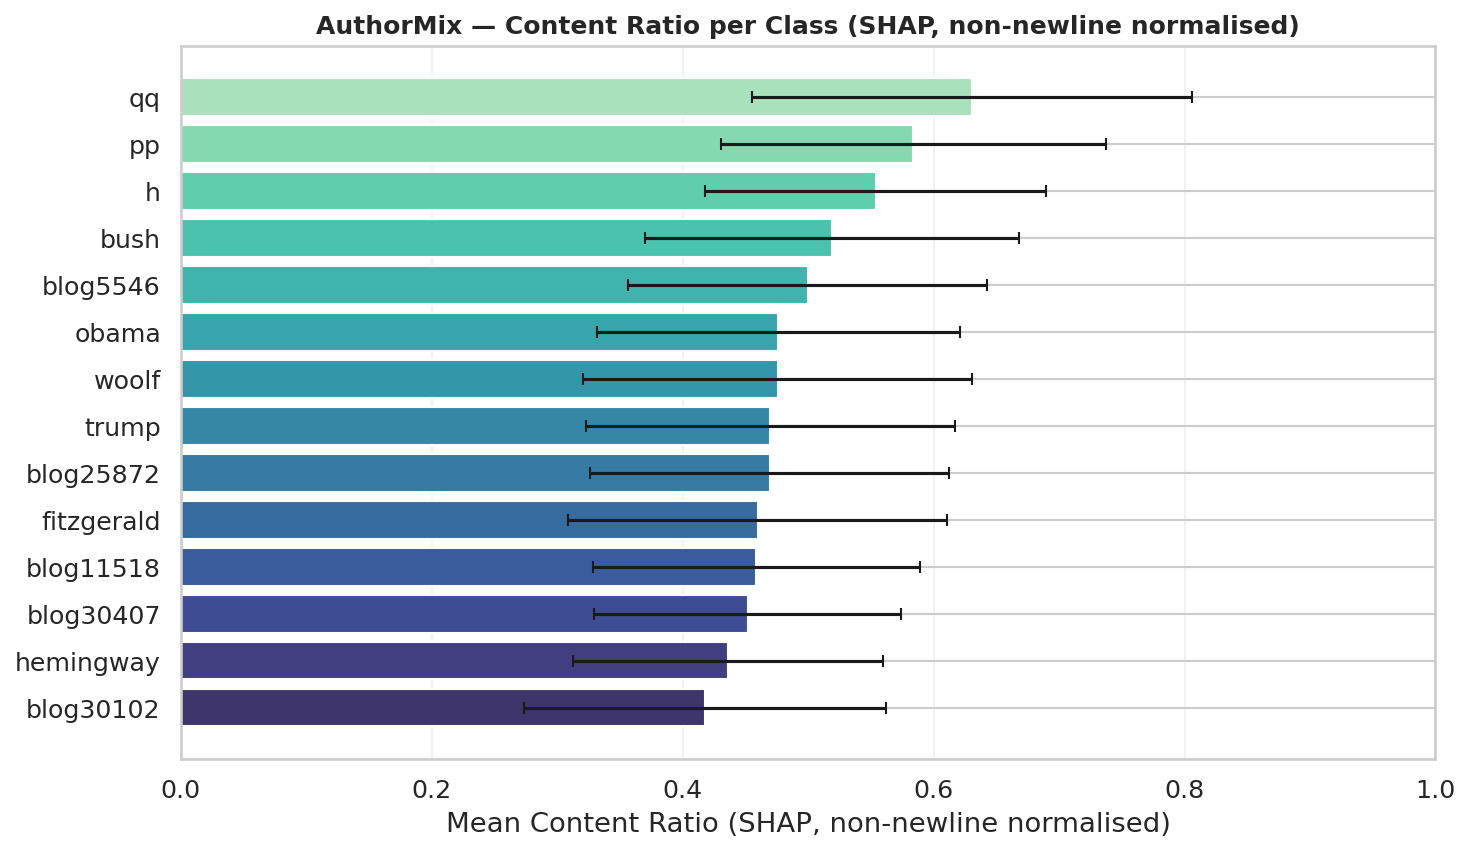

Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/authormix_modernbert_content_nonnewline_ratio_per_class_ar.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/authormix_modernbert_content_nonnewline_ratio_per_class_ar.pdf


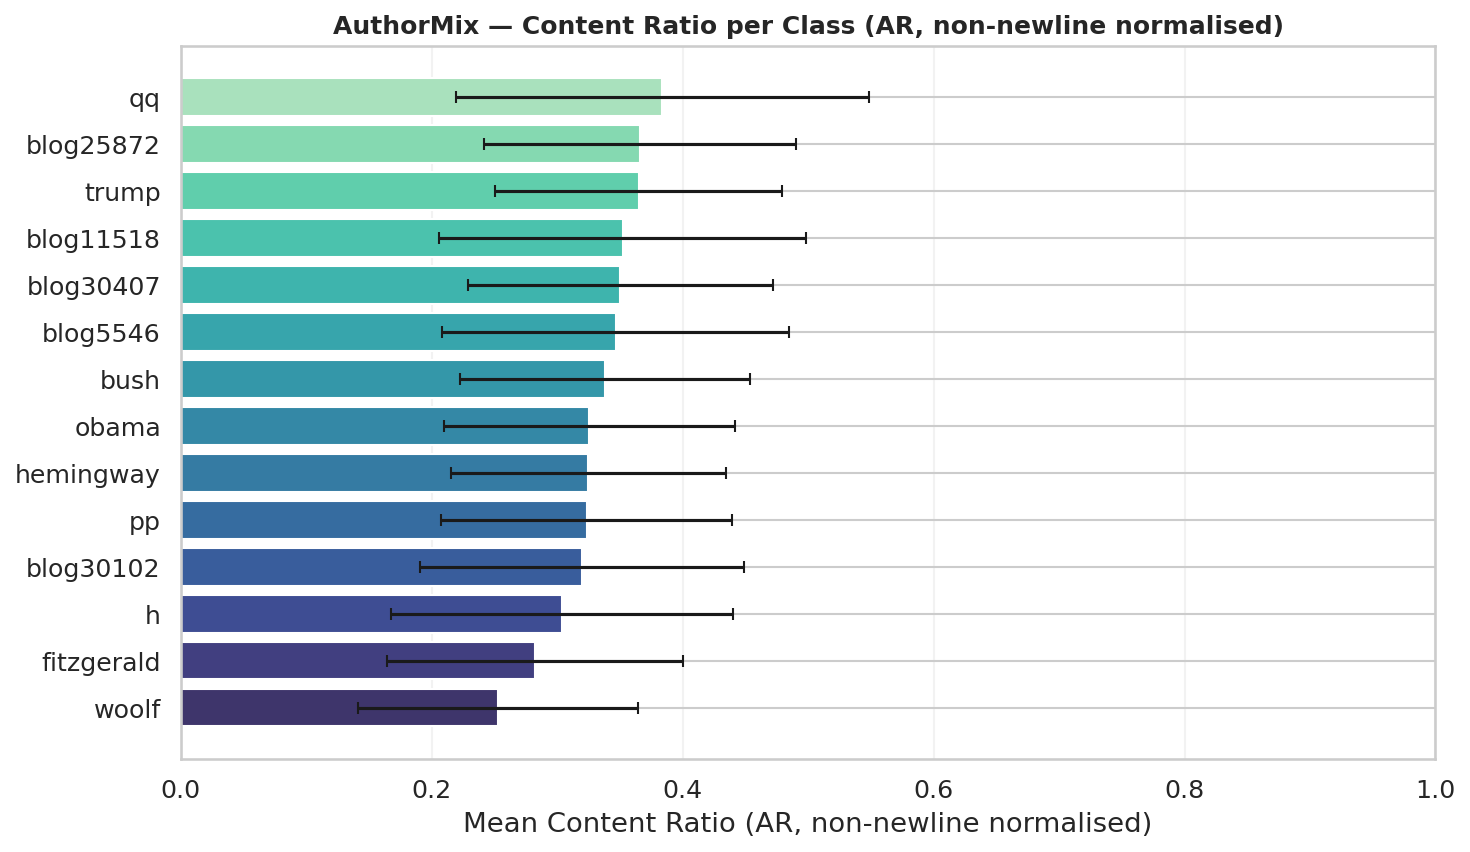


AuthorMix — IG non-newline-normalised lexical ratios:


ig_content_nonnewline_ratio        ig_punct_nonnewline_ratio  \
                                  mean    std                      mean   
class                                                                     
blog11518                        0.458  0.132                     0.347   
blog25872                        0.475  0.141                     0.346   
blog30102                        0.411  0.144                     0.368   
blog30407                        0.446  0.118                     0.301   
blog5546                         0.521  0.150                     0.320   
bush                             0.537  0.128                     0.295   
fitzgerald                       0.482  0.156                     0.336   
h                                0.501  0.152                     0.294   
hemingway                        0.447  0.122                     0.349   
obama                            0.489  0.139                     0.332   
pp                               0.555  0.146                     0.318   
qq                               0.625  0.135                     0.222   
trump                            0.470  0.147                     0.342   
woolf                            0.488  0.156                     0.363   

                  ig_stop_nonnewline_ratio         
              std                     mean    std  
class                                              
blog11518   0.140                    0.194  0.118  
blog25872   0.157                    0.179  0.125  
blog30102   0.136                    0.221  0.138  
blog30407   0.110                    0.253  0.110  
blog5546    0.119                    0.159  0.112  
bush        0.086                    0.168  0.106  
fitzgerald  0.132                    0.182  0.116  
h           0.114                    0.206  0.151  
hemingway   0.102                    0.204  0.123  
obama       0.097                    0.180  0.112  
pp          0.097                    0.127  0.112  
qq          0.042                    0.153  0.108  
trump       0.117                    0.188  0.132  
woolf       0.132                    0.148  0.116


AuthorMix — SHAP non-newline-normalised lexical ratios:


gs_content_nonnewline_ratio        gs_punct_nonnewline_ratio  \
                                  mean    std                      mean   
class                                                                     
blog11518                        0.459  0.131                     0.347   
blog25872                        0.469  0.143                     0.356   
blog30102                        0.418  0.144                     0.366   
blog30407                        0.452  0.122                     0.293   
blog5546                         0.500  0.143                     0.333   
bush                             0.519  0.149                     0.305   
fitzgerald                       0.460  0.151                     0.340   
h                                0.554  0.136                     0.291   
hemingway                        0.436  0.124                     0.351   
obama                            0.476  0.145                     0.338   
pp                               0.584  0.153                     0.315   
qq                               0.631  0.175                     0.247   
trump                            0.470  0.147                     0.339   
woolf                            0.476  0.155                     0.369   

                  gs_stop_nonnewline_ratio         
              std                     mean    std  
class                                              
blog11518   0.143                    0.195  0.115  
blog25872   0.154                    0.175  0.107  
blog30102   0.146                    0.216  0.135  
blog30407   0.101                    0.255  0.113  
blog5546    0.127                    0.167  0.113  
bush        0.117                    0.176  0.103  
fitzgerald  0.129                    0.200  0.118  
h           0.077                    0.155  0.099  
hemingway   0.107                    0.212  0.125  
obama       0.109                    0.186  0.113  
pp          0.107                    0.101  0.071  
qq          0.086                    0.123  0.139  
trump       0.123                    0.191  0.128  
woolf       0.134                    0.155  0.115


AuthorMix — AR non-newline-normalised lexical ratios:


ar_content_nonnewline_ratio        ar_punct_nonnewline_ratio  \
                                  mean    std                      mean   
class                                                                     
blog11518                        0.352  0.146                     0.393   
blog25872                        0.366  0.124                     0.398   
blog30102                        0.320  0.129                     0.382   
blog30407                        0.350  0.122                     0.320   
blog5546                         0.347  0.138                     0.410   
bush                             0.338  0.115                     0.370   
fitzgerald                       0.282  0.118                     0.436   
h                                0.304  0.137                     0.399   
hemingway                        0.325  0.110                     0.390   
obama                            0.326  0.116                     0.391   
pp                               0.323  0.116                     0.402   
qq                               0.384  0.165                     0.302   
trump                            0.365  0.114                     0.351   
woolf                            0.253  0.111                     0.516   

                  ar_stop_nonnewline_ratio         
              std                     mean    std  
class                                              
blog11518   0.169                    0.255  0.118  
blog25872   0.183                    0.236  0.108  
blog30102   0.150                    0.298  0.121  
blog30407   0.122                    0.329  0.101  
blog5546    0.146                    0.243  0.118  
bush        0.111                    0.292  0.095  
fitzgerald  0.140                    0.281  0.120  
h           0.133                    0.297  0.105  
hemingway   0.111                    0.285  0.115  
obama       0.112                    0.284  0.105  
pp          0.081                    0.275  0.094  
qq          0.089                    0.314  0.128  
trump       0.112                    0.283  0.115  
woolf       0.139                    0.231  0.113

In [21]:
for prefix, label in [("ig","IG"),("gs","SHAP"),("ar","AR")]:
    plot_full_ratios(pan_ratios, "PAN25", prefix, label)

ratio_summary(pan_ratios, "PAN25")

for prefix, label in [("ig","IG"),("gs","SHAP"),("ar","AR")]:
    plot_full_ratios(am_ratios, "AuthorMix", prefix, label)

ratio_summary(am_ratios, "AuthorMix")

/tmp/ipykernel_4235/1023838513.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)


Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/pan25_modernbert_content_nonnewline_ratio_by_class_and_method.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/pan25_modernbert_content_nonnewline_ratio_by_class_and_method.pdf


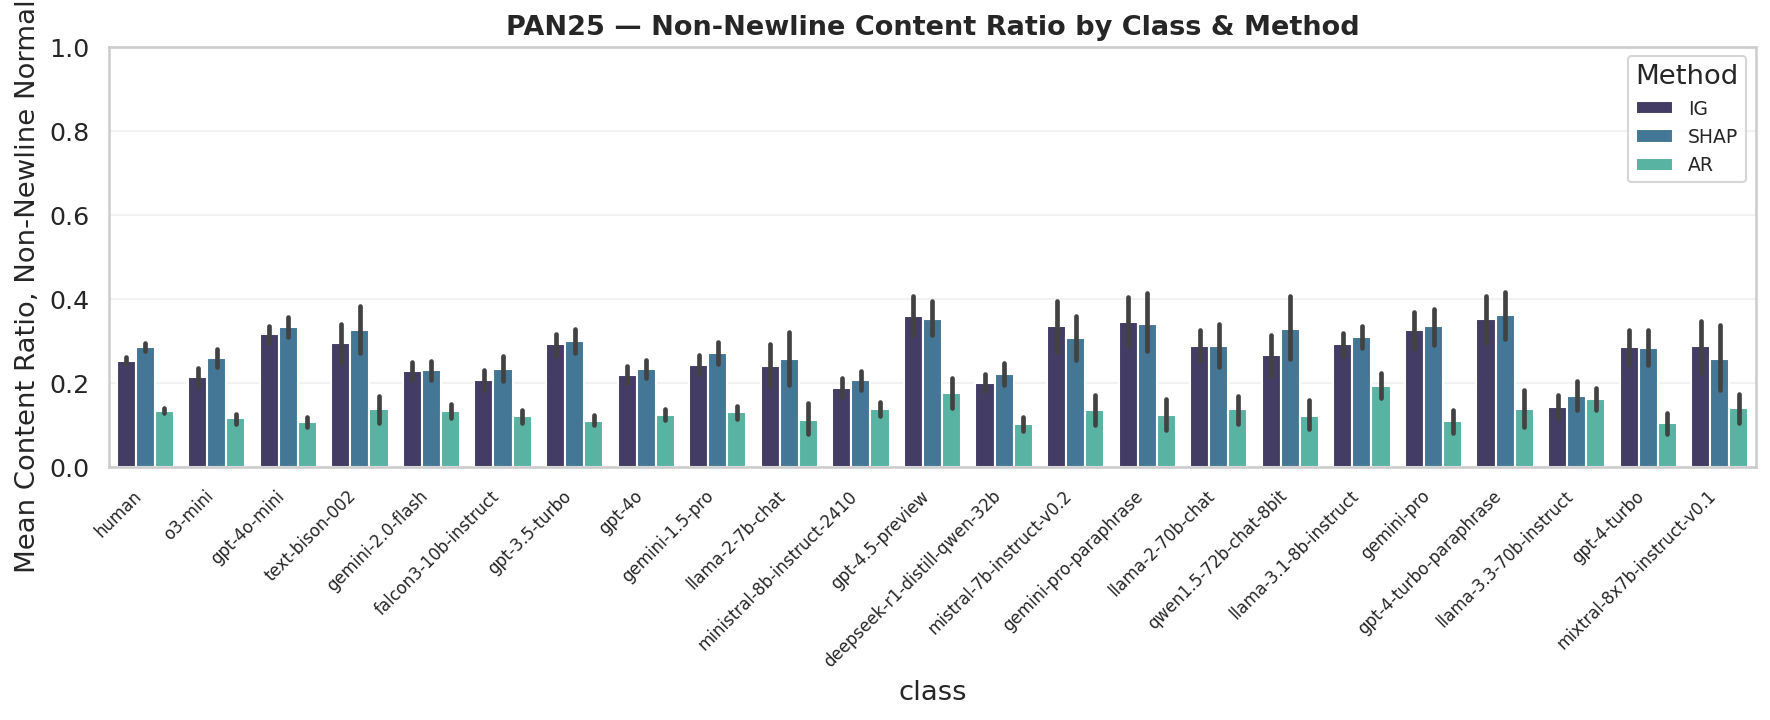

/tmp/ipykernel_4235/1023838513.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)


Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/authormix_modernbert_content_nonnewline_ratio_by_class_and_method.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/authormix_modernbert_content_nonnewline_ratio_by_class_and_method.pdf


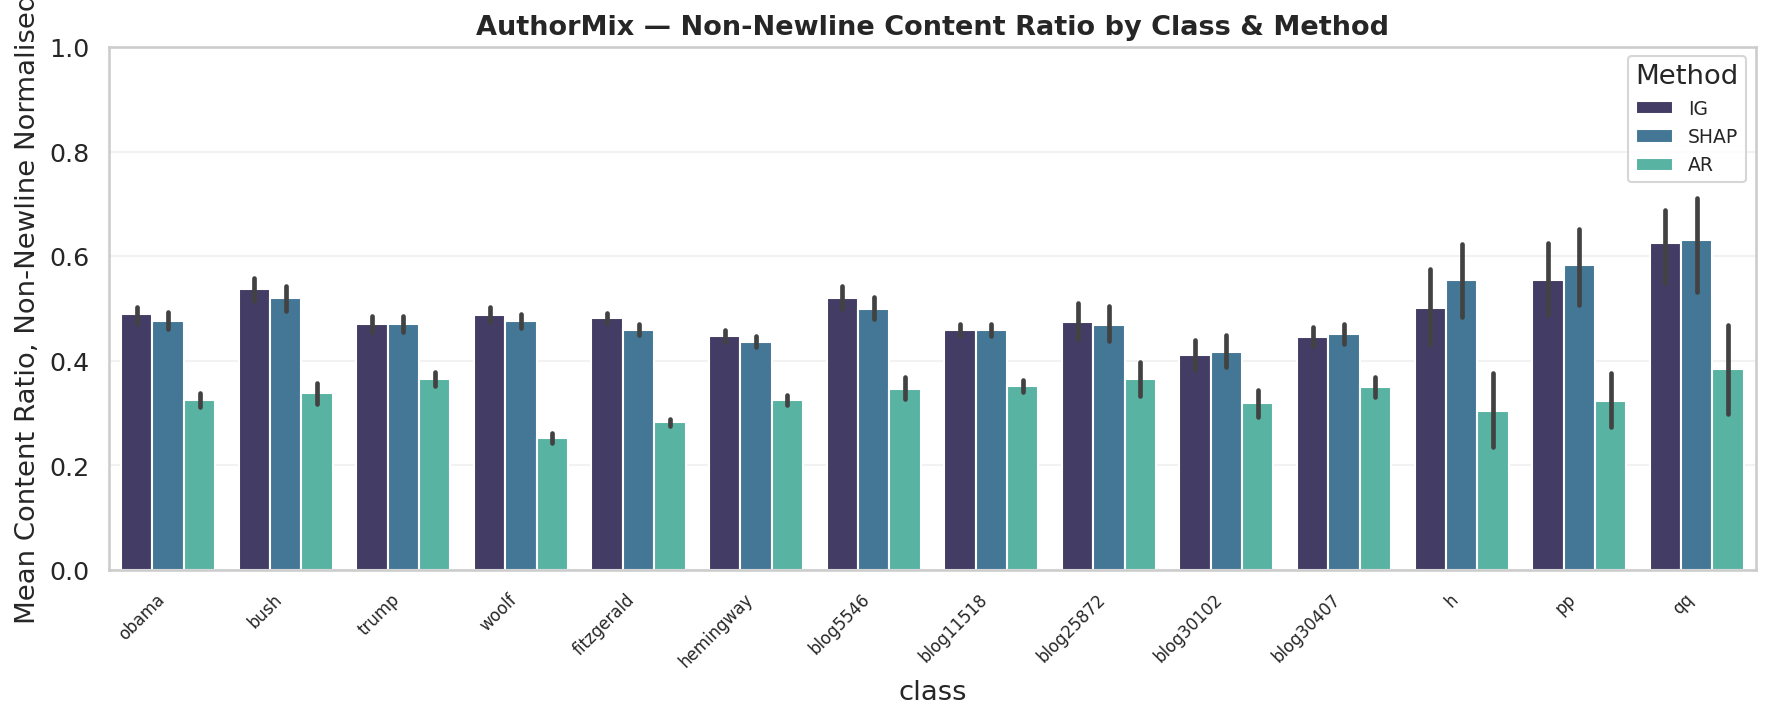

In [22]:
# Combined 3-method content ratio bar chart per dataset
def plot_all_methods_ratios(ratios_df, dataset_name, save_dir=None):
    """Plot non-newline-normalised content ratio for IG, SHAP, and AR."""
    rows = []

    for prefix, label in METHODS:
        sub = ratios_df[["class", f"{prefix}_content_nonnewline_ratio"]].copy()
        sub.columns = ["class", "content_ratio"]
        sub["method"] = label
        rows.append(sub)

    combined = pd.concat(rows, ignore_index=True)

    fig, ax = plt.subplots(figsize=(12, 5), dpi=150)
    method_palette = {
        label: color
        for label, color in zip(["IG", "SHAP", "AR"], mako_palette(3))
    }

    sns.barplot(
        data=combined,
        x="class",
        y="content_ratio",
        hue="method",
        ax=ax,
        palette=method_palette,
        edgecolor="white",
    )

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Mean Content Ratio, Non-Newline Normalised")
    ax.set_ylim(0, 1)
    ax.set_title(
        f"{dataset_name} — Non-Newline Content Ratio by Class & Method",
        fontsize=13,
        fontweight="bold",
    )
    ax.legend(title="Method", fontsize=9)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    save_plot(
        fig,
        f"{dataset_name}_modernbert_content_nonnewline_ratio_by_class_and_method",
        save_dir=save_dir,
    )
    plt.show()

plot_all_methods_ratios(pan_ratios, "PAN25")
plot_all_methods_ratios(am_ratios,  "AuthorMix")


## 10. ModernBERT vs BERT: content ratio shift

**Key finding:** ModernBERT dramatically increases the reliance on content words
compared to BERT.

| Model | PAN25 IG content ratio | AuthorMix IG content ratio |
|-------|------------------------|----------------------------|
| BERT  | 0.18 - 0.38            | ~0.35 - 0.55               |
| ModernBERT | **0.50 - 0.78**   | **0.58 - 0.70**            |

This shift suggests ModernBERT's deeper contextual representations allow it to
identify author-specific vocabulary rather than relying on surface-level punctuation
and function-word patterns.

BERT results found — side-by-side comparison enabled.

PAN25 — Non-newline content ratio (IG):
Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/pan25_bert_vs_modernbert_content_nonnewline_ratio_shift_ig.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/pan25_bert_vs_modernbert_content_nonnewline_ratio_shift_ig.pdf


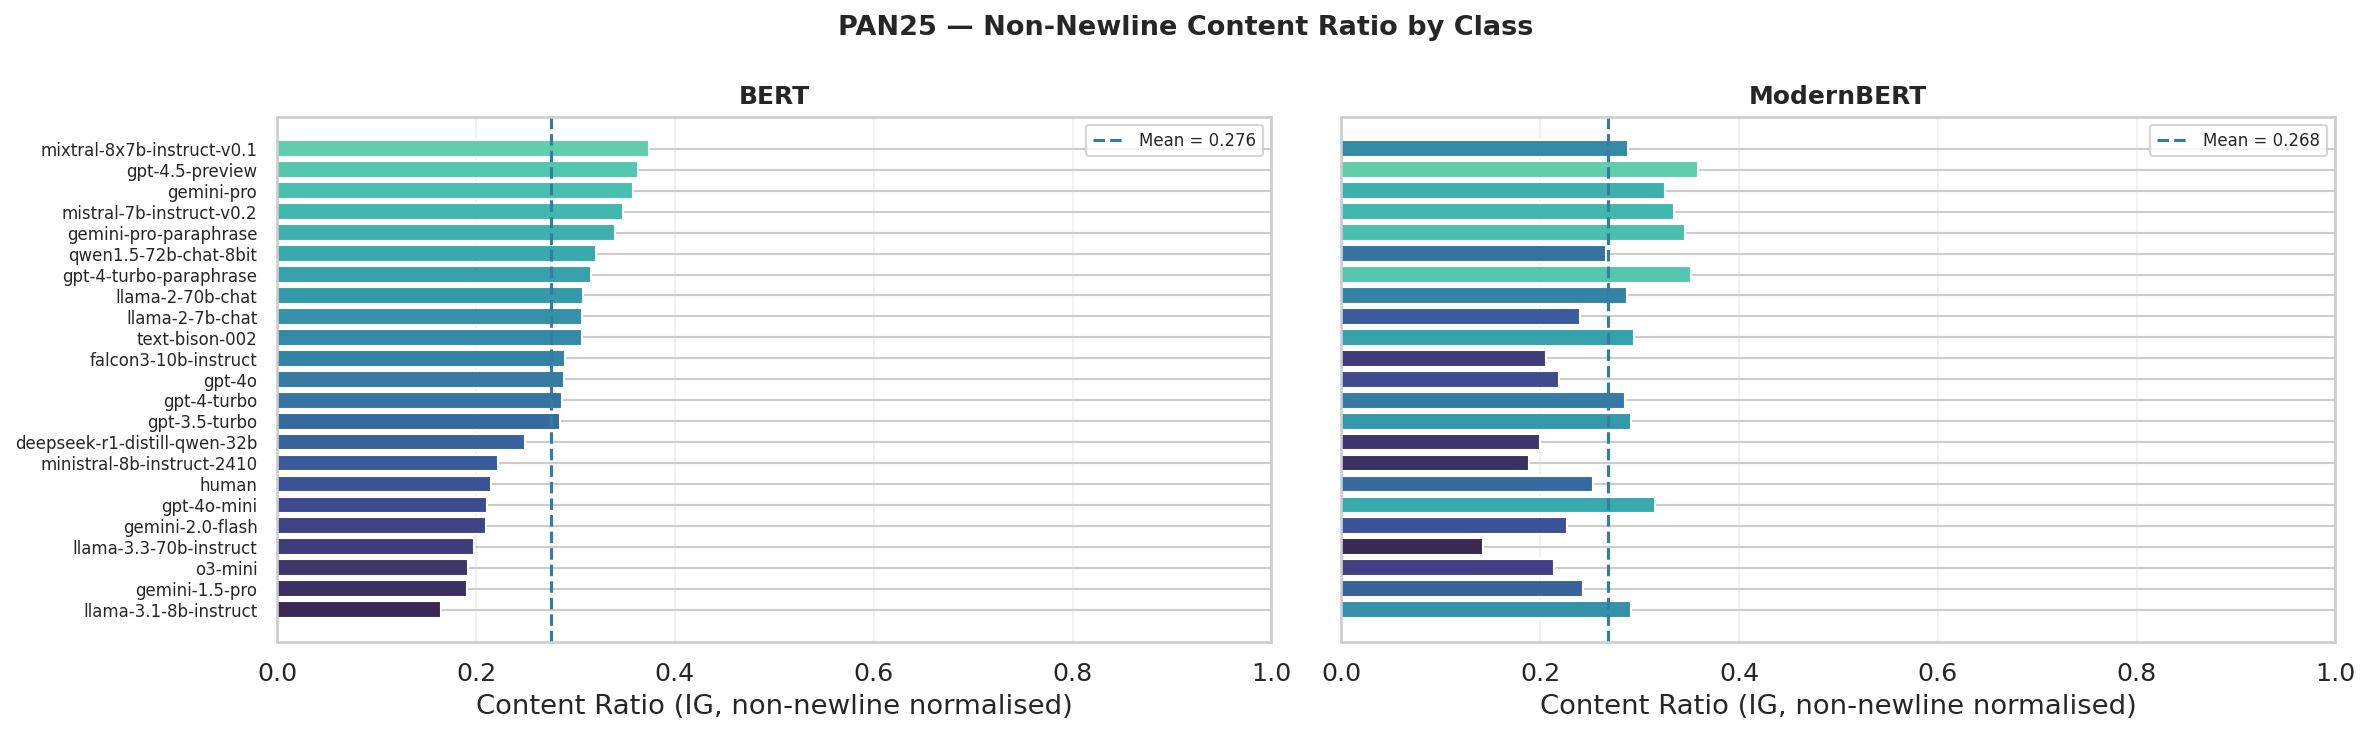


AuthorMix — Non-newline content ratio (IG):
Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/authormix_bert_vs_modernbert_content_nonnewline_ratio_shift_ig.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/authormix_bert_vs_modernbert_content_nonnewline_ratio_shift_ig.pdf


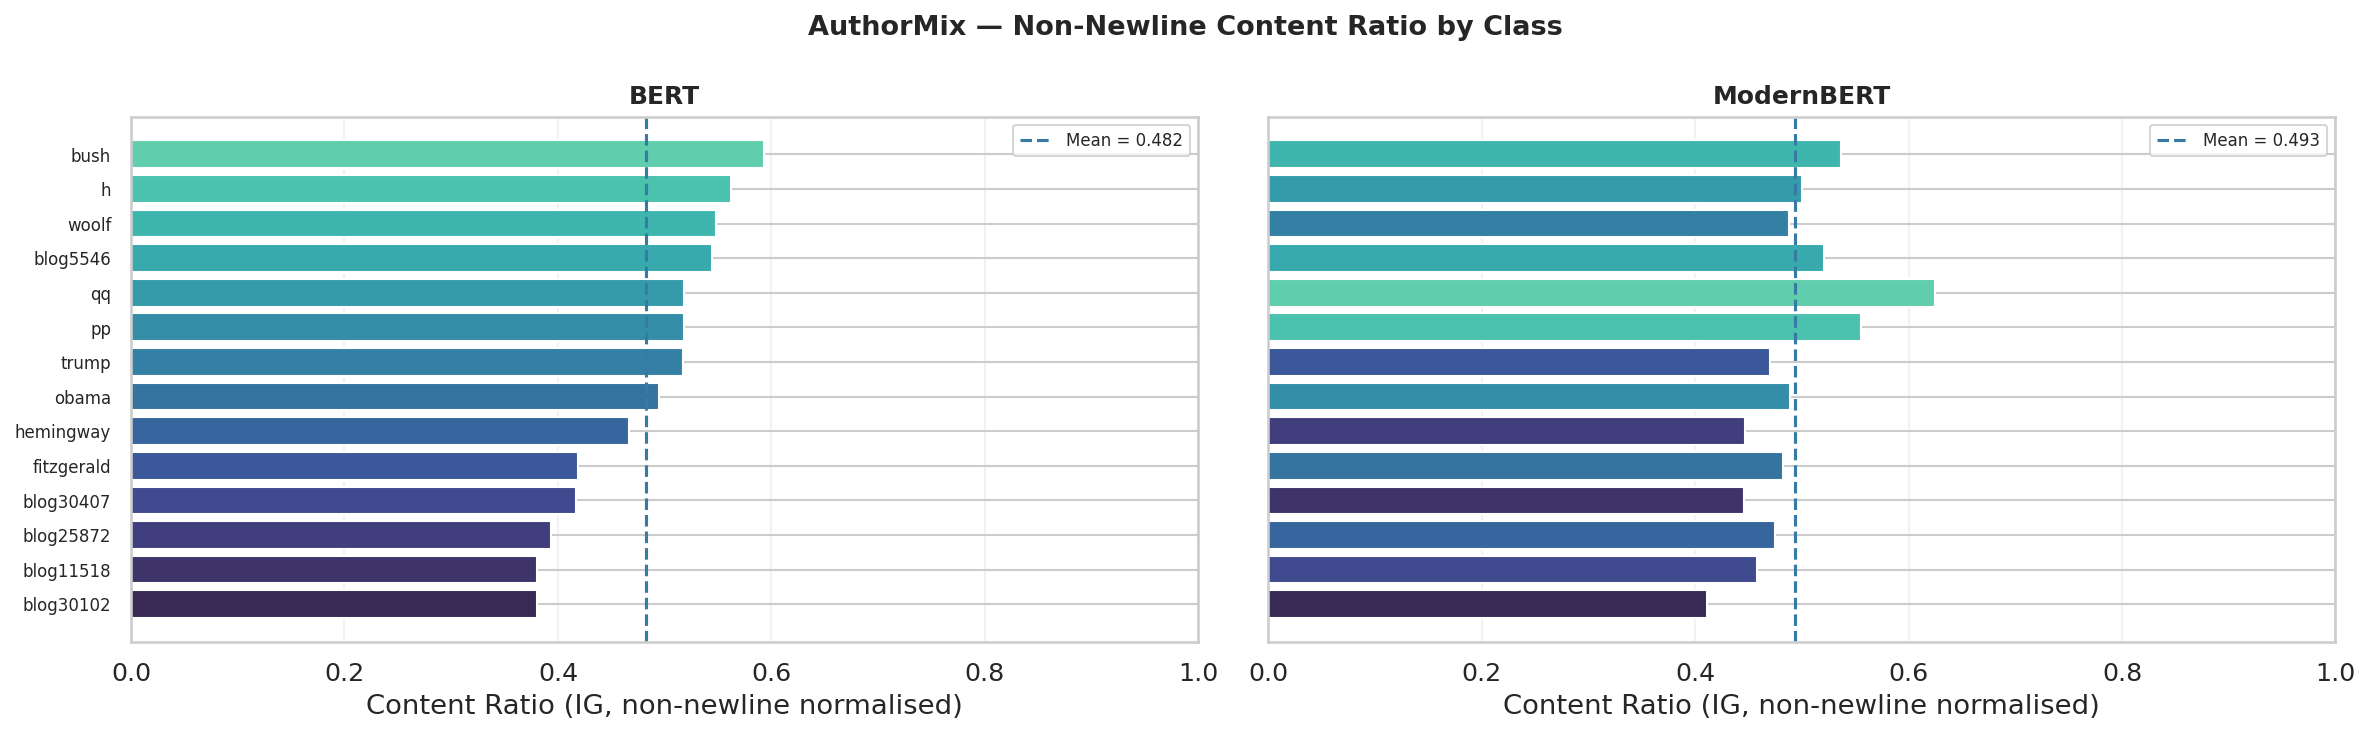

In [23]:
# Load BERT comparison data (if available)
bert_pan_path = f"{RESULTS}/pan25_full_validation_all_methods_ratios.csv"
bert_am_path  = f"{RESULTS}/authormix_full_validation_all_methods_ratios.csv"

has_bert = os.path.exists(bert_pan_path) and os.path.exists(bert_am_path)

if has_bert:
    bert_pan = pd.read_csv(bert_pan_path)
    bert_am  = pd.read_csv(bert_am_path)

    # Add the same non-newline-normalised columns to BERT.
    # For BERT these are usually equal to the raw ratios, but this keeps
    # the comparison definition identical across models.
    bert_pan = add_nonnewline_ratios(bert_pan)
    bert_am = add_nonnewline_ratios(bert_am)

    bert_pan["model"] = "BERT"
    bert_am["model"] = "BERT"

    pan_ratios_cmp = pan_ratios.copy()
    pan_ratios_cmp["model"] = "ModernBERT"

    am_ratios_cmp = am_ratios.copy()
    am_ratios_cmp["model"] = "ModernBERT"

    print("BERT results found — side-by-side comparison enabled.")
else:
    print("BERT results not available — using ModernBERT summary only.")

def plot_content_ratio_shift(ratios_dict, dataset_name, method_prefix="ig", save_dir=None):
    """Compare non-newline-normalised content ratio distributions across models."""
    col = f"{method_prefix}_content_nonnewline_ratio"

    fig, axes = plt.subplots(
        1,
        len(ratios_dict),
        figsize=(8 * len(ratios_dict), 5),
        sharey=True,
        dpi=150,
    )

    if len(ratios_dict) == 1:
        axes = [axes]

    for ax, (model_name, df) in zip(axes, ratios_dict.items()):
        if col not in df.columns:
            ax.set_visible(False)
            continue

        means = df.groupby("class")[col].mean().sort_values()
        colors = sns.color_palette("mako", as_cmap=True)(np.linspace(0.2, 0.8, len(means)))

        ax.barh(means.index, means.values, color=colors, edgecolor="white")
        ax.tick_params(axis="y", labelsize=8)
        mean_color = mako_palette(1, reverse=True)[0]
        ax.axvline(
            means.mean(),
            color=mean_color,
            ls="--",
            lw=1.5,
            label=f"Mean = {means.mean():.3f}",
        )

        ax.set_xlabel("Content Ratio (IG, non-newline normalised)")
        ax.set_title(model_name, fontsize=12, fontweight="bold")
        ax.legend(fontsize=8)
        ax.set_xlim(0, 1)
        ax.grid(axis="x", alpha=0.25)

    fig.suptitle(
        f"{dataset_name} — Non-Newline Content Ratio by Class",
        fontsize=13,
        fontweight="bold",
    )

    plt.tight_layout()
    model_part = "_vs_".join(ratios_dict.keys())
    save_plot(
        fig,
        f"{dataset_name}_{model_part}_content_nonnewline_ratio_shift_{method_prefix}",
        save_dir=save_dir,
    )
    plt.show()

if has_bert:
    print("\nPAN25 — Non-newline content ratio (IG):")
    plot_content_ratio_shift({"BERT": bert_pan, "ModernBERT": pan_ratios_cmp}, "PAN25")

    print("\nAuthorMix — Non-newline content ratio (IG):")
    plot_content_ratio_shift({"BERT": bert_am, "ModernBERT": am_ratios_cmp}, "AuthorMix")
else:
    plot_content_ratio_shift({"ModernBERT": pan_ratios}, "PAN25")
    plot_content_ratio_shift({"ModernBERT": am_ratios},  "AuthorMix")


Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/modernbert_nonnewline_ratio_distribution_pan25_ig_non-newline_content_ratio_distribution_bert_vs_modernbert.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/modernbert_nonnewline_ratio_distribution_pan25_ig_non-newline_content_ratio_distribution_bert_vs_modernbert.pdf


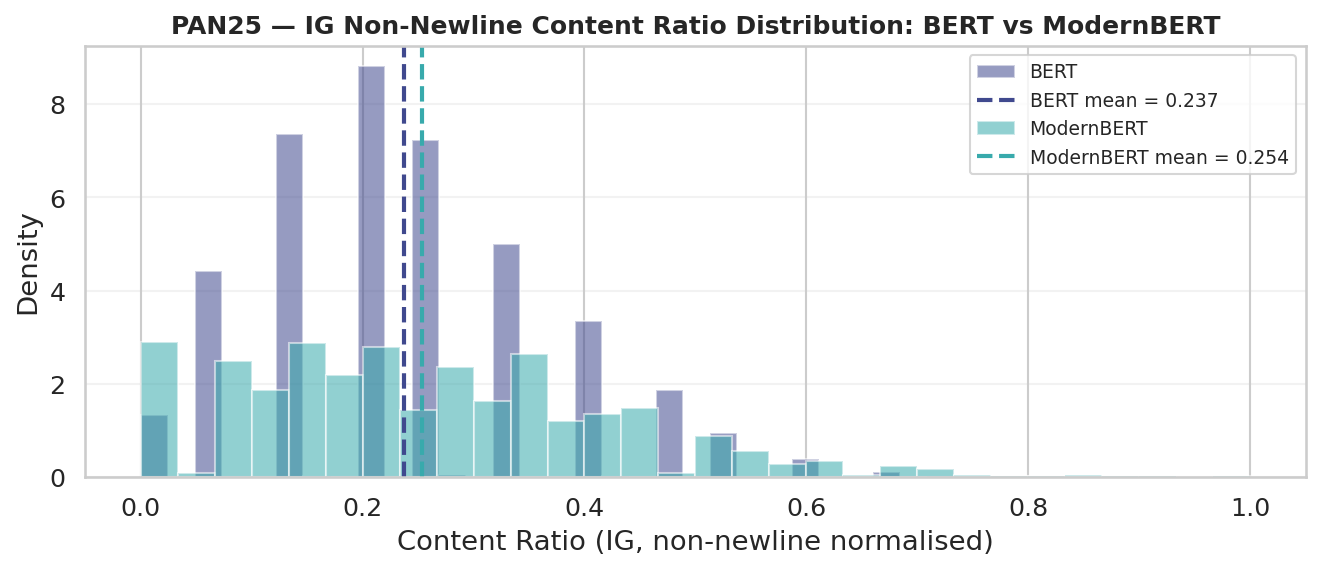

Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/modernbert_nonnewline_ratio_distribution_authormix_ig_non-newline_content_ratio_distribution_bert_vs_modernbert.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/modernbert_nonnewline_ratio_distribution_authormix_ig_non-newline_content_ratio_distribution_bert_vs_modernbert.pdf


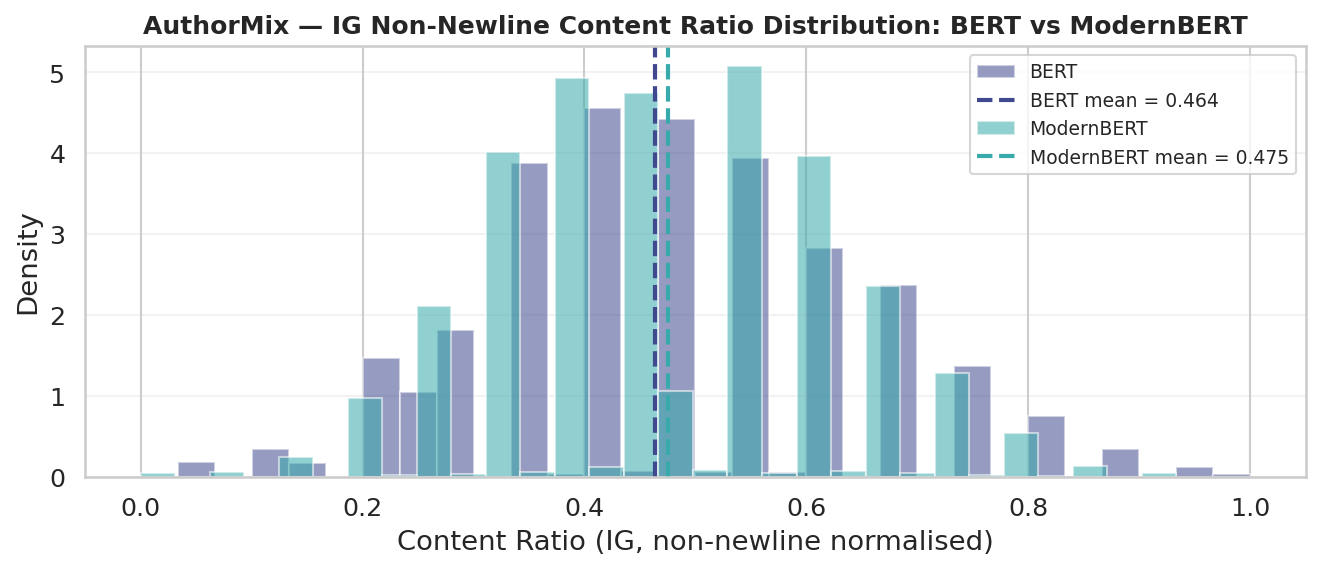

In [24]:
# Distribution plots: IG non-newline content ratio histogram per model
def plot_ratio_distribution_comparison(datasets, title, method_prefix="ig", save_dir=None):
    col = f"{method_prefix}_content_nonnewline_ratio"

    fig, ax = plt.subplots(figsize=(9, 4), dpi=150)

    for (name, df), color in zip(datasets, mako_palette(len(datasets))):
        if col not in df.columns:
            continue

        vals = df[col].dropna()
        ax.hist(vals, bins=30, alpha=0.55, color=color, label=name, density=True)
        ax.axvline(
            vals.mean(),
            color=color,
            ls="--",
            lw=2,
            label=f"{name} mean = {vals.mean():.3f}",
        )

    ax.set_xlabel("Content Ratio (IG, non-newline normalised)")
    ax.set_ylabel("Density")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    save_plot(fig, f"modernbert_nonnewline_ratio_distribution_{title}", save_dir=save_dir)
    plt.show()

if has_bert:
    plot_ratio_distribution_comparison(
        [("BERT", bert_pan), ("ModernBERT", pan_ratios)],
        "PAN25 — IG Non-Newline Content Ratio Distribution: BERT vs ModernBERT",
    )

    plot_ratio_distribution_comparison(
        [("BERT", bert_am), ("ModernBERT", am_ratios)],
        "AuthorMix — IG Non-Newline Content Ratio Distribution: BERT vs ModernBERT",
    )

else:
    # Show ModernBERT only, split by non-newline lexical categories.
    for df, name in [(pan_ratios, "PAN25"), (am_ratios, "AuthorMix")]:
        fig, axes = plt.subplots(1, 3, figsize=(13, 4), dpi=150)

        for ax, (prefix, label) in zip(axes, METHODS):
            colors = mako_palette(3)
            ax.hist(
                df[f"{prefix}_content_nonnewline_ratio"],
                bins=30,
                color=colors[0],
                alpha=0.7,
                label="Content",
                density=True,
            )
            ax.hist(
                df[f"{prefix}_punct_nonnewline_ratio"],
                bins=30,
                color=colors[1],
                alpha=0.7,
                label="Punct",
                density=True,
            )
            ax.hist(
                df[f"{prefix}_stop_nonnewline_ratio"],
                bins=30,
                color=colors[2],
                alpha=0.7,
                label="Stop",
                density=True,
            )
            ax.set_title(label)
            ax.legend(fontsize=8)
            ax.grid(axis="y", alpha=0.25)

        fig.suptitle(
            f"{name} — Non-Newline Token-Type Ratio Distributions (ModernBERT)",
            fontsize=12,
            fontweight="bold",
        )
        plt.tight_layout()
        save_plot(fig, f"{name}_modernbert_nonnewline_token_type_ratio_distributions")
        plt.show()


In [25]:
# Statistical test: is ModernBERT content ratio significantly different from BERT?
if has_bert:
    print("Welch t-test: BERT vs ModernBERT non-newline content ratio")

    for df_b, df_m, name in [
        (bert_pan, pan_ratios, "PAN25"),
        (bert_am, am_ratios, "AuthorMix"),
    ]:
        col = "ig_content_nonnewline_ratio"

        if col not in df_b.columns or col not in df_m.columns:
            continue

        a_v = df_b[col].dropna().values
        b_v = df_m[col].dropna().values
        t, p = ttest_ind(a_v, b_v, equal_var=False)
        d = cohens_d(a_v, b_v)

        print(f"  {name}: BERT mean={a_v.mean():.3f}, ModernBERT mean={b_v.mean():.3f}")
        print(f"    Δ = {b_v.mean() - a_v.mean():.3f}, Cohen's d = {d:.3f}, p = {p:.2e}")

else:
    # ModernBERT-only: t-test between IG and AR content ratios.
    print("ModernBERT — IG vs AR non-newline content ratio (intra-model, PAN25):")
    a_v = pan_ratios["ig_content_nonnewline_ratio"].dropna().values
    b_v = pan_ratios["ar_content_nonnewline_ratio"].dropna().values
    t, p = ttest_ind(a_v, b_v, equal_var=False)
    d = cohens_d(a_v, b_v)
    print(f"  IG mean={a_v.mean():.3f}, AR mean={b_v.mean():.3f}, d={d:.3f}, p={p:.2e}")


Welch t-test: BERT vs ModernBERT non-newline content ratio
  PAN25: BERT mean=0.237, ModernBERT mean=0.254
    Δ = 0.017, Cohen's d = -0.113, p = 1.85e-06
  AuthorMix: BERT mean=0.464, ModernBERT mean=0.475
    Δ = 0.011, Cohen's d = -0.073, p = 1.81e-03


## 11. Summary dashboard

In [26]:
import os
import re

def safe_filename(text):
    text = str(text)
    text = re.sub(r"[^a-zA-Z0-9_-]+", "_", text)
    return text.strip("_").lower()


def summary_dashboard(data, ratios_df, dataset_name, model_name="ModernBERT", save_dir=None):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    classes = sorted(ratios_df["class"].unique())
    palette = {c: color for c, color in zip(classes, mako_palette(len(classes)))}
    method_palette = {
        label: color
        for label, color in zip(["IG", "SHAP", "AR"], mako_palette(3))
    }

    # (0,0) Non-newline content ratio by method
    ax = axes[0, 0]
    ratio_rows = []

    for prefix, label in METHODS:
        sub = ratios_df[["class", f"{prefix}_content_nonnewline_ratio"]].copy()
        sub.columns = ["class", "content_ratio"]
        sub["method"] = label
        ratio_rows.append(sub)

    combined = pd.concat(ratio_rows, ignore_index=True)

    sns.barplot(
        data=combined,
        x="method",
        y="content_ratio",
        hue="class",
        ax=ax,
        palette=palette,
        edgecolor="white",
    )
    ax.set_title("Non-Newline Content Ratio by Method", fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Content Ratio")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=5, ncol=3)

    # (0,1) Lexical metrics (IG) — sample
    ax = axes[0, 1]
    sample = stratified_sample(data, n_per_class=20)
    lex = lexical_metrics(sample, "top_ig")
    metrics = ["mean_word_length", "stopword_ratio", "subword_ratio"]
    x = np.arange(len(metrics))
    width = 0.8 / max(len(classes), 1)

    for i, cls in enumerate(sorted(lex["class"].unique())):
        subset = lex[lex["class"] == cls]
        vals = [subset[m].mean() for m in metrics]
        ax.bar(x + i * width, vals, width, label=cls,
               color=palette.get(cls), edgecolor="white")

    ax.set_xticks(x + width * len(classes) / 2)
    ax.set_xticklabels(["Word Len", "Stopword", "Subword"], fontsize=9)
    ax.set_title("Lexical Metrics (IG)", fontsize=10, fontweight="bold")
    ax.legend(fontsize=5, ncol=3)

    # (0,2) Attribution Concentration
    ax = axes[0, 2]
    conc_rows = []

    for mk, ml in [("top_ig", "IG"), ("top_gs", "SHAP"), ("top_ar", "AR")]:
        conc = attribution_concentration(sample, mk)
        conc["method"] = ml
        conc_rows.append(conc)

    conc_all = pd.concat(conc_rows)

    sns.barplot(
        data=conc_all,
        x="method",
        y="normalised_entropy",
        hue="class",
        ax=ax,
        palette=palette,
        edgecolor="white",
    )
    ax.set_title("Attribution Entropy", fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.legend(fontsize=5, ncol=3)

    # (1,0) Cross-method agreement
    ax = axes[1, 0]
    agree = pairwise_agreement(sample)

    sns.barplot(
        data=agree,
        x="pair",
        y="jaccard",
        hue="class",
        ax=ax,
        palette=palette,
        edgecolor="white",
    )
    ax.set_title("Cross-Method Agreement", fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.legend(fontsize=5, ncol=3)

    # (1,1) Punct vs Content (full)
    ax = axes[1, 1]

    for prefix, label in METHODS:
        ax.scatter(
            ratios_df[f"{prefix}_content_nonnewline_ratio"],
            ratios_df[f"{prefix}_punct_nonnewline_ratio"],
            alpha=0.12,
            s=5,
            label=label,
            color=method_palette[label],
        )

    ax.set_xlabel("Content Ratio, Non-Newline Normalised")
    ax.set_ylabel("Punctuation Ratio, Non-Newline Normalised")
    ax.set_title("Content vs Punctuation", fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)

    # (1,2) Distribution of IG content ratio
    ax = axes[1, 2]

    for cls in sorted(ratios_df["class"].unique()):
        vals = ratios_df[ratios_df["class"] == cls]["ig_content_nonnewline_ratio"]
        ax.hist(
            vals,
            bins=15,
            alpha=0.35,
            label=cls,
            density=True,
            color=palette[cls],
            edgecolor="white",
            linewidth=0.3,
        )

    ax.set_xlabel("IG Content Ratio, Non-Newline Normalised")
    ax.set_ylabel("Density")
    ax.set_title("Content Ratio Distribution (IG)", fontsize=10, fontweight="bold")
    ax.legend(fontsize=5, ncol=3)

    fig.suptitle(
        f"{dataset_name} ({model_name}) — Attribution Analysis Dashboard (Full Validation)",
        fontsize=14,
        fontweight="bold",
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        filename_base = safe_filename(
            f"{dataset_name}_{model_name}_attribution_analysis_dashboard"
        )

        png_path = os.path.join(save_dir, filename_base + ".png")
        pdf_path = os.path.join(save_dir, filename_base + ".pdf")

        fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
        fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")

        print(f"Saved PNG: {png_path}")
        print(f"Saved PDF: {pdf_path}")

    plt.show()


Saved PNG: /content/drive/MyDrive/ap-thesis/runs/plots/dashboards/pan25_modernbert_attribution_analysis_dashboard.png
Saved PDF: /content/drive/MyDrive/ap-thesis/runs/plots/dashboards/pan25_modernbert_attribution_analysis_dashboard.pdf


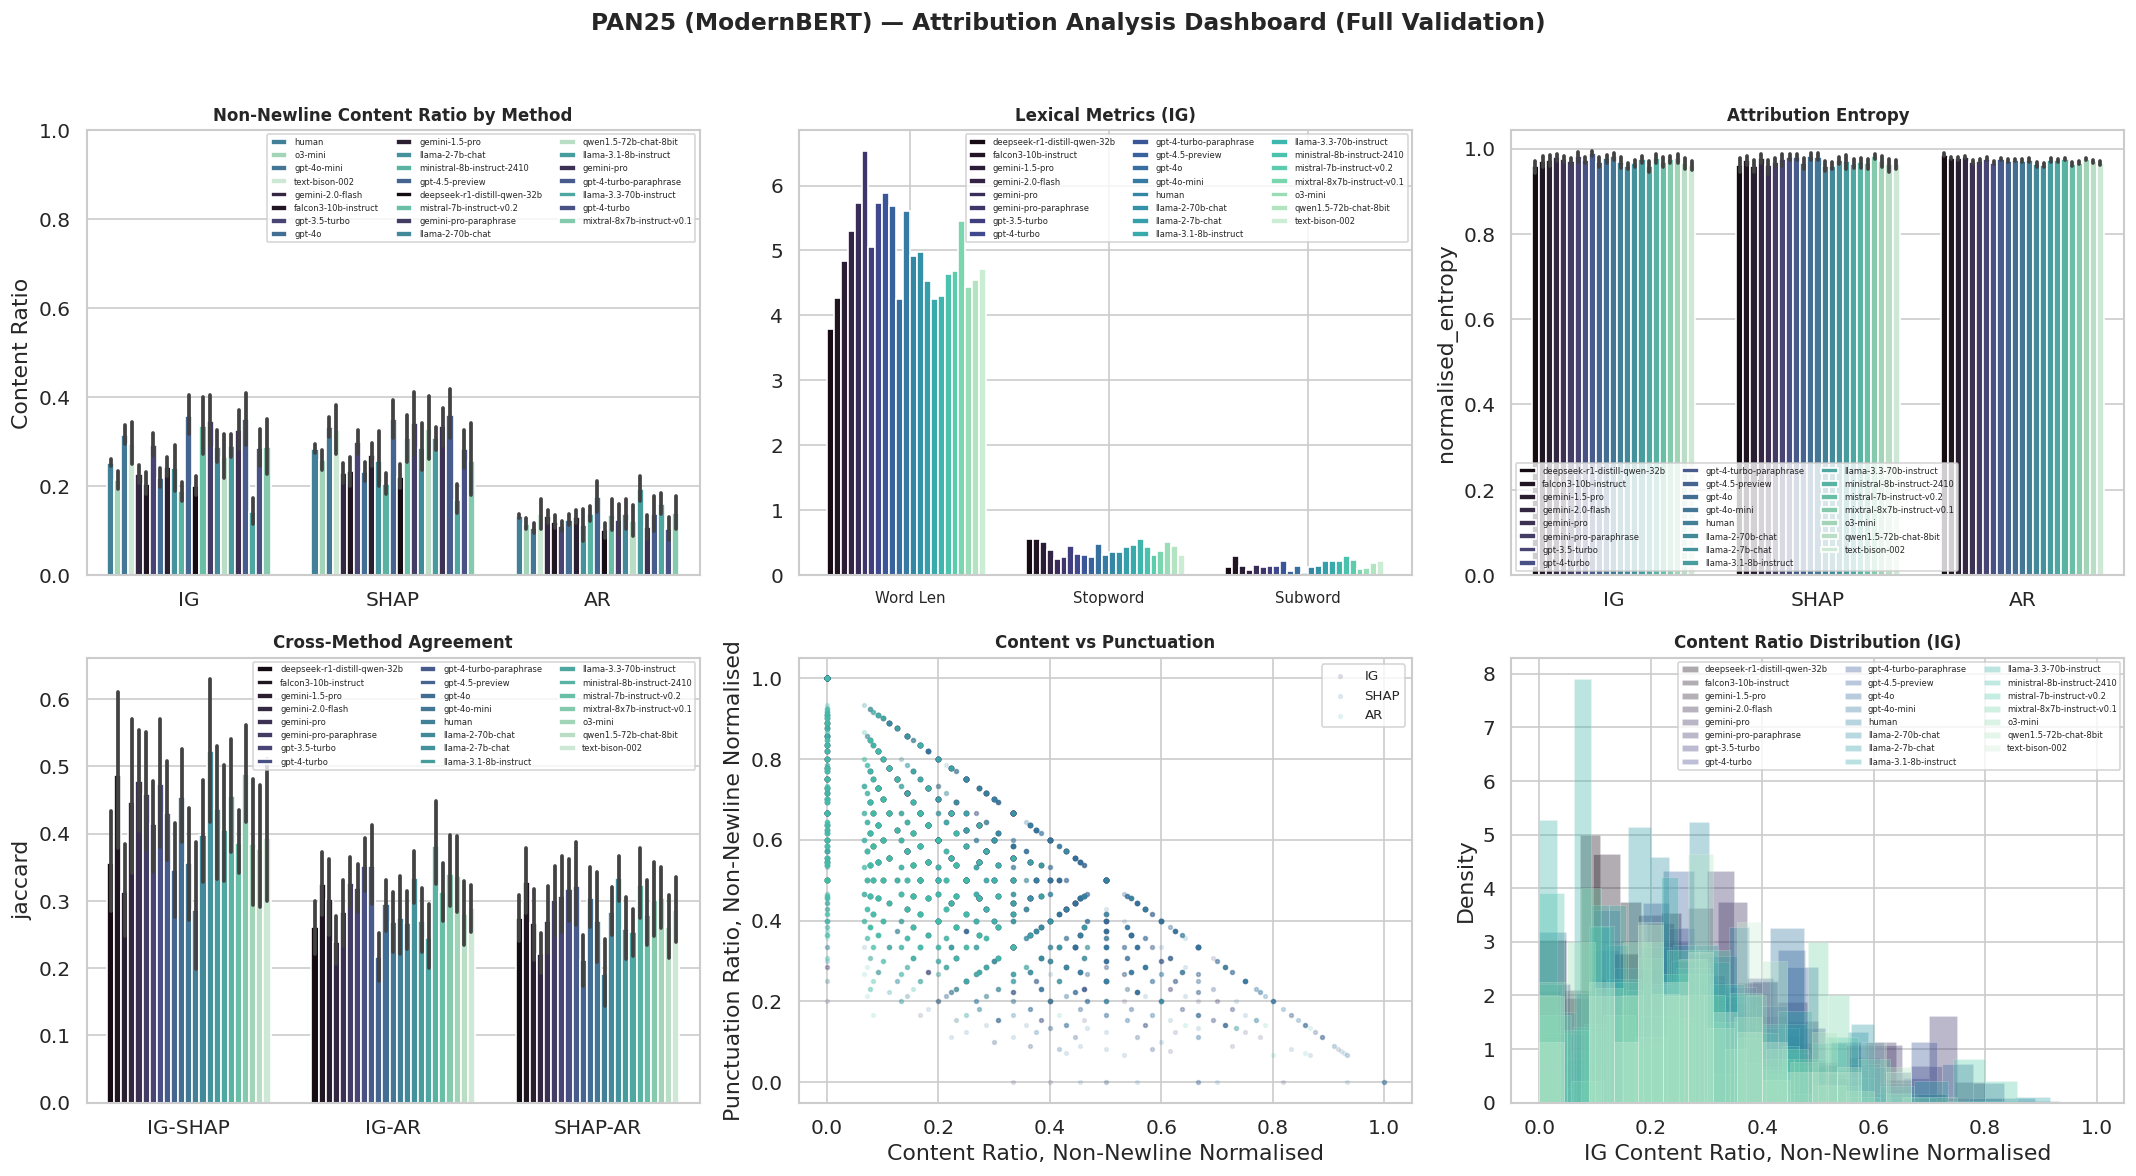

Saved PNG: /content/drive/MyDrive/ap-thesis/runs/plots/dashboards/authormix_modernbert_attribution_analysis_dashboard.png
Saved PDF: /content/drive/MyDrive/ap-thesis/runs/plots/dashboards/authormix_modernbert_attribution_analysis_dashboard.pdf


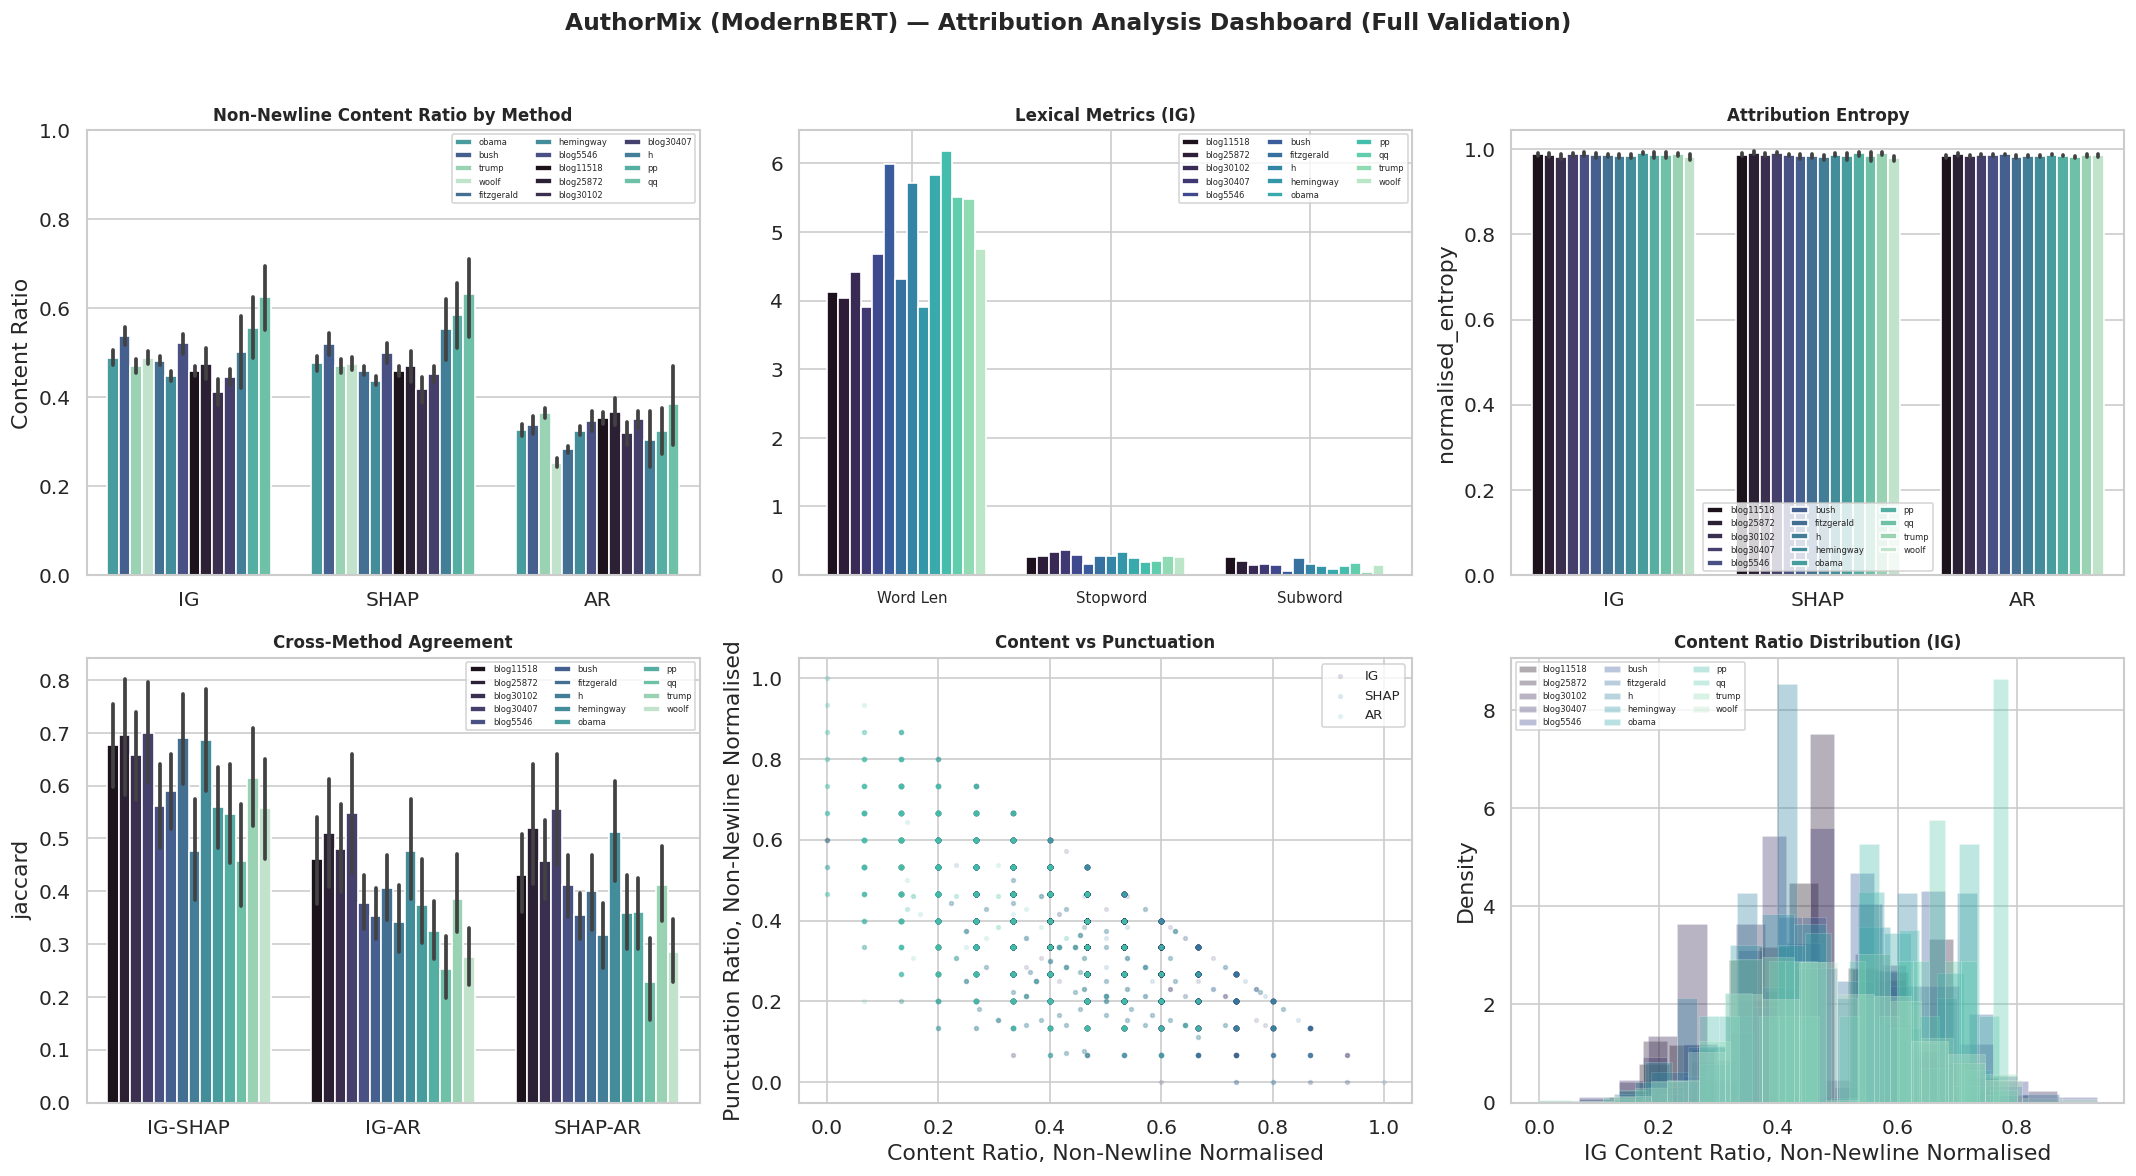

In [27]:
DASHBOARD_DIR = f"{RUNS_ROOT}/plots/dashboards"

summary_dashboard(pan_data, pan_ratios, "PAN25", model_name="ModernBERT", save_dir=DASHBOARD_DIR)
summary_dashboard(am_data, am_ratios, "AuthorMix", model_name="ModernBERT", save_dir=DASHBOARD_DIR)


## 12. Save final summary

In [28]:
# Per-class ratio summary (long format)
# Thesis-facing ratios are non-newline normalised. Raw newline remains an audit column.
for name, df in [("pan25_modernbert", pan_ratios), ("authormix_modernbert", am_ratios)]:
    rows = []

    for prefix, label in METHODS:
        for rtype in LEXICAL_RATIO_TYPES:
            col = f"{prefix}_{rtype}"
            grp = df.groupby("class")[col].agg(["mean", "std", "count"])

            for cls, row in grp.iterrows():
                rows.append({
                    "class": cls,
                    "method": label,
                    "metric": rtype,
                    "mean": round(row["mean"], 4),
                    "std": round(row["std"], 4),
                    "n": int(row["count"]),
                })

    out = f"{RESULTS}/{name}_ratio_summary_long.csv"
    pd.DataFrame(rows).to_csv(out, index=False)
    print(f"Saved: {out}")

    # Raw newline audit, saved separately and not used as a thesis plot.
    newline_rows = []
    for prefix, label in METHODS:
        col = f"{prefix}_newline_ratio"
        grp = df.groupby("class")[col].agg(["mean", "std", "count"])

        for cls, row in grp.iterrows():
            newline_rows.append({
                "class": cls,
                "method": label,
                "metric": "newline_ratio_raw_audit",
                "mean": round(row["mean"], 4),
                "std": round(row["std"], 4),
                "n": int(row["count"]),
            })

    newline_out = f"{RESULTS}/{name}_newline_audit_summary.csv"
    pd.DataFrame(newline_rows).to_csv(newline_out, index=False)
    print(f"Saved: {newline_out}")

# Cross-method agreement summary (full validation)
for name, data in [("pan25_modernbert", pan_data), ("authormix_modernbert", am_data)]:
    agree_df = pairwise_agreement(data)
    summary = agree_df.groupby(["class", "pair"])["jaccard"].agg(["mean", "std"]).round(4)
    out = f"{RESULTS}/{name}_agreement_summary_full.csv"
    summary.to_csv(out)
    print(f"Saved: {out}")

# Attribution concentration summary
for name, data in [("pan25_modernbert", pan_data), ("authormix_modernbert", am_data)]:
    rows = []
    for mk, ml in [("top_ig", "IG"), ("top_gs", "SHAP"), ("top_ar", "AR")]:
        c = attribution_concentration(data, mk)
        c["method"] = ml
        rows.append(c)

    conc = pd.concat(rows, ignore_index=True)
    tbl = conc.groupby(["class", "method"])[
        ["normalised_entropy", "gini", "top3_dominance"]
    ].mean().round(4)

    out = f"{RESULTS}/{name}_concentration_summary.csv"
    tbl.to_csv(out)
    print(f"Saved: {out}")

# Statistical tests: key class pairs
stat_pairs = {
    "pan25_modernbert": (pan_ratios, [("human", "gpt-4o"), ("human", "gpt-4-turbo-paraphrase")]),
    "authormix_modernbert": (am_ratios, [("hemingway", "woolf"), ("obama", "trump"), ("bush", "pp")]),
}

for name, (df, pairs) in stat_pairs.items():
    all_stats = []

    for ca, cb in pairs:
        res = statistical_comparison(df, name, ca, cb)

        if res is not None:
            res["class_a"] = ca
            res["class_b"] = cb
            all_stats.append(res)

    if all_stats:
        out = f"{RESULTS}/{name}_statistical_tests.csv"
        pd.concat(all_stats, ignore_index=True).to_csv(out, index=False)
        print(f"Saved: {out}")

print("\nAll results saved.")


Saved: /content/drive/MyDrive/ap-thesis/runs/results/pan25_modernbert_ratio_summary_long.csv
Saved: /content/drive/MyDrive/ap-thesis/runs/results/pan25_modernbert_newline_audit_summary.csv
Saved: /content/drive/MyDrive/ap-thesis/runs/results/authormix_modernbert_ratio_summary_long.csv
Saved: /content/drive/MyDrive/ap-thesis/runs/results/authormix_modernbert_newline_audit_summary.csv
Saved: /content/drive/MyDrive/ap-thesis/runs/results/pan25_modernbert_agreement_summary_full.csv
Saved: /content/drive/MyDrive/ap-thesis/runs/results/authormix_modernbert_agreement_summary_full.csv
Saved: /content/drive/MyDrive/ap-thesis/runs/results/pan25_modernbert_concentration_summary.csv
Saved: /content/drive/MyDrive/ap-thesis/runs/results/authormix_modernbert_concentration_summary.csv

  pan25_modernbert: human vs gpt-4o
  Lexical ratios are non-newline normalised.


,Method,Metric,Mean human,Mean gpt-4o,Cohen's d,t p-value,U p-value
0,IG,Content,0.253,0.219,0.207,4.41e-03,7.93e-03
1,IG,Punctuation,0.551,0.634,-0.448,6.21e-09,1.10e-08
2,IG,Stopword,0.196,0.147,0.353,2.76e-07,4.16e-06
3,SHAP,Content,0.284,0.232,0.292,3.16e-05,5.22e-04
4,SHAP,Punctuation,0.514,0.625,-0.570,5.89e-13,3.91e-13
5,SHAP,Stopword,0.202,0.143,0.397,4.29e-09,2.21e-07
6,AR,Content,0.133,0.124,0.090,2.06e-01,4.24e-01
7,AR,Punctuation,0.597,0.529,0.385,2.09e-10,1.10e-06
8,AR,Stopword,0.270,0.347,-0.550,2.92e-17,5.40e-14



  pan25_modernbert: human vs gpt-4-turbo-paraphrase
  Lexical ratios are non-newline normalised.


,Method,Metric,Mean human,Mean gpt-4-turbo-paraphrase,Cohen's d,t p-value,U p-value
0,IG,Content,0.253,0.352,-0.606,2.08e-03,1.01e-03
1,IG,Punctuation,0.551,0.501,0.271,1.10e-01,1.03e-01
2,IG,Stopword,0.196,0.148,0.342,1.16e-02,5.84e-02
3,SHAP,Content,0.284,0.361,-0.418,1.51e-02,6.08e-03
4,SHAP,Punctuation,0.514,0.460,0.277,7.29e-02,1.07e-01
5,SHAP,Stopword,0.202,0.179,0.150,3.69e-01,2.93e-01
6,AR,Content,0.133,0.137,-0.040,8.47e-01,9.60e-01
7,AR,Punctuation,0.597,0.588,0.051,7.12e-01,9.63e-01
8,AR,Stopword,0.270,0.275,-0.035,8.30e-01,8.90e-01


Saved: /content/drive/MyDrive/ap-thesis/runs/results/pan25_modernbert_statistical_tests.csv

  authormix_modernbert: hemingway vs woolf
  Lexical ratios are non-newline normalised.


...


  authormix_modernbert: obama vs trump
  Lexical ratios are non-newline normalised.


,Method,Metric,Mean obama,Mean trump,Cohen's d,t p-value,U p-value
0,IG,Content,0.489,0.470,0.128,1.19e-01,3.39e-02
1,IG,Punctuation,0.332,0.342,-0.095,2.37e-01,2.69e-01
2,IG,Stopword,0.180,0.188,-0.065,4.24e-01,8.69e-01
3,SHAP,Content,0.476,0.470,0.043,6.02e-01,4.07e-01
4,SHAP,Punctuation,0.338,0.339,-0.006,9.39e-01,8.44e-01
5,SHAP,Stopword,0.186,0.191,-0.046,5.75e-01,9.40e-01
6,AR,Content,0.326,0.365,-0.344,3.31e-05,4.64e-05
7,AR,Punctuation,0.391,0.351,0.353,1.99e-05,1.62e-05
8,AR,Stopword,0.284,0.283,0.001,9.91e-01,9.90e-01



  authormix_modernbert: bush vs pp
  Lexical ratios are non-newline normalised.


,Method,Metric,Mean bush,Mean pp,Cohen's d,t p-value,U p-value
0,IG,Content,0.537,0.555,-0.140,6.32e-01,4.40e-01
1,IG,Punctuation,0.295,0.318,-0.269,3.54e-01,3.80e-01
2,IG,Stopword,0.168,0.127,0.392,1.64e-01,2.19e-01
3,SHAP,Content,0.519,0.584,-0.437,1.15e-01,8.09e-02
4,SHAP,Punctuation,0.305,0.315,-0.088,7.19e-01,7.57e-01
5,SHAP,Stopword,0.176,0.101,0.749,6.35e-04,3.21e-02
6,AR,Content,0.338,0.323,0.126,6.32e-01,5.70e-01
7,AR,Punctuation,0.370,0.402,-0.297,1.54e-01,3.53e-01
8,AR,Stopword,0.292,0.275,0.187,4.75e-01,4.03e-01


Saved: /content/drive/MyDrive/ap-thesis/runs/results/authormix_modernbert_statistical_tests.csv

All results saved.


Additional

In [29]:
import os, json, gzip, re as _re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from itertools import combinations
from collections import defaultdict

try:
    mako_palette
except NameError:
    def mako_palette(n, reverse=False):
        colors = sns.color_palette("mako", n_colors=max(n, 1))
        if reverse:
            colors = list(reversed(colors))
        return colors[:n]

try:
    RESULTS
except NameError:
    RESULTS = f"{ROOT}/runs/results"

PLOTS_DIR = f"{ROOT}/thesis plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

_CAT = mako_palette(3)
CAT_COLOR = {"content": _CAT[0], "stop": _CAT[1], "punct": _CAT[2]}
_MOD = mako_palette(2)
MODEL_COLOR = {"BERT": _MOD[0], "ModernBERT": _MOD[1]}

# Thesis-facing plots use lexical categories only.
# Newline is kept in the raw ratios as an audit category, but is not plotted here.
CATS = ["content", "stop", "punct"]

RATIOS = {
    ("BERT", "PAN25"): "pan25_full_validation_all_methods_ratios.csv",
    ("BERT", "AuthorMix"): "authormix_full_validation_all_methods_ratios.csv",
    ("ModernBERT", "PAN25"): "pan25_modernbert_full_validation_all_methods_ratios.csv",
    ("ModernBERT", "AuthorMix"): "authormix_modernbert_full_validation_all_methods_ratios.csv",
}

ATTRIB = {
    ("BERT", "PAN25"): "pan25_full_validation_all_methods_attributions.json",
    ("BERT", "AuthorMix"): "authormix_full_validation_all_methods_attributions.json",
    ("ModernBERT", "PAN25"): "pan25_modernbert_full_validation_all_methods_attributions.json.gz",
    ("ModernBERT", "AuthorMix"): "authormix_modernbert_full_validation_all_methods_attributions.json",
}

def save_fig(fig, name, save_dir=None, dpi=300):
    """Save a matplotlib figure as both PDF and PNG."""
    if save_dir is None:
        save_dir = PLOTS_DIR

    os.makedirs(save_dir, exist_ok=True)
    pdf_path = os.path.join(save_dir, name + ".pdf")
    png_path = os.path.join(save_dir, name + ".png")

    fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
    fig.savefig(png_path, dpi=dpi, bbox_inches="tight", facecolor="white")
    plt.close(fig)

    print(f"saved PDF: {pdf_path}")
    print(f"saved PNG: {png_path}")

def _ratios(model, dataset):
    return pd.read_csv(os.path.join(RESULTS, RATIOS[(model, dataset)]))

def _attrib(model, dataset):
    p = os.path.join(RESULTS, ATTRIB[(model, dataset)])
    candidates = [p]

    # ModernBERT PAN25 has appeared in both .json and .json.gz form across runs.
    if p.endswith(".gz"):
        candidates.append(p[:-3])
    else:
        candidates.append(p + ".gz")

    for candidate in candidates:
        if os.path.exists(candidate) and os.path.getsize(candidate) >= 100:
            op = gzip.open if candidate.endswith(".gz") else open
            with op(candidate, "rt", encoding="utf-8") as f:
                return json.load(f)

    return None

def _ensure_nonnewline(df):
    """Add non-newline lexical ratio columns if they are not already present."""
    df = df.copy()

    for m in ("ig", "gs", "ar"):
        needed = [
            f"{m}_content_nonnewline_ratio",
            f"{m}_stop_nonnewline_ratio",
            f"{m}_punct_nonnewline_ratio",
        ]

        if all(col in df.columns for col in needed):
            continue

        denom = (
            df[f"{m}_content_ratio"]
            + df[f"{m}_stop_ratio"]
            + df[f"{m}_punct_ratio"]
        ).replace(0, np.nan)

        df[f"{m}_content_nonnewline_ratio"] = df[f"{m}_content_ratio"] / denom
        df[f"{m}_stop_nonnewline_ratio"] = df[f"{m}_stop_ratio"] / denom
        df[f"{m}_punct_nonnewline_ratio"] = df[f"{m}_punct_ratio"] / denom

    return df

# token decoding + content filter (figure 5)
def _b2u():
    bs = list(range(33, 127)) + list(range(161, 173)) + list(range(174, 256))
    cs = bs[:]
    n = 0

    for b in range(256):
        if b not in bs:
            bs.append(b)
            cs.append(256 + n)
            n += 1

    return {chr(c): b for b, c in zip(bs, cs)}

_BD = _b2u()

_STOP = set(("i me my myself we our ours ourselves you your yours yourself yourselves he him his "
"himself she her hers herself it its itself they them their theirs themselves what which who "
"whom this that these those am is are was were be been being have has had having do does did "
"doing a an the and but if or because as until while of at by for with about against between "
"into through during before after above below to from up down in out on off over under again "
"further then once here there when where why how all any both each few more most other some "
"such no nor not only own same so than too very s t can will just don should now d ll m o re "
"ve y").split())

def _decode(tok, model):
    if model == "ModernBERT":
        try:
            return bytes(_BD[c] for c in tok).decode("utf-8", errors="replace")
        except KeyError:
            return tok

    return tok[2:] if tok.startswith("##") else tok

def _is_content(tok, model):
    if tok in ("[CLS]", "[SEP]", "[PAD]", "[UNK]", "[MASK]"):
        return False

    core = _decode(tok, model).strip()

    if core == "" or _re.fullmatch(r"\W+", core):
        return False

    return core.lower() not in _STOP

def fig1_token_type_ratios(model, dataset):
    """Mean lexical token-type ratios of top attributed tokens, excluding newline."""
    df = _ensure_nonnewline(_ratios(model, dataset))
    methods = [("ig", "IG"), ("gs", "GradientSHAP"), ("ar", "Attention Rollout")]

    fig, ax = plt.subplots(figsize=(9, 5.2))
    x = np.arange(len(methods))
    w = 0.24

    for i, c in enumerate(CATS):
        ax.bar(
            x + i * w,
            [df[f"{m}_{c}_nonnewline_ratio"].mean() for m, _ in methods],
            w,
            label=c.capitalize(),
            color=CAT_COLOR[c],
            edgecolor="white",
        )

    ax.set_xticks(x + w)
    ax.set_xticklabels([l for _, l in methods])
    ax.set_ylabel("Mean ratio of top-15 non-newline tokens")
    ax.set_ylim(0, 1)
    ax.legend(title="Token type")
    ax.set_title(
        f"{dataset} ({model}) — Lexical Token-Type Ratios of Top Attributed Tokens",
        fontsize=12,
        fontweight="bold",
    )
    save_fig(fig, f"fig1_token_type_ratios_{dataset.lower()}_{model.lower()}")

def fig2_nonnewline_content(dataset, method="ig"):
    out = {}

    for model in ("BERT", "ModernBERT"):
        df = _ensure_nonnewline(_ratios(model, dataset))
        out[model] = df.groupby("class")[f"{method}_content_nonnewline_ratio"].mean()

    classes = out["ModernBERT"].sort_values().index.tolist()
    fig, ax = plt.subplots(figsize=(10, max(4.5, 0.42 * len(classes))))
    y = np.arange(len(classes))
    h = 0.4

    for i, model in enumerate(("BERT", "ModernBERT")):
        ax.barh(
            y + i * h,
            [out[model].get(cl, np.nan) for cl in classes],
            h,
            label=model,
            color=MODEL_COLOR[model],
            edgecolor="white",
        )

    ax.set_yticks(y + h / 2)
    ax.set_yticklabels(classes)
    ax.set_xlabel("Content ratio (renormalised over non-newline tokens)")
    ax.set_xlim(0, 1)
    ax.legend()
    ax.set_title(
        f"{dataset} — Content Ratio by Class, BERT vs ModernBERT (non-newline tokens)",
        fontsize=12,
        fontweight="bold",
    )
    save_fig(fig, f"fig2_content_nonnewline_{dataset.lower()}")

def fig3_ar_comparison(dataset):
    means = {}

    for model in ("BERT", "ModernBERT"):
        df = _ensure_nonnewline(_ratios(model, dataset))
        means[model] = [df[f"ar_{c}_nonnewline_ratio"].mean() for c in CATS]

    fig, ax = plt.subplots(figsize=(8.5, 5))
    x = np.arange(len(CATS))
    w = 0.38

    for i, model in enumerate(("BERT", "ModernBERT")):
        ax.bar(
            x + i * w,
            means[model],
            w,
            label=model,
            color=MODEL_COLOR[model],
            edgecolor="white",
        )

    ax.set_xticks(x + w / 2)
    ax.set_xticklabels([c.capitalize() for c in CATS])
    ax.set_ylabel("Mean Attention Rollout ratio, non-newline normalised")
    ax.set_ylim(0, 1)
    ax.legend()
    ax.set_title(
        f"{dataset} — Attention Rollout Lexical Ratios, BERT vs ModernBERT",
        fontsize=12,
        fontweight="bold",
    )
    save_fig(fig, f"fig3_attention_rollout_{dataset.lower()}")

def fig4_agreement(model, dataset):
    data = _attrib(model, dataset)

    if data is None:
        print(f"[skip] fig4 {model} {dataset}: attribution JSON unavailable")
        return

    methods = [("top_ig", "IG"), ("top_gs", "SHAP"), ("top_ar", "AR")]
    pv = defaultdict(list)

    for ex in data:
        sets = {l: set(t[0] for t in ex.get(k, [])) for k, l in methods}

        for (l1, s1), (l2, s2) in combinations(sets.items(), 2):
            u = s1 | s2
            pv[f"{l1}-{l2}"].append(len(s1 & s2) / len(u) if u else 0.0)

    pairs = ["IG-SHAP", "IG-AR", "SHAP-AR"]
    means = {p: np.mean(pv[p]) for p in pairs}

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    axes[0].bar(pairs, [means[p] for p in pairs], color=mako_palette(3), edgecolor="white")
    axes[0].set_ylim(0, 1)
    axes[0].set_ylabel("Mean Jaccard overlap")
    axes[0].set_title("Mean overlap by method pair", fontsize=11)

    labels = ["IG", "SHAP", "AR"]
    mat = np.eye(3)

    for p, (i, j) in {"IG-SHAP": (0, 1), "IG-AR": (0, 2), "SHAP-AR": (1, 2)}.items():
        mat[i, j] = mat[j, i] = means[p]

    sns.heatmap(
        mat,
        annot=True,
        fmt=".2f",
        xticklabels=labels,
        yticklabels=labels,
        cmap="mako",
        vmin=0,
        vmax=1,
        square=True,
        ax=axes[1],
        cbar_kws={"label": "Jaccard"},
    )
    axes[1].set_title("Pairwise agreement", fontsize=11)

    fig.suptitle(
        f"{dataset} ({model}) — Cross-Method Agreement (IG, SHAP, Attention Rollout)",
        fontsize=12,
        fontweight="bold",
    )
    save_fig(fig, f"fig4_agreement_{dataset.lower()}_{model.lower()}")

def fig5_fingerprint_table(model, dataset, top_n=8):
    data = _attrib(model, dataset)

    if data is None:
        print(f"[skip] fig5 {model} {dataset}: attribution JSON unavailable")
        return

    bc = defaultdict(lambda: defaultdict(float))

    for ex in data:
        for tok, score in ex.get("top_ig", []):
            if not _is_content(tok, model):
                continue

            bc[ex["class_name"]][_decode(tok, model).strip().lower()] += abs(float(score))

    rows = []

    for cls in sorted(bc):
        top = sorted(bc[cls].items(), key=lambda kv: -kv[1])[:top_n]
        rows.append([cls] + [w for w, _ in top])

    ncol = max((len(r) for r in rows), default=1)
    rows = [r + [""] * (ncol - len(r)) for r in rows]

    fig, ax = plt.subplots(figsize=(1.5 * ncol, 0.5 * len(rows) + 1))
    ax.axis("off")
    tbl = ax.table(
        cellText=[r[1:] for r in rows],
        rowLabels=[r[0] for r in rows],
        colLabels=[f"#{i+1}" for i in range(ncol - 1)],
        loc="center",
        cellLoc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.4)
    ax.set_title(
        f"{dataset} ({model}) — Per-Class Vocabulary Fingerprints",
        fontsize=12,
        fontweight="bold",
        pad=20,
    )
    save_fig(fig, f"fig5_fingerprints_{dataset.lower()}_{model.lower()}")

def fig6_positional(model, dataset, sample_per_class=30, seed=42):
    data = _attrib(model, dataset)

    if data is None:
        print(f"[skip] fig6 {model} {dataset}: attribution JSON unavailable")
        return

    rng = np.random.default_rng(seed)
    bc = defaultdict(list)

    for ex in data:
        bc[ex["class_name"]].append(ex)

    thirds = {"First third": [], "Middle third": [], "Last third": []}

    for cls, exs in bc.items():
        for k in rng.choice(len(exs), size=min(sample_per_class, len(exs)), replace=False):
            ex = exs[k]
            toks = ex["tokens"]
            n = max(len(toks) - 1, 1)
            used, pos = set(), []

            for tok, _ in ex.get("top_ig", []):
                for j, t in enumerate(toks):
                    if j not in used and t == tok:
                        used.add(j)
                        pos.append(j / n)
                        break

            if not pos:
                continue

            pos = np.array(pos)
            thirds["First third"].append(np.mean(pos < 0.33))
            thirds["Middle third"].append(np.mean((pos >= 0.33) & (pos < 0.67)))
            thirds["Last third"].append(np.mean(pos >= 0.67))

    labels = list(thirds)
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.bar(labels, [np.mean(thirds[k]) for k in labels],
           color=mako_palette(3), edgecolor="white")
    ax.set_ylabel("Mean share of top attributed tokens")
    ax.set_ylim(0, 1)
    ax.set_title(
        f"{dataset} ({model}) — Positional Distribution of Top Attributed Tokens",
        fontsize=12,
        fontweight="bold",
    )
    save_fig(fig, f"fig6_positional_{dataset.lower()}_{model.lower()}")


In [30]:
for ds in ("PAN25", "AuthorMix"):
    fig1_token_type_ratios("ModernBERT", ds)
    fig4_agreement("ModernBERT", ds)
    fig5_fingerprint_table("ModernBERT", ds)
    fig6_positional("ModernBERT", ds)
    fig2_nonnewline_content(ds)
    fig3_ar_comparison(ds)


saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/fig1_token_type_ratios_pan25_modernbert.pdf
saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/fig1_token_type_ratios_pan25_modernbert.png
saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/fig4_agreement_pan25_modernbert.pdf
saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/fig4_agreement_pan25_modernbert.png
saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/fig5_fingerprints_pan25_modernbert.pdf
saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/fig5_fingerprints_pan25_modernbert.png
saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/fig6_positional_pan25_modernbert.pdf
saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/fig6_positional_pan25_modernbert.png
saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/fig2_content_nonnewline_pan25.pdf
saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/fig2_content_nonnewline_pan25.png
saved PDF: /content/drive/MyDrive/ap-thesis/thesis